# Lección 13.2 · Metilación del ADN: islas CpG, bisulfito, valores β/M y regiones diferencialmente metiladas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-13-epigenomica/13.2_metilacion_adn.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 13 — Epigenómica y regulación** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 4.3 (islas CpG con HMM), 7.1–7.2 (alineamiento de lecturas), 11.2 (sobredispersión, binomial negativa) y 13.1 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es la 5-metilcitosina, por qué casi siempre aparece en el dinucleótido **CpG** y por qué el genoma
   humano tiene cuatro veces menos CpG de los esperados, salvo en las **islas CpG**.
2. **Calcular** a mano y en código la razón **observados/esperados** de CpG y **aplicar** el criterio de
   Gardiner-Garden y Frommer a ventanas de un promotor real (*GSTP1*, cromosoma 11).
3. **Describir** la química del **bisulfito** (C → U → T; la 5mC resiste) y **leer** la metilación en una lectura.
4. **Programar** un alineador de bisulfito en miniatura al estilo de **Bismark** (genoma C→T y G→A) y **comprobar** por
   qué un alineador ingenuo fracasa.
5. **Cuantificar** la metilación con valores **β** y **M**, **justificar** con el método delta cuándo usar cada uno y
   **calcular** intervalos de confianza de Wald y de Jeffreys para $\hat\beta$.
6. **Derivar** la varianza **beta-binomial** y **aplicar** la prueba de **Wald** del libro (tipo DSS), con dispersión
   **encogida** hacia un valor común, para detectar CpG diferencialmente metilados.
7. **Suavizar** perfiles de metilación y **llamar** una **región diferencialmente metilada (DMR)**, primero en la
   simulación del libro y después en datos **WGBS reales de ENCODE**: hígado normal frente a la línea tumoral HepG2.
8. **Reconocer** dos trampas clásicas con datos reales: un **SNP C/T** que se disfraza de "no metilado" y la
   **composición celular**.

## 🗺️ Mapa de la clase

0. El caso clínico: una marca invisible que decide un diagnóstico
1. Citosinas metiladas e islas CpG (ejemplo del libro: «Dos regiones de 100 pb»)
2. 🧪 Islas CpG en el promotor real de *GSTP1* (📊 interactivo)
3. La química del bisulfito (🎬 animación)
4. WGBS y alineamiento: un Bismark en miniatura
5. Cuantificar: valores β y M, cobertura e incertidumbre binomial (📊 interactivo)
6. Metilación diferencial: el modelo beta-binomial (🎬 animación; ejemplo del libro: «Un CpG, tres réplicas por grupo»)
7. De sitios a regiones: la DMR simulada del libro y la DMR real de *GSTP1* (📊 interactivo)
8. Trampas: SNP C/T y composición celular
9. Relojes epigenéticos y metilación sin bisulfito
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, json, math, time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle
from scipy import stats, special

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (UCSC…);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

NORMAL, TUMOR = ec.BLUE, ec.ORANGE          # grupo A = hígado normal (azul) · grupo B = HepG2 (naranja)
rng = np.random.default_rng(132)             # semilla fija para nuestras propias simulaciones
print("Listo para la Lección 13.2")

Entorno listo ✔  |  Colab: False


Listo para la Lección 13.2


## 0. El caso clínico: una marca invisible que decide un diagnóstico

Imagine un libro de recetas que comparte toda una familia. Nadie reescribe las recetas, pero cada cocinero pega notas
adhesivas sobre las que no quiere que se usen: "no preparar", "sólo en Navidad". Las notas no cambian el texto, se
copian cuando alguien fotocopia el libro para un hijo, y pueden despegarse. La **metilación del ADN** funciona de manera
parecida: un grupo metilo sobre una citosina **no altera la secuencia**, se **hereda** en cada división celular gracias a
una enzima (DNMT1) que copia el patrón de la hebra vieja a la nueva, y **puede borrarse**. El problema técnico es que las
"fotocopias" del laboratorio, la PCR y la secuenciación, **no copian las notas**. Hay que encontrar una tinta que revele
dónde estaban antes de fotocopiar.

Esta marca invisible ya decide tratamientos en la clínica:

* **Cáncer de próstata.** El promotor del gen *GSTP1* (una glutatión S-transferasa que protege a la célula de
  carcinógenos) está **hipermetilado y silenciado en la gran mayoría de los carcinomas de próstata** y casi nunca en el
  tejido normal (Lee *et al.*, 1994). Por eso la metilación de *GSTP1* se mide en biopsias y en orina como biomarcador;
  la misma hipermetilación aparece con frecuencia en tumores hepáticos.
* **Glioblastoma.** Los pacientes cuyo tumor tiene el promotor de *MGMT* metilado (la enzima que repara el daño que
  causa la temozolomida queda apagada) viven más cuando reciben ese fármaco (Hegi *et al.*, 2005). Un número, el nivel de
  metilación de unos pocos CpG, cambia la conversación con el paciente.
* **Impronta genómica.** En la región de *SNRPN* (cromosoma 15) una copia del gen está metilada y la otra no. Una prueba
  de metilación distingue en un solo análisis el síndrome de **Prader-Willi** (sólo queda la copia metilada) del de
  **Angelman** (sólo la no metilada).

En esta lección seguiremos un caso real de principio a fin: el promotor de ***GSTP1*** en datos de secuenciación con
bisulfito del genoma completo (**WGBS**) del consorcio **ENCODE**, comparando **tres muestras de hígado normal** (tres
donantes distintos) con **tres réplicas de HepG2**, una línea celular derivada de un tumor hepático (durante años se describió como carcinoma
hepatocelular, pero hoy se clasifica como hepatoblastoma; López-Terrada *et al.*, 2009). En el camino
reproduciremos, con las mismas cifras, los ejemplos y figuras simuladas de la sección 13.2 del libro.

## 1. Citosinas metiladas e islas CpG

### Palabras simples primero

En los mamíferos, la metilación del ADN consiste casi exclusivamente en añadir un grupo metilo ($-\text{CH}_3$) al
**carbono 5 de una citosina** (se escribe **5mC**) que va **seguida de una guanina**: el dinucleótido **CpG** (la "p" es
el fosfato que une la C con la G en la **misma** hebra; no confundir con el par C·G entre hebras).

El CpG tiene una simetría preciosa: leído en la hebra complementaria, **también es CpG**.

```
5'-A C G T-3'      hebra superior:  ...C G...
3'-T G C A-5'      hebra inferior:  ...G C...  (leída 5'→3' también es C G)
```

Por eso la marca se puede **heredar**: tras la replicación, cada doble hélice tiene una hebra vieja metilada y una nueva
sin metilar (ADN "hemimetilado"), y DNMT1 metila la C nueva que está frente a una 5mC vieja. La metilación de un
promotor se asocia en general al **silenciamiento estable** del gen; participa en la impronta genómica, la inactivación
del cromosoma X y el control de elementos transponibles.

### La huella de la metilación en la propia secuencia

La 5mC tiende a **desaminarse** espontáneamente a **timina**. La desaminación de una C normal produce uracilo, que la
célula reconoce como intruso y repara; pero una T frente a una G parece una base "legal", y se corrige peor. A lo largo
de millones de años, los CpG metilados se han ido convirtiendo en **TpG** (y en **CpA** en la otra hebra). Resultado: el
genoma humano tiene alrededor de **una cuarta parte** de los CpG que esperaríamos por su composición.

La excepción son las **islas CpG**: tramos de cientos a miles de pares de bases con abundantes CpG **no metilados**, que
Bird (1986) asoció con los extremos 5' de la mayoría de los genes de vertebrados, en particular de los genes de
mantenimiento. Como allí la C no está metilada, la desaminación produce uracilo (reparable) y los CpG **sobreviven**.
(En la Lección 4.3 las encontramos con un modelo oculto de Márkov; hoy usaremos el criterio clásico y, sobre todo, nos
preguntaremos **qué pasa cuando una isla se metila**.)

### El criterio de Gardiner-Garden y Frommer

¿Cuántos CpG esperaríamos si las bases se sucedieran al azar? Si en una región de longitud $L$ hay $n_C$ citosinas y
$n_G$ guaninas, la probabilidad de que una posición sea C es $n_C/L$, la de que la siguiente sea G es $n_G/L$, y hay
unas $L$ posiciones donde puede empezar un dinucleótido. El número esperado es $L\cdot\frac{n_C}{L}\cdot\frac{n_G}{L} =
n_C n_G / L$. La razón entre lo observado y lo esperado es:

$$
\frac{\text{CpG obs.}}{\text{CpG esp.}} \;=\; \frac{n_{CG}}{n_C\,n_G/L} \;=\; \frac{n_{CG}\,L}{n_C\,n_G} \;>\; 0{,}6
\qquad\text{(además: } L \ge 200 \text{ pb y GC} > 50\,\%\text{)}
$$

| Símbolo | Significado |
|---|---|
| $n_{CG}$ | número de dinucleótidos CpG en la región (en una hebra) |
| $n_C,\ n_G$ | número de citosinas y de guaninas |
| $L$ | longitud de la región; $n_C n_G/L$ es el número de CpG esperado si C y G se sucedieran al azar |

Una región es **isla CpG** si mide al menos 200 pb, su contenido de GC supera el 50 % **y** su razón obs./esp. supera
0,6 (Gardiner-Garden y Frommer, 1987; definición «Isla CpG» del libro).

### Ejemplo resuelto del libro: «Dos regiones de 100 pb»

El libro genera dos secuencias sintéticas de 100 pb que **imitan la evolución de la desaminación**: se sortean bases con
un contenido de GC dado y luego cada CpG sobrevive con cierta probabilidad; si no sobrevive, se convierte en TpG o en CpA
con igual probabilidad. La "isla" (GC = 74 %) conserva el 90 % de sus CpG; el "mar" (GC = 41 %) sólo el 22 %.

A mano, con los conteos que obtendremos:

* **Isla:** $n_C = 37$, $n_G = 32$, $n_{CG} = 12$ → GC $= 69/100 = 69\,\%$ y
  $\dfrac{12 \times 100}{37 \times 32} = \dfrac{1200}{1184} = 1{,}01 > 0{,}6$.
* **Mar:** $n_C = 22$, $n_G = 17$, $n_{CG} = 1$ → GC $= 39\,\%$ y $\dfrac{1 \times 100}{22 \times 17} = \dfrac{100}{374} = 0{,}27$,
  el valor típico del "mar" genómico.

(Para aplicar formalmente el criterio habría que usar ventanas de al menos 200 pb; lo haremos enseguida con un promotor
real.) Reproduzcamos las dos secuencias con **el mismo código y las mismas semillas** del libro.

In [2]:
def sintetica(L, gc, keep_cg, semilla):
    """Secuencia sintética del libro: bases al azar con contenido GC dado y 'desaminación' de CpG
    (cada CG sobrevive con probabilidad keep_cg; si no, pasa a TG o a CA con igual probabilidad)."""
    g = np.random.default_rng(semilla)
    p = [(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2]
    s = list("".join(g.choice(list("ACGT"), L, p=p)))
    for i in range(L - 1):   # desaminación de 5mC: CG -> TG / CA
        if s[i] == "C" and s[i + 1] == "G" and g.random() > keep_cg:
            if g.random() < 0.5:
                s[i] = "T"
            else:
                s[i + 1] = "A"
    return "".join(s)

def cpg_stats(s):
    """Conteos y razón observados/esperados de CpG (Gardiner-Garden y Frommer)."""
    L, nC, nG, nCG = len(s), s.count("C"), s.count("G"), s.count("CG")
    return dict(L=L, nC=nC, nG=nG, nCG=nCG, GC=(nC + nG) / L, OE=nCG * L / (nC * nG) if nC * nG else np.nan)

isla = sintetica(100, 0.74, 0.9, 11)
mar = sintetica(100, 0.41, 0.22, 5)
tab = pd.DataFrame([cpg_stats(isla), cpg_stats(mar)], index=["isla", "mar"])
print(tab.round(3).to_string())
# Comprobación contra las cifras del libro (figuras/cap13/cifras.txt)
assert (tab.loc["isla", ["nC", "nG", "nCG"]].tolist() == [37, 32, 12]) and abs(tab.loc["isla", "OE"] - 1.014) < 1e-3
assert (tab.loc["mar", ["nC", "nG", "nCG"]].tolist() == [22, 17, 1]) and abs(tab.loc["mar", "OE"] - 0.267) < 1e-3
print("\nisla:", isla)
print("mar: ", mar)

        L  nC  nG  nCG    GC     OE
isla  100  37  32   12  0.69  1.014
mar   100  22  17    1  0.39  0.267

isla: ACGACTAATGCGGCCGGGGGTCGCCGCGGACCATCCGCTCACCCTGCACTCGAAGGCCACAGCAGCAGTAGCAATGCGCCCTTCCCGAACCGGGGGGTCG
mar:  TTGAACCAATGACTTTCCAAGATAGTATTATAGCACTCAGCTACTGGAATATCTCTGATGGCAGAGGCTACTCTGTTTTATTCGCTCCATGTTCTATACA


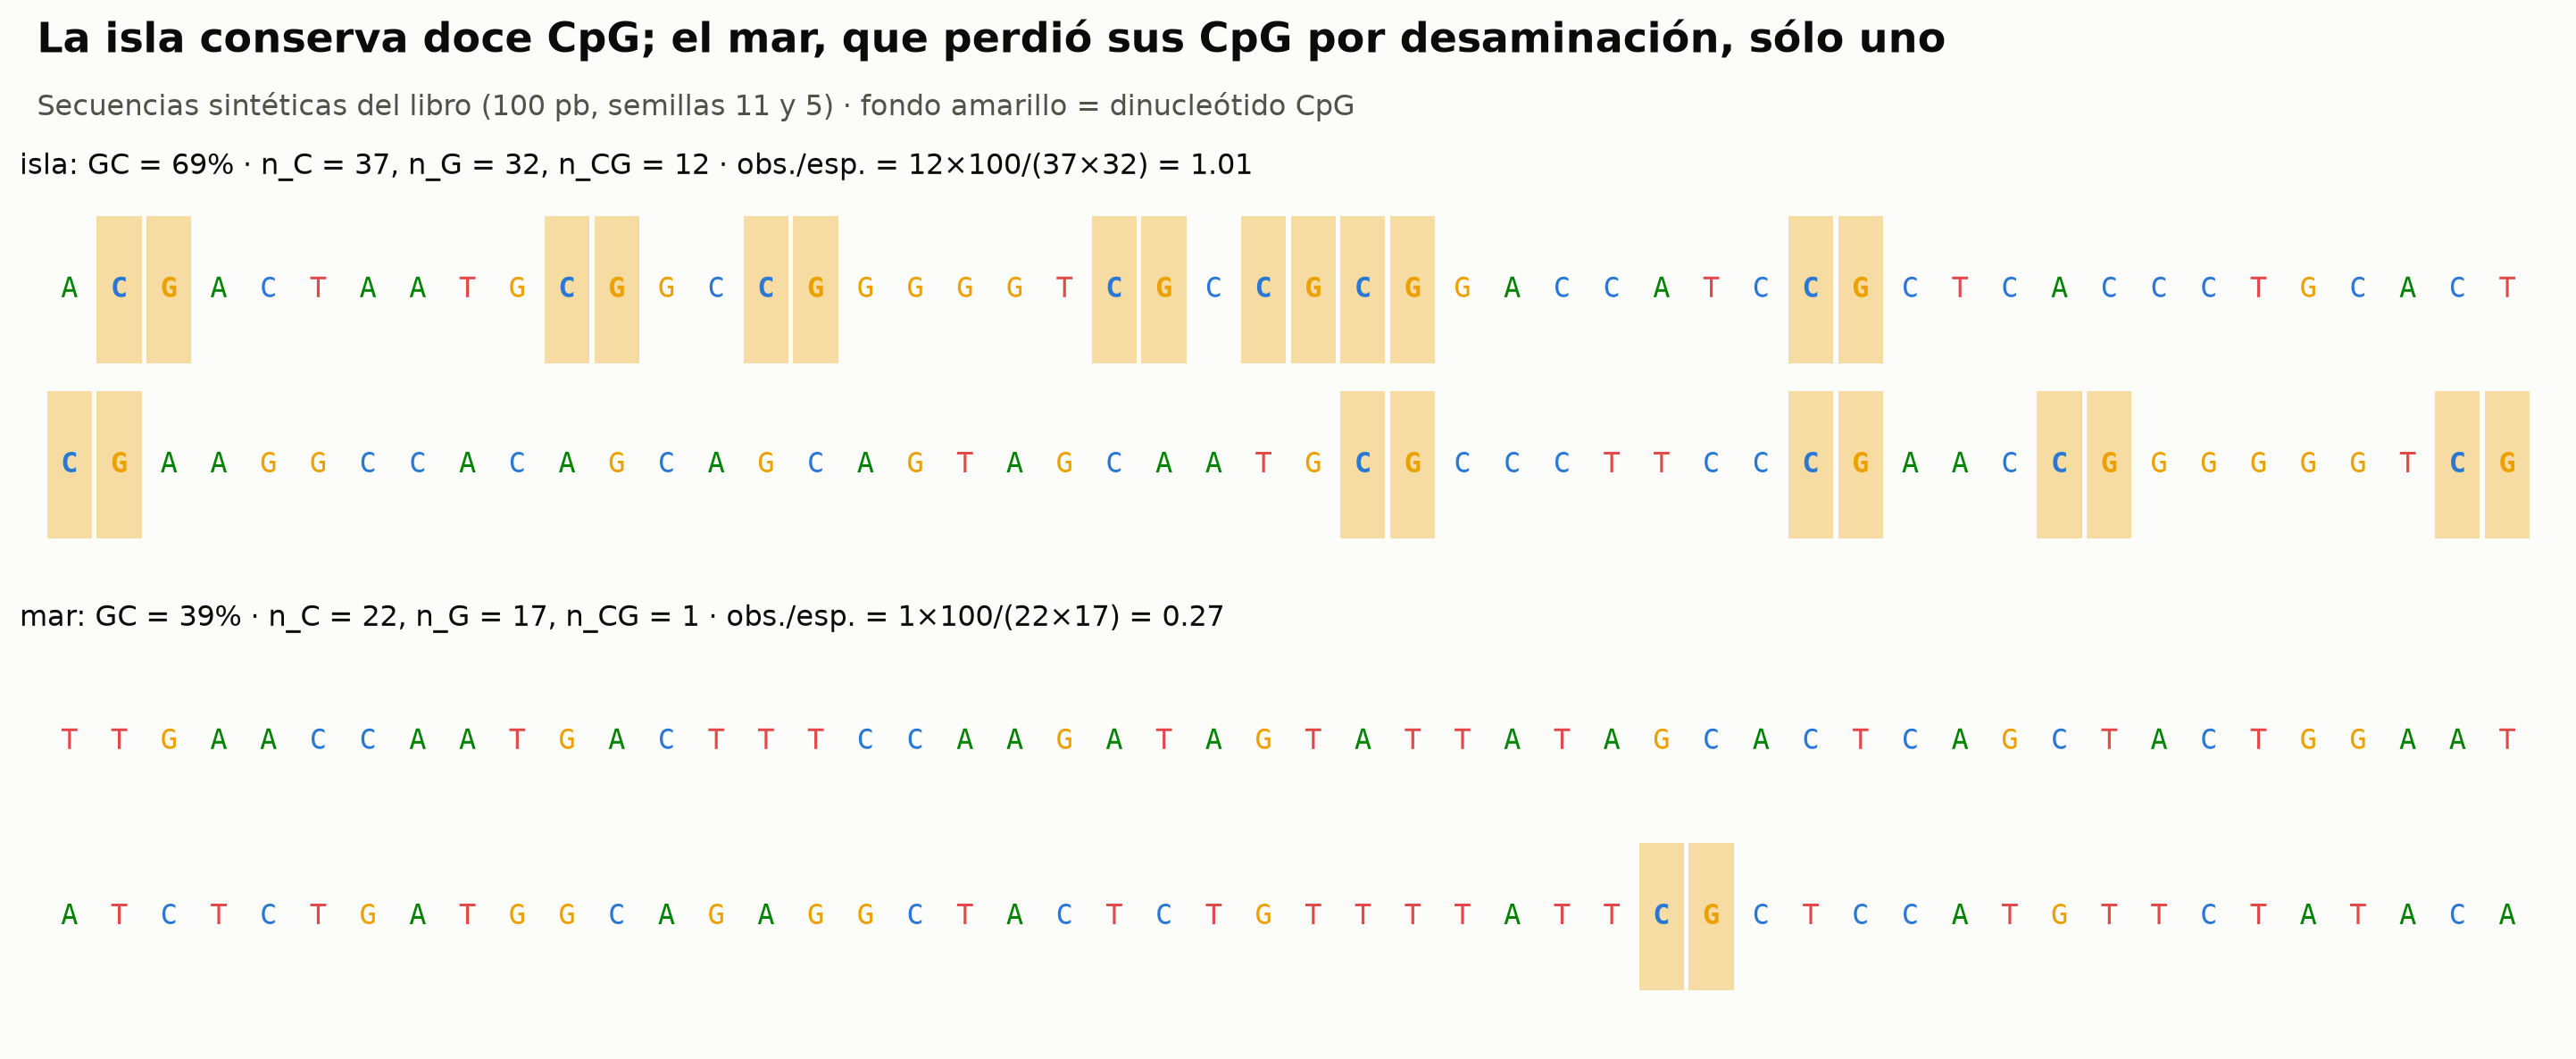

In [3]:
# Figura: las dos secuencias, base a base, con los CpG resaltados
fig, axes = plt.subplots(2, 1, figsize=(13, 4.6))
for ax, (name, s) in zip(axes, [("isla", isla), ("mar", mar)]):
    st = cpg_stats(s)
    for i, b in enumerate(s):
        x, y = i % 50, -(i // 50)
        in_cg = (b == "C" and i + 1 < len(s) and s[i + 1] == "G") or (b == "G" and i > 0 and s[i - 1] == "C")
        if in_cg:
            ax.add_patch(Rectangle((x - 0.45, y - 0.42), 0.9, 0.84, fc=ec.YELLOW, alpha=0.35, lw=0))
        ax.text(x, y, b, ha="center", va="center", fontsize=10.5, family="DejaVu Sans Mono",
                color=ec.NUC_COLORS[b], fontweight="bold" if in_cg else None)
    ax.set_xlim(-1, 50); ax.set_ylim(-1.7, 0.7); ax.axis("off")
    ax.text(-1, 0.62, f"{name}: GC = {st['GC']:.0%} · n_C = {st['nC']}, n_G = {st['nG']}, n_CG = {st['nCG']} · "
                      f"obs./esp. = {st['nCG']}×{st['L']}/({st['nC']}×{st['nG']}) = {st['OE']:.2f}",
            fontsize=10.5, color=ec.INK, va="bottom")
ec.fig_title(fig, "La isla conserva doce CpG; el mar, que perdió sus CpG por desaminación, sólo uno",
             "Secuencias sintéticas del libro (100 pb, semillas 11 y 5) · fondo amarillo = dinucleótido CpG")
plt.show()

> 🔎 **Qué observamos.** En la isla los CpG aparecen por todas partes (a veces seguidos, `CGCCGCG`); en el mar hay uno
> solo, y abundan en cambio los `TG` y `CA`, los "fósiles" de CpG que se desaminaron. La razón obs./esp. de la isla
> (1,01) dice que allí los CpG aparecen **tanto como el azar predice**; la del mar (0,27) dice que falta casi tres de cada
> cuatro.

> ✅ **Compruebe su comprensión.** ¿Por qué el criterio exige **a la vez** GC > 50 % y obs./esp. > 0,6? Piense en una
> región muy rica en GC pero con los CpG agotados (p. ej., `GGGCCCGGGCCC…`). (Respuesta: una región rica en GC tiene
> muchos CpG *esperados*; sin la razón obs./esp., cualquier tramo rico en GC parecería isla aunque sus CpG hubieran
> desaparecido. Y sin la condición de GC, una región pobre con dos o tres CpG casuales podría dar una razón alta.)

## 2. 🧪 Islas CpG en el promotor real de *GSTP1*

Pasemos de lo sintético a lo real. Descargamos (o leemos de la copia del curso) **8,2 kb del cromosoma 11 humano**
(GRCh38, chr11:67 579 800–67 588 000, coordenadas de UCSC: base 0, semiabiertas) que contienen el promotor y el gen
*GSTP1*, junto con la anotación de islas CpG de UCSC (pista `cpgIslandExt`, que usa ventanas deslizantes con el mismo
tipo de criterio) y el transcrito de referencia (RefSeq Select).

Deslizamos una ventana de **200 pb** (el mínimo del criterio) cada 25 pb y calculamos GC y obs./esp. en cada una.

In [4]:
REG_CHROM, REG_START, REG_END = "chr11", 67_579_800, 67_588_000
UCSC = (f"https://api.genome.ucsc.edu/getData/{{}}?genome=hg38;chrom={REG_CHROM};"
        f"start={REG_START};end={REG_END}")
tag = f"hg38_{REG_CHROM}_{REG_START}_{REG_END}"
seq_json = json.loads(course_bytes(f"api_cache/ucsc_sequence_{tag}.json", UCSC.format("sequence")))
cgi_json = json.loads(course_bytes(f"api_cache/ucsc_cpgIslandExt_{tag}.json", UCSC.format("track") + ";track=cpgIslandExt"))
gene_json = json.loads(course_bytes(f"api_cache/ucsc_ncbiRefSeqSelect_{tag}.json", UCSC.format("track") + ";track=ncbiRefSeqSelect"))

ref = seq_json["dna"].upper()                     # índice Python i  ↔  coordenada genómica REG_START + i
island = cgi_json["cpgIslandExt"][0]
gstp1 = [g for g in gene_json["ncbiRefSeqSelect"] if g["name2"] == "GSTP1"][0]
TSS = gstp1["txStart"]                            # hebra +: el TSS es txStart
ISL_S, ISL_E = island["chromStart"], island["chromEnd"]
print(f"Secuencia: {len(ref):,} pb · GC global = {(ref.count('C') + ref.count('G')) / len(ref):.1%}")
print(f"Isla CpG de UCSC: {REG_CHROM}:{ISL_S:,}-{ISL_E:,} ({ISL_E - ISL_S} pb, {island['cpgNum']} CpG, "
      f"GC {island['perGc']} %, obs./esp. {island['obsExp']})")
print(f"GSTP1 ({gstp1['name']}, hebra {gstp1['strand']}): TSS en {TSS:,}; exones: {gstp1['exonCount']}")
st_all = cpg_stats(ref)
print(f"Región completa: obs./esp. = {st_all['OE']:.2f}")

W, STEP = 200, 25
win = []
for i in range(0, len(ref) - W + 1, STEP):
    s = cpg_stats(ref[i:i + W])
    s["mid"] = REG_START + i + W // 2
    win.append(s)
win = pd.DataFrame(win)
win["isla_GGF"] = (win.GC > 0.5) & (win.OE > 0.6)
print(f"Ventanas de 200 pb: {len(win)} · cumplen el criterio: {win.isla_GGF.sum()}")
# tramos contiguos de ventanas que cumplen (unimos ventanas solapadas: cada una cubre mid ± 100 pb)
runs, cur = [], None
for m, ok in zip(win.mid, win.isla_GGF):
    if ok and cur and m - 100 <= cur[1]:
        cur[1] = m + 100
    elif ok:
        cur = [m - 100, m + 100]; runs.append(cur)
for a, b in runs:
    print(f"  tramo {a:,}-{b:,} ({b - a} pb){'  ← solapa la isla de UCSC' if a < ISL_E and b > ISL_S else ''}")

Secuencia: 8,200 pb · GC global = 52.9%
Isla CpG de UCSC: chr11:67,583,457-67,584,482 (1025 pb, 96 CpG, GC 70.7 %, obs./esp. 0.75)
GSTP1 (NM_000852.4, hebra +): TSS en 67,583,811; exones: 7
Región completa: obs./esp. = 0.39
Ventanas de 200 pb: 321 · cumplen el criterio: 45
  tramo 67,581,675-67,581,925 (250 pb)
  tramo 67,582,950-67,583,300 (350 pb)
  tramo 67,583,375-67,584,200 (825 pb)  ← solapa la isla de UCSC
  tramo 67,584,225-67,584,600 (375 pb)  ← solapa la isla de UCSC
  tramo 67,585,525-67,585,850 (325 pb)


> 🤔 **Antes de ejecutar, prediga:** ¿dónde espera que las ventanas superen **a la vez** GC > 50 % y obs./esp. > 0,6?
> ¿Coincidirán con la isla anotada por UCSC? ¿Esperaría ver algún tramo con GC alto pero obs./esp. bajo?

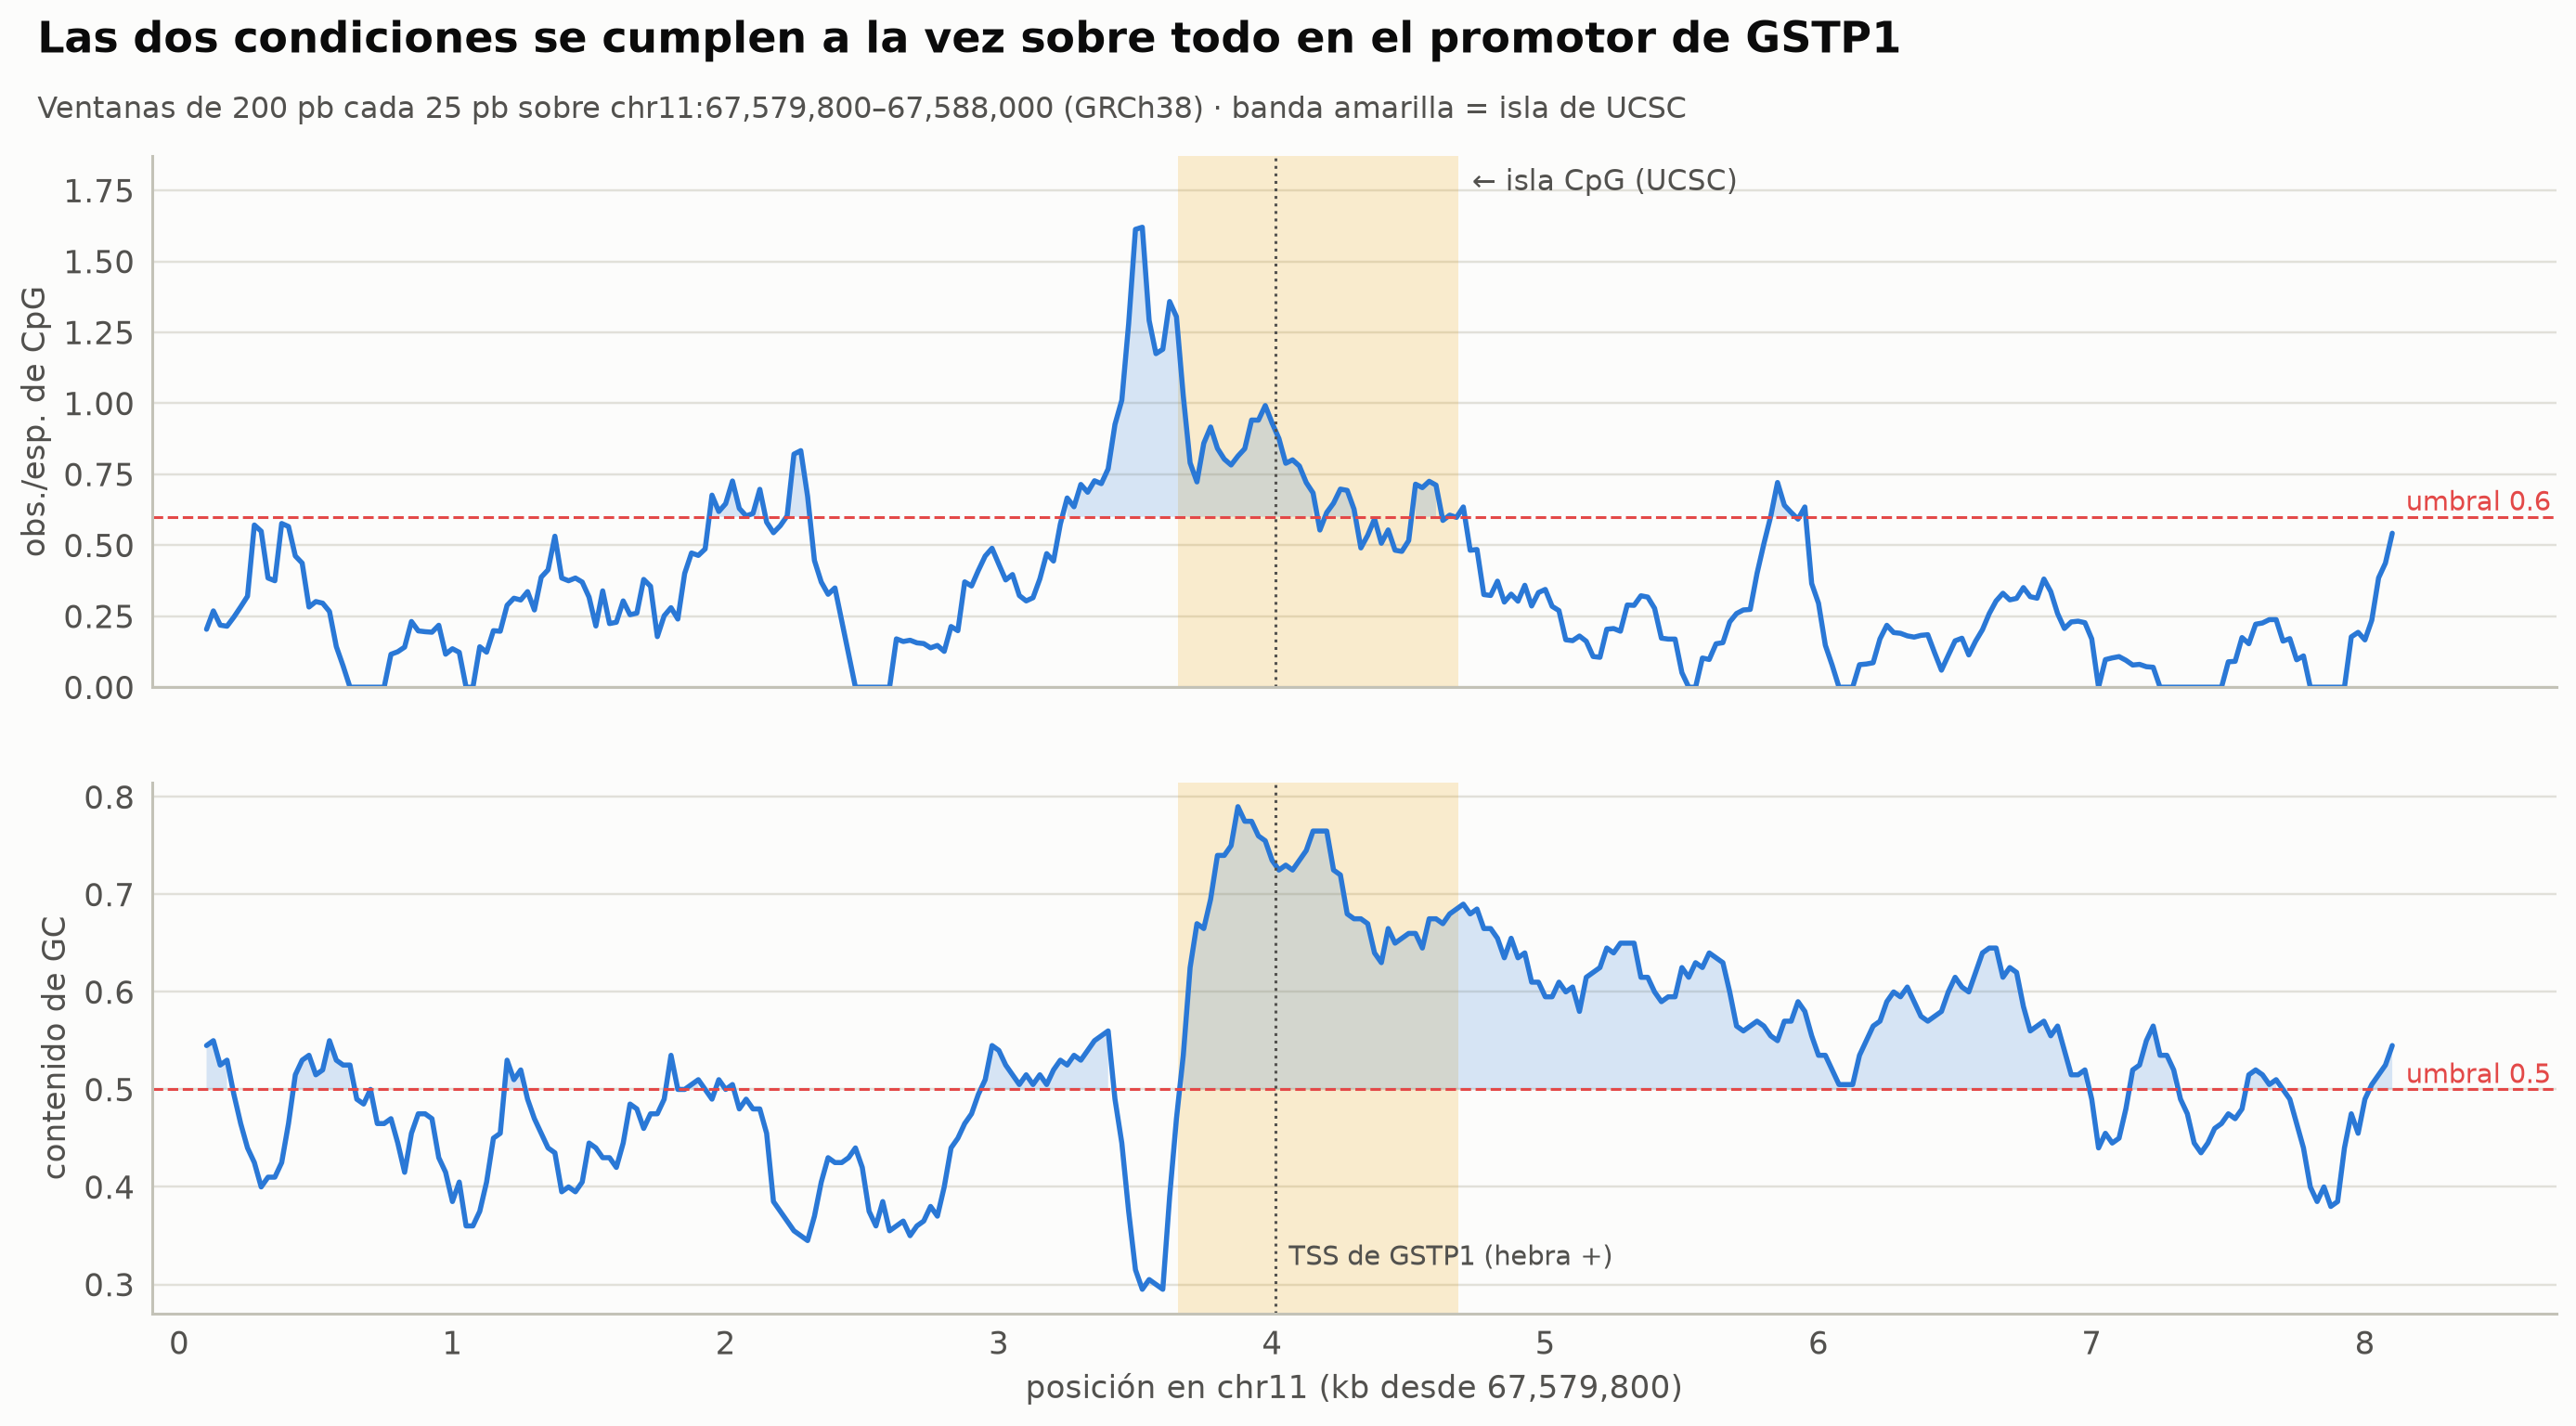

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.2), sharex=True, gridspec_kw=dict(height_ratios=[1, 1], hspace=0.12))
kb = lambda x: (np.asarray(x) - REG_START) / 1000
for ax, col, thr, lab in [(axes[0], "OE", 0.6, "obs./esp. de CpG"), (axes[1], "GC", 0.5, "contenido de GC")]:
    ax.axvspan(kb(ISL_S), kb(ISL_E), color=ec.YELLOW, alpha=0.18, lw=0)
    ax.plot(kb(win.mid), win[col], color=ec.BLUE, lw=1.8)
    ax.fill_between(kb(win.mid), thr, win[col], where=win[col] > thr, color=ec.BLUE, alpha=0.18, lw=0)
    ax.axhline(thr, color=ec.RED, ls="--", lw=1)
    ax.text(8.15, thr, f"umbral {thr}", color=ec.RED, va="bottom", ha="left", fontsize=9.5)
    ax.set_ylabel(lab)
top = win.OE.max() + 0.25
axes[0].text(kb(ISL_E) + 0.05, top - 0.12, "← isla CpG (UCSC)", ha="left", color=ec.INK_2, fontsize=10)
axes[0].set_ylim(0, top); axes[0].set_xlim(-0.1, 8.7)
for ax in axes:
    ax.axvline(kb(TSS), color=ec.INK_2, lw=1, ls=":")
axes[1].text(kb(TSS) + 0.05, 0.32, "TSS de GSTP1 (hebra +)", color=ec.INK_2, fontsize=9.5)
axes[1].set_xlabel(f"posición en {REG_CHROM} (kb desde {REG_START:,})")
ec.fig_title(fig, "Las dos condiciones se cumplen a la vez sobre todo en el promotor de GSTP1",
             "Ventanas de 200 pb cada 25 pb sobre chr11:67,579,800–67,588,000 (GRCh38) · banda amarilla = isla de UCSC")
plt.show()

> 🔎 **Qué observamos.** Fuera del promotor, la razón obs./esp. vive alrededor de 0,2–0,4 (el "mar"), aunque el GC
> supere el 50 % en buena parte del cuerpo del gen: hay tramos ricos en GC **sin** isla. Fíjese en el pico más alto de
> obs./esp. (≈ 1,6, hacia 3,5 kb): está en un tramo **pobre** en GC (≈ 30 %), donde unos pocos CpG bastan para superar a
> un número esperado diminuto. Por eso el criterio exige las dos condiciones. Las ventanas que cumplen ambas se
> concentran alrededor del TSS (de ~67 582 950 a ~67 584 600, con un par de pequeñas interrupciones), y ese bloque
> contiene la isla de UCSC (1025 pb, obs./esp. = 0,75); además pasan dos tramos cortos y aislados (~250–325 pb, hacia
> 1,9 kb y 5,8 kb) que el algoritmo de UCSC (que además enmascara repeticiones) no anota. Es un promotor de manual: una isla
> CpG que, en una célula sana, está **sin metilar**.

La versión interactiva permite leer cada ventana. Pase el ratón por las ventanas justo antes y después de la isla:
verá cómo una sola condición no basta.

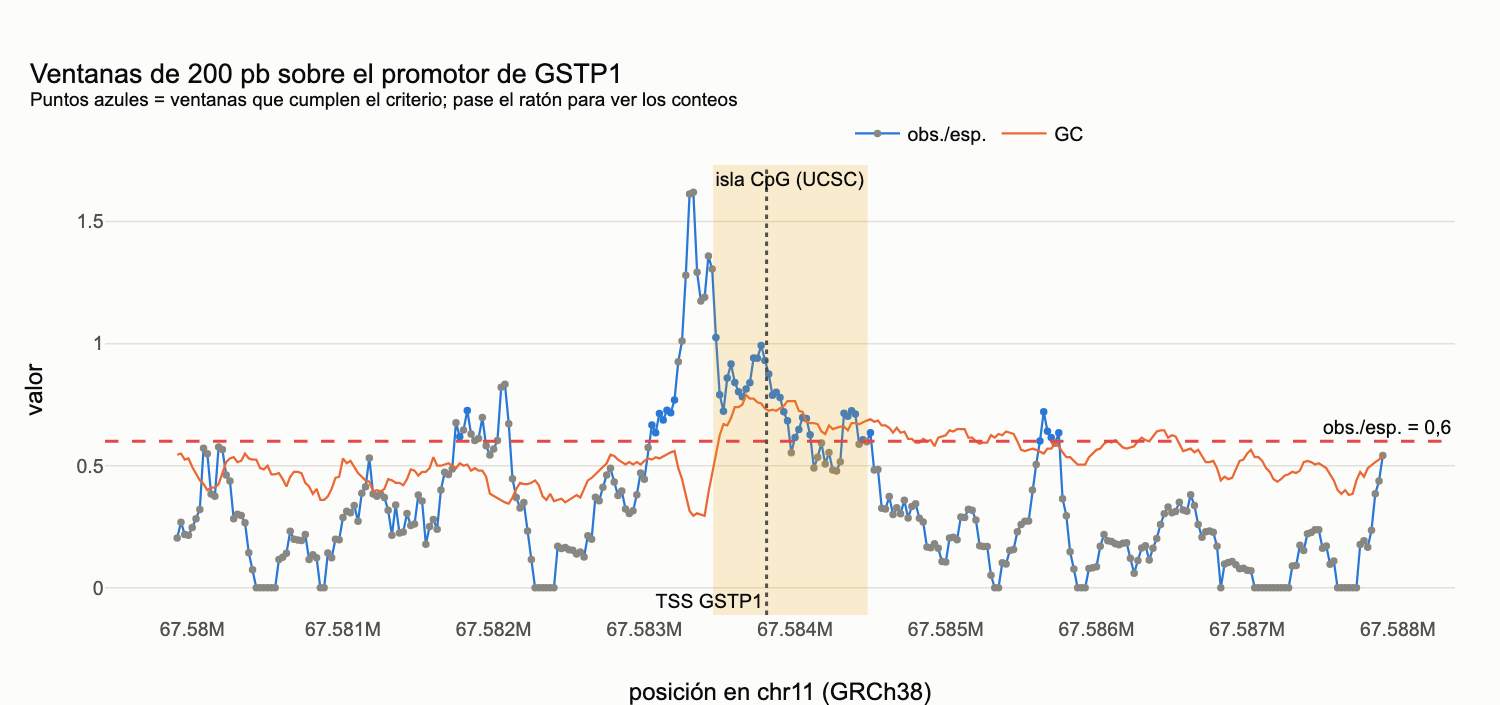

In [6]:
figw = go.Figure()
figw.add_vrect(x0=ISL_S, x1=ISL_E, fillcolor=ec.YELLOW, opacity=0.18, line_width=0,
               annotation_text="isla CpG (UCSC)", annotation_position="top right")
hover = ("ventana centrada en %{x:,}<br>GC = %{customdata[0]:.0%} · n<sub>CG</sub> = %{customdata[1]}"
         "<br>esperados n<sub>C</sub>n<sub>G</sub>/L = %{customdata[2]:.1f}<br>obs./esp. = %{y:.2f}"
         "<br><b>%{customdata[3]}</b><extra></extra>")
verdict = np.where(win.isla_GGF, "cumple GC > 50 % y obs./esp. > 0,6",
                   np.where(win.GC > 0.5, "GC alto pero CpG agotados", "GC bajo (mar genómico)"))
figw.add_trace(go.Scatter(x=win.mid, y=win.OE, mode="lines+markers", name="obs./esp.",
                          marker=dict(size=5, color=np.where(win.isla_GGF, ec.BLUE, ec.MUTED)),
                          line=dict(color=ec.BLUE, width=1.5),
                          customdata=np.c_[win.GC, win.nCG, win.nC * win.nG / win.L, verdict], hovertemplate=hover))
figw.add_trace(go.Scatter(x=win.mid, y=win.GC, mode="lines", name="GC", line=dict(color=ec.ORANGE, width=1.5),
                          hovertemplate="GC = %{y:.0%}<extra></extra>"))
figw.add_hline(y=0.6, line_dash="dash", line_color=ec.RED, annotation_text="obs./esp. = 0,6")
figw.add_vline(x=TSS, line_dash="dot", line_color=ec.INK_2, annotation_text="TSS GSTP1", annotation_position="bottom left")
figw.update_layout(height=470, margin=dict(t=110, l=70, r=30, b=60), xaxis_title=f"posición en {REG_CHROM} (GRCh38)",
                   yaxis_title="valor", legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.55),
                   title="Ventanas de 200 pb sobre el promotor de GSTP1<br><sup>Puntos azules = ventanas que cumplen el "
                         "criterio; pase el ratón para ver los conteos</sup>")
figw.show()

> ✅ **Compruebe su comprensión.** Takai y Jones (2002) propusieron un criterio más estricto (≥ 500 pb, GC ≥ 55 %,
> obs./esp. ≥ 0,65) para no confundir islas con elementos repetidos ricos en GC (como las *Alu*). ¿Sobreviviría la isla
> de *GSTP1*? (Lo comprobará en el Ejercicio 1.)

## 3. La química del bisulfito

### El problema

Ni la PCR ni los secuenciadores por síntesis distinguen 5mC de C: la polimerasa pone una G frente a ambas y el grupo
metilo **se pierde en la primera copia**. Si secuenciamos el ADN de un tumor y el de un tejido sano, las lecturas del
promotor de *GSTP1* serán idénticas letra por letra, aunque en uno esté apagado y en el otro encendido.

### La solución: una tinta química

El **bisulfito de sodio** desamina la citosina a **uracilo** en condiciones en las que la **5-metilcitosina**, protegida
por el metilo, **apenas reacciona**. Frommer *et al.* (1992) convirtieron esta reacción en un método de secuenciación que
identifica positivamente cada 5mC: tras el tratamiento se amplifica por PCR, y en el producto todos los uracilos (y las
timinas originales) aparecen como **T**, mientras que **sólo las 5mC siguen leyéndose como C**.

| Base original | Tras bisulfito | Tras PCR (lo que se lee) | Interpretación |
|---|---|---|---|
| C (no metilada) | U | **T** | "no metilada" |
| 5mC (metilada) | 5mC | **C** | "metilada" |
| A, G, T | igual | igual | — |

### Ejemplo del libro: una hebra de 14 bases

La figura del libro usa la hebra `A`**`C`**`GTCGAC`**`TT`**`C`**`GAC` con **dos CpG metilados** (posiciones 2 y 11, en
negrita), un CpG **no metilado** (posición 5) y dos citosinas **fuera de contexto CpG** (posiciones 8 y 14). Hagámoslo a
mano: las C metiladas se quedan como C; las otras tres C pasan a U y luego a T.

```
ADN genómico      A C G T C G A C T T C G A C      (C de las posiciones 2 y 11 metiladas)
tras bisulfito    A C G T U G A U T T C G A U
tras PCR          A C G T T G A T T T C G A T
lectura de la C     met.  no    no      met.  no
```

In [7]:
def bisulfite(seq, methylated, nonconv=0.0, rng=None):
    """Convierte una hebra (5'→3') como el bisulfito + PCR: cada C no metilada se lee como T.
    `methylated` = conjunto de índices de C metiladas; `nonconv` = probabilidad de que una C no metilada
    escape a la conversión (tasa de no conversión). Devuelve (tras_bisulfito, tras_pcr)."""
    after_bs, after_pcr = [], []
    for i, b in enumerate(seq):
        if b == "C" and i not in methylated and not (nonconv and rng.random() < nonconv):
            after_bs.append("U"); after_pcr.append("T")
        else:
            after_bs.append(b); after_pcr.append(b)
    return "".join(after_bs), "".join(after_pcr)

book_strand = "ACGTCGACTTCGAC"
book_meth = {1, 10}                              # índices Python de las dos 5mC (posiciones 2 y 11)
bs, pcr = bisulfite(book_strand, book_meth)
print("ADN genómico  ", " ".join(book_strand))
print("tras bisulfito", " ".join(bs))
print("tras PCR      ", " ".join(pcr))
calls = {i: ("met." if pcr[i] == "C" else "no met.") for i, b in enumerate(book_strand) if b == "C"}
print("lectura de cada C:", {i + 1: c for i, c in calls.items()})

ADN genómico   A C G T C G A C T T C G A C
tras bisulfito A C G T U G A U T T C G A U
tras PCR       A C G T T G A T T T C G A T
lectura de cada C: {2: 'met.', 5: 'no met.', 8: 'no met.', 11: 'met.', 14: 'no met.'}


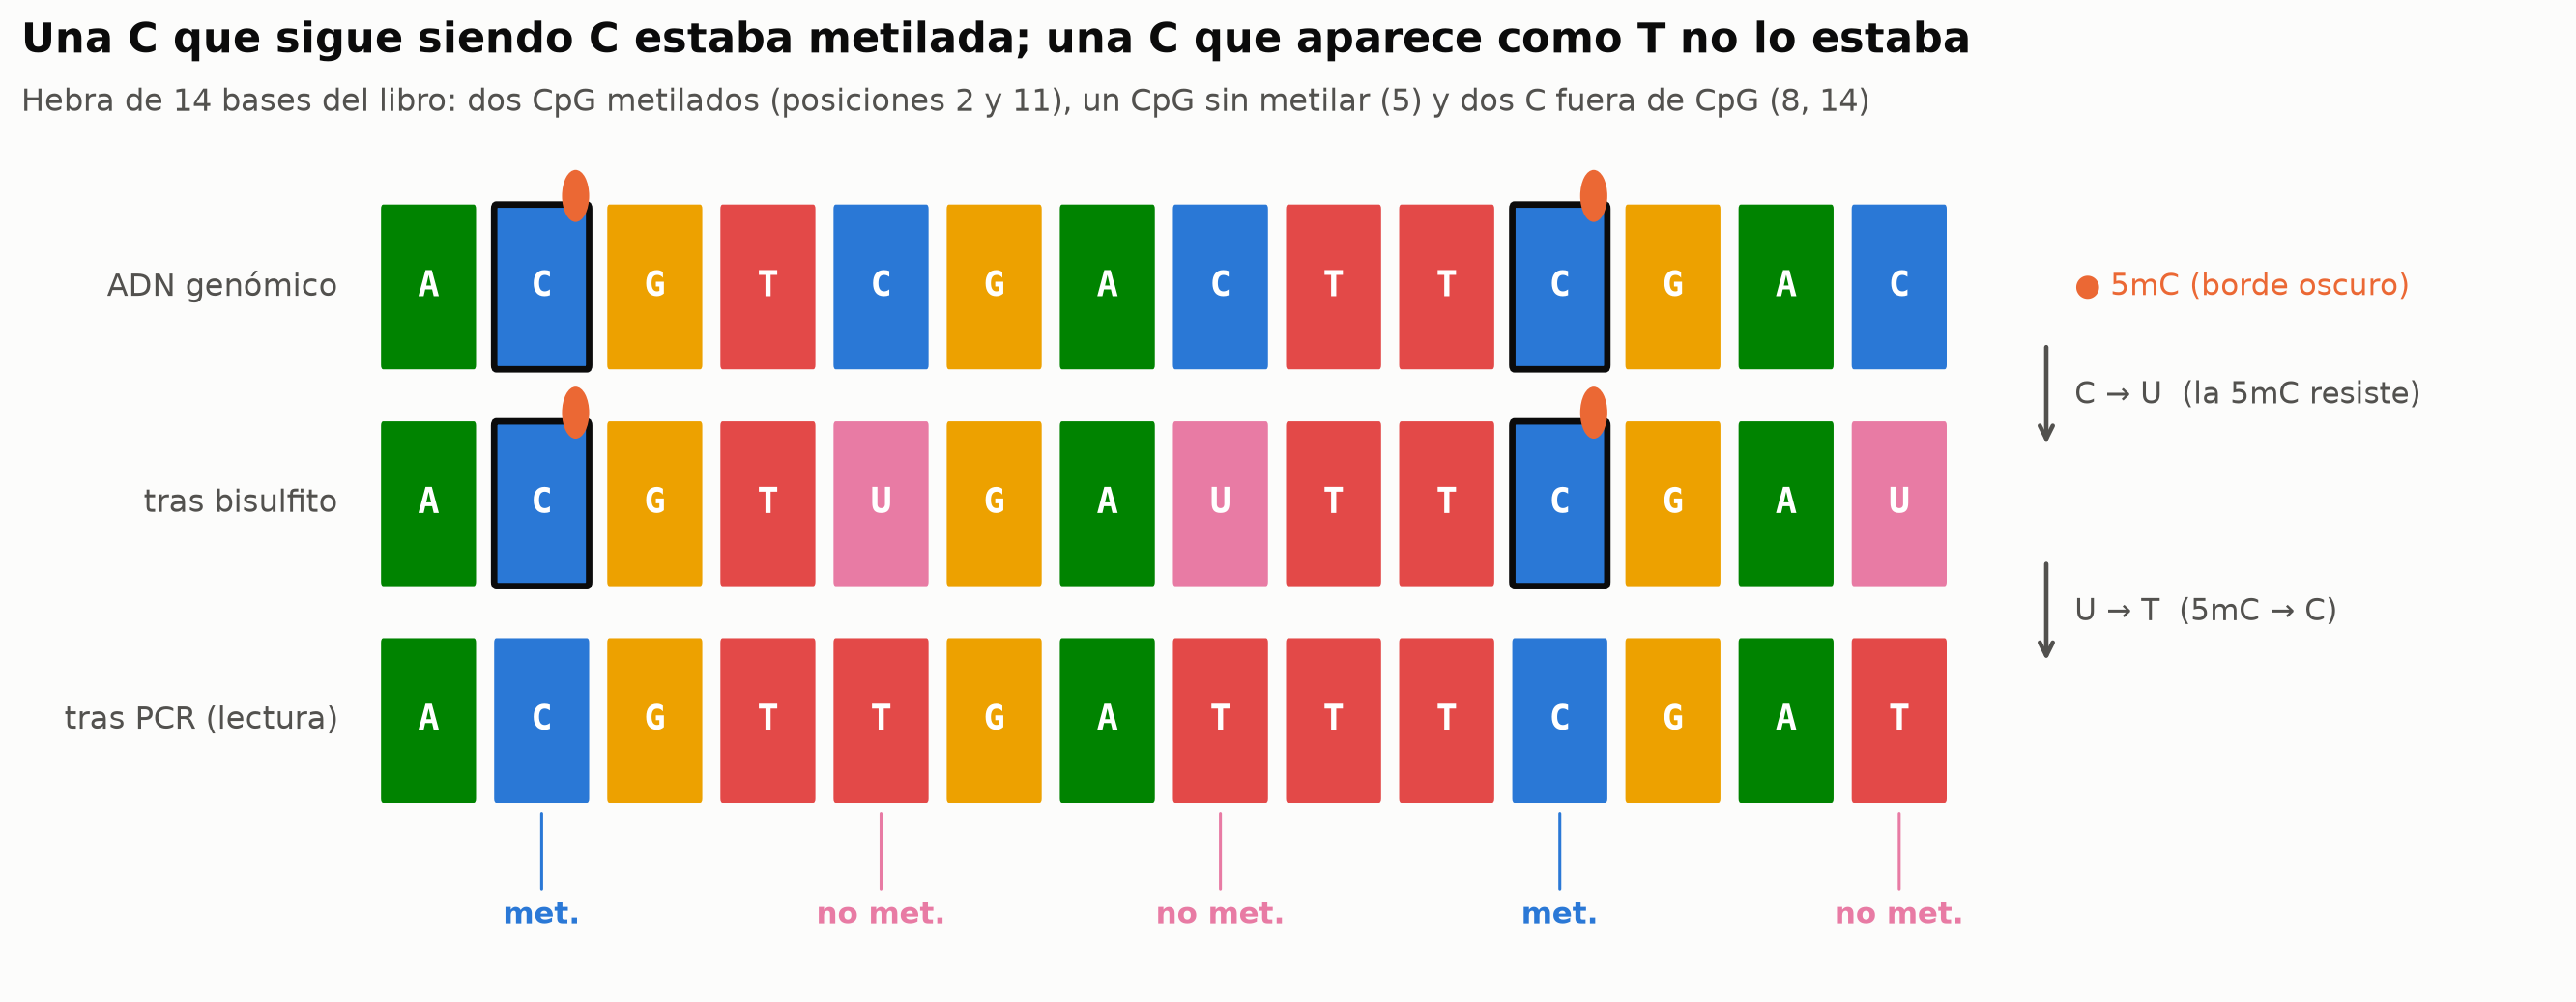

In [8]:
def draw_row(ax, y, seq, label, meth=(), highlight_u=True):
    ax.text(-0.8, y, label, ha="right", va="center", fontsize=10.5, color=ec.INK_2)
    for i, b in enumerate(seq):
        fc = ec.MAGENTA if (b == "U" and highlight_u) else ec.NUC_COLORS.get(b, ec.MUTED)
        ax.add_patch(FancyBboxPatch((i - 0.4, y - 0.36), 0.8, 0.72, boxstyle="round,pad=0.02", fc=fc,
                                    ec=ec.INK if i in meth else "none", lw=2.2 if i in meth else 0))
        ax.text(i, y, b, ha="center", va="center", color="white", fontsize=12, fontweight="bold",
                family="DejaVu Sans Mono")
        if i in meth:
            ax.add_patch(Circle((i + 0.3, y + 0.42), 0.12, color=ec.ORANGE, zorder=5))

fig, ax = plt.subplots(figsize=(12, 4.6))
draw_row(ax, 3, book_strand, "ADN genómico", meth=book_meth)
draw_row(ax, 2, bs, "tras bisulfito", meth=book_meth)
draw_row(ax, 1, pcr, "tras PCR (lectura)")
for i, c in calls.items():
    col = ec.BLUE if c == "met." else ec.MAGENTA
    ax.annotate(c, (i, 0.6), (i, 0.1), ha="center", va="center", color=col, fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=col, lw=1))
for y, t in [(2.5, "C → U  (la 5mC resiste)"), (1.5, "U → T  (5mC → C)")]:
    ax.annotate("", (14.3, y - 0.25), (14.3, y + 0.25), arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.5))
    ax.text(14.55, y, t, va="center", fontsize=10, color=ec.INK_2)
ax.text(14.55, 3, "● 5mC (borde oscuro)", va="center", fontsize=10, color=ec.ORANGE)
ax.set_xlim(-3.6, 18.8); ax.set_ylim(-0.2, 3.7); ax.axis("off")
ec.title(ax, "Una C que sigue siendo C estaba metilada; una C que aparece como T no lo estaba",
         "Hebra de 14 bases del libro: dos CpG metilados (posiciones 2 y 11), un CpG sin metilar (5) y dos C fuera de CpG (8, 14)")
plt.show()

> 🔎 **Qué observamos.** Tras el bisulfito, la hebra ya **no es complementaria** de la original (tiene U donde había C):
> por eso cada una de las dos hebras del genoma produce, tras la conversión, lecturas **distintas**, y un análisis de
> bisulfito tiene que considerar las dos hebras por separado. Observe también que las C fuera de CpG (posiciones 8 y 14)
> se convierten: en la mayoría de los tejidos adultos casi no se metilan, y eso nos servirá de **control interno**.

### 🎬 Animación: la conversión de una lectura real del promotor de *GSTP1*

Tomemos 36 pb reales de la isla de *GSTP1*, justo en el TSS, y dos moléculas: una de un **tumor** (todos sus CpG
metilados, el gen está apagado) y otra de **tejido sano** (ningún CpG metilado). La animación recorre la hebra C por C:
primero el bisulfito convierte las C no protegidas en U; luego la PCR copia cada U como T; al final comparamos cada
lectura con la referencia.

![El bisulfito convierte, C por C, las citosinas no metiladas; tras la PCR, sólo los CpG del tumor siguen como C](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-13-epigenomica/13.2_bisulfito_lectura.gif)

*El bisulfito convierte, C por C, las citosinas no metiladas; tras la PCR, sólo los CpG del tumor siguen como C*

In [9]:
seg_start = TSS - REG_START - 12
segment = ref[seg_start:seg_start + 36]
cpg_c = [i for i in range(len(segment) - 1) if segment[i:i + 2] == "CG"]
c_idx = [i for i, b in enumerate(segment) if b == "C"]
print("Segmento:", segment, f"({len(cpg_c)} CpG, {len(c_idx)} citosinas)")
molecules = {"tumor (CpG metilados)": set(cpg_c), "tejido sano (sin metilar)": set()}

fig, ax = plt.subplots(figsize=(13, 5.4))
ax.set_xlim(-6.5, 36.5); ax.set_ylim(-0.9, 5.2); ax.axis("off")
ax.set_title("Bisulfito + PCR sobre 36 pb del promotor de GSTP1 (TSS en la posición 13)", loc="left", fontsize=12.5)
rows = {"ref": 4.3, "tumor (CpG metilados)": 2.9, "tejido sano (sin metilar)": 1.3}
boxes, texts = {}, {}
ax.text(-0.7, rows["ref"], "referencia", ha="right", va="center", fontsize=10, color=ec.INK_2)
for i, b in enumerate(segment):
    ax.text(i, rows["ref"], b, ha="center", va="center", fontsize=11, family="DejaVu Sans Mono",
            color=ec.NUC_COLORS[b], fontweight="bold")
for name, meth in molecules.items():
    y = rows[name]
    ax.text(-0.7, y, name.split(" (")[0], ha="right", va="center", fontsize=10.5, color=ec.INK,
            fontweight="bold")
    ax.text(-0.7, y - 0.42, "(" + name.split(" (")[1], ha="right", va="center", fontsize=8.5, color=ec.INK_2)
    for i, b in enumerate(segment):
        boxes[name, i] = FancyBboxPatch((i - 0.42, y - 0.36), 0.84, 0.72, boxstyle="round,pad=0.02",
                                        fc=ec.NUC_COLORS[b], ec=ec.INK if i in meth else "none", lw=2 if i in meth else 0)
        ax.add_patch(boxes[name, i])
        texts[name, i] = ax.text(i, y, b, ha="center", va="center", color="white", fontsize=10.5,
                                 fontweight="bold", family="DejaVu Sans Mono")
        if i in meth:
            ax.add_patch(Circle((i + 0.3, y + 0.42), 0.11, color=ec.ORANGE, zorder=5))
cursor = ax.axvspan(-0.5, 0.5, color=ec.YELLOW, alpha=0.0, lw=0)
status = ax.text(-6.3, -0.55, "", fontsize=11, color=ec.INK, va="center")
marks = [ax.text(i, 0.35, "", ha="center", va="center", fontsize=9, fontweight="bold") for i in range(len(segment))]

n_conv = len(c_idx)
frames = 2 + n_conv + 4 + 6

def update(f):
    if f < 2:
        status.set_text("Dos moléculas con la misma secuencia; sólo el tumor tiene 5mC (borde oscuro, punto naranja)")
    elif f < 2 + n_conv:
        i = c_idx[f - 2]
        cursor.set_x(i - 0.5); cursor.set_alpha(0.35)
        for name, meth in molecules.items():
            if i not in meth:
                boxes[name, i].set_facecolor(ec.MAGENTA); texts[name, i].set_text("U")
        prot = "protegida en el tumor" if i in cpg_c else "no está en un CpG: se convierte en ambas"
        status.set_text(f"Bisulfito · C en la posición {i + 1}: {prot}")
    elif f < 2 + n_conv + 4:
        cursor.set_alpha(0)
        for name in molecules:
            for i in c_idx:
                if texts[name, i].get_text() == "U":
                    boxes[name, i].set_facecolor(ec.NUC_COLORS["T"]); texts[name, i].set_text("T")
        status.set_text("PCR: la polimerasa copia cada U como T (y cada 5mC como una C normal)")
    else:
        for i in c_idx:
            if i in cpg_c:
                marks[i].set_text("CpG"); marks[i].set_color(ec.BLUE)
        n_t = sum(texts["tumor (CpG metilados)", i].get_text() == "C" for i in cpg_c)
        n_n = sum(texts["tejido sano (sin metilar)", i].get_text() == "C" for i in cpg_c)
        status.set_text(f"Lectura: en los {len(cpg_c)} CpG, el tumor conserva {n_t} C (metilado) y el tejido sano "
                        f"{n_n} (no metilado)")
    return [status, cursor] + marks

ec.animate(fig, update, frames=frames, interval=260, name="13.2_bisulfito_lectura")

Segmento: CGCGAGGCCTTCGCTGGAGTTTCGCCGCCGCAGTCT (6 CpG, 13 citosinas)


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Todas las C que no están en un CpG se convierten en las dos moléculas; las diferencias entre
> tumor y tejido sano quedan confinadas a los CpG. Después de la PCR, **la marca química se ha convertido en una
> diferencia de secuencia** (C frente a T) que cualquier secuenciador puede leer. Fíjese también en el precio: las dos
> lecturas son ahora muy pobres en C, casi escritas con **tres letras** (A, G, T). Ese detalle complica el alineamiento.

> ✅ **Compruebe su comprensión.** Si la conversión fuera incompleta (digamos que el 2 % de las C no metiladas escapan
> a la reacción), ¿en qué dirección se sesgaría el nivel de metilación estimado? ¿Cómo lo detectaría usando las C fuera
> de CpG? (Respuesta: hacia **arriba**, porque esas C se leerían como "metiladas". En tejidos donde la metilación fuera de
> CpG es casi nula, la fracción de C que sobreviven en contexto CHH estima directamente la tasa de no conversión;
> también se añade ADN control sin metilar, como el del fago lambda.)

## 4. WGBS y alineamiento: un Bismark en miniatura

La secuenciación con bisulfito del **genoma completo** (WGBS) aplica la conversión a una biblioteca de todo el genoma.
Lister *et al.* (2009) publicaron así los primeros metilomas humanos con resolución de una base (células madre
embrionarias y fibroblastos fetales) y descubrieron que casi una cuarta parte de la metilación de las células madre
estaba **fuera** del contexto CG, una forma que desaparecía al diferenciarse.

### El problema del alineamiento

Un alineador convencional penalizaría cada T de la lectura frente a una C de la referencia: una lectura de 100 pb de una
región poco metilada tiene ~20 "desajustes" sólo por el bisulfito. Pero tampoco basta con permitir esos desajustes sin
costo: la lectura convertida está escrita casi en un **alfabeto de tres letras**, su **complejidad baja** y muchas
lecturas mapearían en varios lugares.

Lo comprobamos con 300 kb reales del cromosoma 17 (la región de *TP53* que usamos en la Lección 4.3): ¿qué fracción de
las palabras de longitud $k$ aparece **más de una vez** en el alfabeto normal y en el alfabeto convertido C→T?

In [10]:
raw17 = course_bytes("NC_000017.11_7400001-7700000.fasta.gz")
chr17 = "".join(l.strip() for l in gzip.decompress(raw17).decode().splitlines() if not l.startswith(">")).upper()

def repeated_fraction(s, k):
    """Fracción de posiciones cuya palabra de longitud k aparece más de una vez en s."""
    words = pd.Series([s[i:i + k] for i in range(len(s) - k + 1)])
    return words.map(words.value_counts()).gt(1).mean()

comp = pd.DataFrame([(k, repeated_fraction(chr17, k), repeated_fraction(chr17.replace("C", "T"), k))
                     for k in (12, 16, 20)], columns=["k", "4 letras (ACGT)", "3 letras (C→T)"])
print(comp.round(3).to_string(index=False))

 k  4 letras (ACGT)  3 letras (C→T)
12            0.255           0.695
16            0.160           0.311
20            0.113           0.198


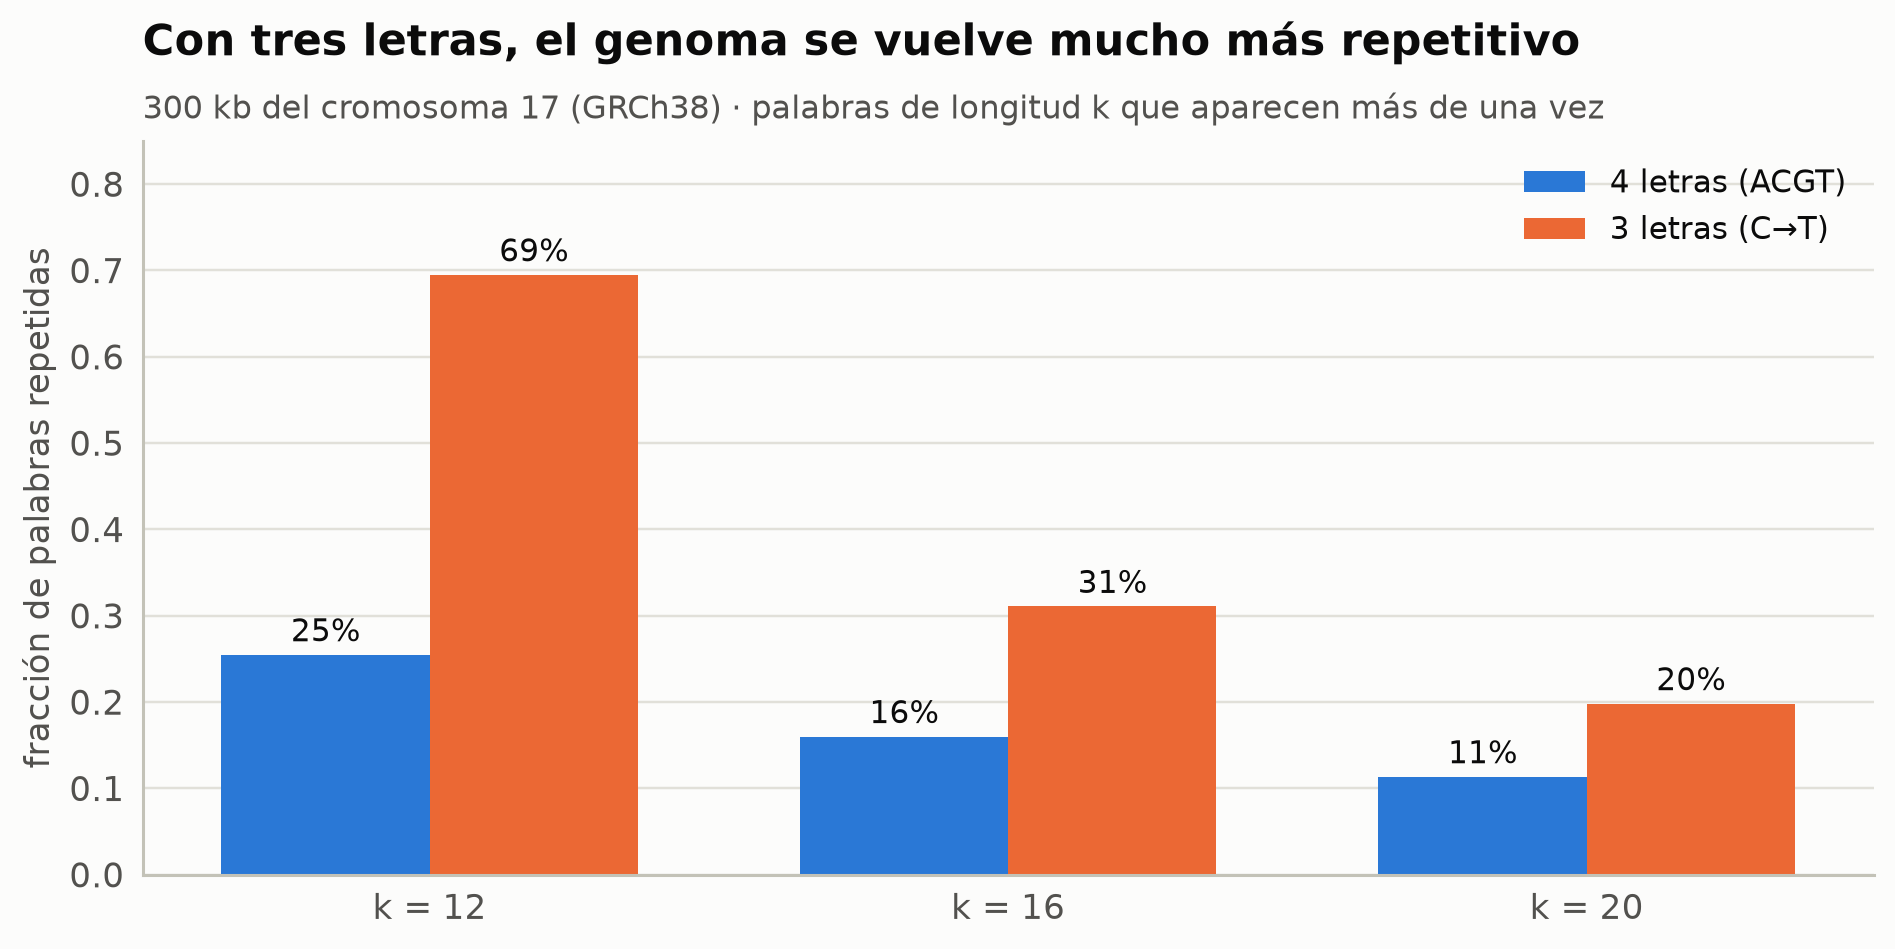

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(comp)); w = 0.36
for j, (col, color) in enumerate([("4 letras (ACGT)", ec.BLUE), ("3 letras (C→T)", ec.ORANGE)]):
    bars = ax.bar(x + (j - 0.5) * w, comp[col], w, color=color, label=col)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in comp[col]], padding=2, fontsize=10)
ax.set_xticks(x, [f"k = {k}" for k in comp.k]); ax.set_ylabel("fracción de palabras repetidas")
ax.set_ylim(0, 0.85); ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Con tres letras, el genoma se vuelve mucho más repetitivo",
         "300 kb del cromosoma 17 (GRCh38) · palabras de longitud k que aparecen más de una vez")
plt.show()

> 🔎 **Qué observamos.** Con $k = 12$, una de cada cuatro palabras del genoma normal está repetida; tras convertir C→T,
> casi **siete de cada diez**. Las semillas cortas que usan los alineadores para encontrar candidatos pierden poder de
> discriminación, y por eso las lecturas de bisulfito se alinean más despacio y con menor tasa de mapeo único.

### La estrategia de Bismark

La solución de Bismark (Krueger y Andrews, 2011) es **convertirlo todo** de forma computacional **antes** de alinear:

1. En las lecturas se reemplazan todas las C por T.
2. El genoma se prepara en **dos versiones**: una con todas las C convertidas en T (para lecturas de la hebra superior)
   y otra con todas las G convertidas en A (para la inferior, porque una C de la hebra inferior está frente a una G de la
   superior).
3. Cada lectura se alinea con un alineador estándar (Bowtie 2) contra las versiones convertidas en todas las
   combinaciones de hebra; se conserva **sólo el alineamiento único con menos desajustes**.
4. Una vez ubicada, se compara la lectura **original** con la referencia **original** para llamar la metilación de cada
   citosina, distinguiendo los contextos **CpG**, **CHG** y **CHH** (H = A, C o T).

Con la lectura de ejemplo del libro: la original `ATTGATTTCGAT` se convierte en `ATTGATTTTGAT`; en el espacio
convertido se alinea sin desajustes; al volver a la original, la **C** del `CG` dice "CpG metilado" y las T que caen
frente a C de la referencia dicen "no metiladas".

En la práctica (no se ejecuta aquí):

```bash
bismark_genome_preparation genoma/            # versiones C->T y G->A
bismark --genome genoma/ -1 m1_R1.fq.gz -2 m1_R2.fq.gz
deduplicate_bismark --bam m1_R1_bismark_bt2_pe.bam
bismark_methylation_extractor --bedGraph --cytosine_report \
    --genome_folder genoma/ m1_R1_bismark_bt2_pe.deduplicated.bam
# salida: por cada CpG, lecturas metiladas y no metiladas
```

### El producto final: datos reales de ENCODE

Antes de programar nuestro alineador, veamos **qué produce** este flujo en un proyecto real. ENCODE procesó el WGBS de
cada muestra con su propio flujo de bisulfito y publica, por cada citosina, un archivo *bedMethyl*: posición, hebra,
**cobertura** $n$ y **porcentaje metilado**. Guardamos en el curso la región de *GSTP1* de seis muestras (el archivo
completo pesa más de 1 GB; al final de esta sección hay una celda opcional para descargar cualquier región desde
ENCODE). Como el archivo trae el porcentaje redondeado a un entero, reconstruimos las lecturas metiladas como
$c = \operatorname{round}(n \cdot \%/100)$, exacto mientras $n < 100$.

In [12]:
samples = pd.read_csv(io.BytesIO(course_bytes("132_wgbs_samples.tsv")), sep="\t")
wgbs = pd.read_csv(io.BytesIO(course_bytes("132_gstp1_wgbs_encode.tsv.gz")), sep="\t", compression="gzip")
A_S = samples.loc[samples.group == "normal", "sample"].tolist()      # grupo A: hígado normal (3 donantes)
B_S = samples.loc[samples.group == "tumor", "sample"].tolist()       # grupo B: HepG2 (3 réplicas)
print(samples.to_string(index=False))
print(f"\nFilas (una por citosina de CpG y hebra, por muestra): {len(wgbs):,}")
wgbs.head()

   sample  group                    description  experiment        file       donor
liver_hep normal          hepatocitos primarios ENCSR351IPU ENCFF789HII ENCDO222AAA
liver_OMA normal                hígado (tejido) ENCSR713WYJ ENCFF505YJQ ENCDO478OMA
liver_LXB normal      lóbulo derecho del hígado ENCSR108ESU ENCFF613NEE ENCDO793LXB
 HepG2_a1  tumor HepG2, experimento 1 réplica 1 ENCSR881XOU ENCFF067KKG ENCDO000AAC
 HepG2_a2  tumor HepG2, experimento 1 réplica 2 ENCSR881XOU ENCFF857YRG ENCDO000AAC
 HepG2_b1  tumor HepG2, experimento 2 réplica 1 ENCSR786DCL ENCFF848FTR ENCDO000AAC

Filas (una por citosina de CpG y hebra, por muestra): 2,373


,sample,chrom,start,strand,cov,meth,geno
0,liver_hep,chr11,67579825,+,6,5,CG
1,liver_hep,chr11,67579826,-,8,6,CG
2,liver_hep,chr11,67579909,+,9,7,CG
3,liver_hep,chr11,67579910,-,6,2,CG
4,liver_hep,chr11,67579995,+,12,11,CG


Cada CpG aparece **dos veces** por muestra: la C de la hebra `+` (en la posición `start`) y la C de la hebra `−` (una
base más a la derecha, frente a la G). Como la metilación de CpG es simétrica, sumamos ambas hebras y usamos como
coordenada la C de la hebra `+`. La columna `geno` es el genotipo que el flujo de ENCODE infiere de las propias lecturas
en esas dos bases (`CG` = referencia); la usaremos en la sección 8.

In [13]:
wgbs["cpg"] = np.where(wgbs.strand == "+", wgbs.start, wgbs.start - 1)
per_cpg = (wgbs.groupby(["cpg", "sample"])[["cov", "meth"]].sum().unstack(fill_value=0))
N_raw, C_raw = per_cpg["cov"][A_S + B_S], per_cpg["meth"][A_S + B_S]
summary = pd.DataFrame({"CpG con datos": (N_raw > 0).sum(), "cobertura media": N_raw[N_raw > 0].mean().round(1),
                        "β de toda la región": (C_raw.sum() / N_raw.sum()).round(3)})
print(summary.to_string())

           CpG con datos  cobertura media  β de toda la región
sample                                                        
liver_hep            222             11.6                0.509
liver_OMA            225             38.0                0.563
liver_LXB            222              5.5                0.439
HepG2_a1             219              9.1                0.614
HepG2_a2             204              5.1                0.610
HepG2_b1             225              7.9                0.550


Las coberturas son las típicas de WGBS: entre 5 y 12 lecturas por CpG en la mayoría de las muestras y casi 40 en una de
ellas (`liver_OMA`). Retengamos ese contraste: volverá cuando hablemos de incertidumbre.

### Simular lecturas de bisulfito y alinearlas desde cero

Ahora sí, construimos un Bismark en miniatura sobre los 8,2 kb de *GSTP1*. Como "verdad" usamos el nivel de metilación
real de HepG2 en cada CpG (las C fuera de CpG, sin metilar). Simulamos 3000 fragmentos de 100 pb de una biblioteca
**direccional**: la mitad son lecturas de la hebra original superior (OT) y la otra mitad de la hebra original inferior
(OB, secuenciada 5'→3' sobre esa hebra). Añadimos una tasa de no conversión del 0,5 % y un 0,3 % de errores de
secuenciación.

In [14]:
def revcomp(s):
    return s[::-1].translate(str.maketrans("ACGT", "TGCA"))

cpg_idx = np.array([i for i in range(len(ref) - 1) if ref[i:i + 2] == "CG"])      # índice de la C de cada CpG
hep_beta = (C_raw[B_S].sum(axis=1) / N_raw[B_S].sum(axis=1).replace(0, np.nan))
true_beta = pd.Series(hep_beta.reindex(REG_START + cpg_idx).values, index=cpg_idx).fillna(0.5)

def simulate_reads(n_reads, read_len=100, nonconv=0.005, err=0.003, rng=rng):
    """Biblioteca direccional: cada lectura es la hebra OT u OB tras bisulfito + PCR."""
    reads = []
    for _ in range(n_reads):
        s = int(rng.integers(0, len(ref) - read_len))
        frag = ref[s:s + read_len]
        strand = "OT" if rng.random() < 0.5 else "OB"
        if strand == "OT":
            meth = {i for i in range(read_len) if (s + i) in true_beta.index and rng.random() < true_beta[s + i]}
            _, read = bisulfite(frag, meth, nonconv, rng)
        else:
            bot = revcomp(frag)                      # hebra inferior, 5'→3'
            # la C de la hebra inferior en el índice j está frente a la G de la superior en s + L-1-j;
            # es CpG si esa G forma parte de un CG de la superior (C en s + L-2-j)
            meth = {j for j in range(read_len) if (s + read_len - 2 - j) in true_beta.index
                    and rng.random() < true_beta[s + read_len - 2 - j]}
            _, read = bisulfite(bot, meth, nonconv, rng)
        read = "".join(rng.choice(list("ACGT".replace(b, ""))) if rng.random() < err else b for b in read)
        reads.append((read, s, strand))
    return reads

t0 = time.time()
reads = simulate_reads(3000)
print(f"{len(reads)} lecturas simuladas en {time.time() - t0:.1f} s")
for r, s, st in reads[:3]:
    ref_view = ref[s:s + 100] if st == "OT" else revcomp(ref[s:s + 100])
    print(f"\n{st} desde {REG_START + s:,}\nreferencia {ref_view[:60]}\nlectura    {r[:60]}")

3000 lecturas simuladas en 0.5 s

OB desde 67,586,730
referencia TCTTTTTTTTTCTTCCTCTTCTAGTTTGTGAGGTTCAGTAAACACAGCCAGGCTGAGGGC
lectura    TTTTTTTTTTTTTTTTTTTTTTAGTTTGTGAGGTTTAGTAAATATAGTTAGGTTGAGGGT

OB desde 67,580,955
referencia ATGTTGCCGCAGCTGGTCTGGAACTCTTGGCCCCAAGTGATCCTCCTGCCTTACTTAGCC
lectura    ATGTTGTCGTAGTTGGTTTGGAATTTTTGGTTTTAAGTGATTTTTTTGTTTTATTTAGTT

OB desde 67,580,500
referencia CTATCTGGAAAATGGCCCTTCTAATCTATCCTCCTATCACTTTACTGCCTTTTTTTTTTT
lectura    TTATTTGGAAAATGGTTTTTTTAATTTATTTTTTTATTATTTTATTGTTTTTTTTTTTTT


Nuestro alineador sigue la receta de Bismark con una simplificación honesta: en lugar de Bowtie 2 usamos **semillas
exactas** de 20 pb (un índice de palabras del genoma convertido) y verificamos cada candidato contando desajustes
(distancia de Hamming). Para comparar, un **alineador ingenuo** busca las mismas semillas en el genoma **sin
convertir**, probando la lectura y su complemento inverso.

In [15]:
K = 20
def kmer_index(g):
    idx = {}
    for i in range(len(g) - K + 1):
        idx.setdefault(g[i:i + K], []).append(i)
    return idx

def hamming(a, b):
    return sum(x != y for x, y in zip(a, b))

def best_hit(query, genome, index, max_mm=6):
    """Semillas en 0, 40 y 80; devuelve (posición, desajustes, único) del mejor candidato o None."""
    cands = set()
    for off in (0, 40, 80):
        for p in index.get(query[off:off + K], []):
            if 0 <= p - off <= len(genome) - len(query):
                cands.add(p - off)
    scored = sorted((hamming(query, genome[c:c + len(query)]), c) for c in cands)
    if not scored or scored[0][0] > max_mm:
        return None
    unique = len(scored) == 1 or scored[1][0] > scored[0][0]
    return scored[0][1], scored[0][0], unique

ref_CT, ref_GA = ref.replace("C", "T"), ref.replace("G", "A")
idx_CT, idx_GA, idx_raw = kmer_index(ref_CT), kmer_index(ref_GA), kmer_index(ref)

def bismark_align(read):
    """Lectura C→T contra el genoma C→T (OT) y, complemento inverso, contra el genoma G→A (OB)."""
    r_ct = read.replace("C", "T")
    hits = []
    h = best_hit(r_ct, ref_CT, idx_CT)
    if h: hits.append(("OT",) + h)
    h = best_hit(revcomp(r_ct), ref_GA, idx_GA)
    if h: hits.append(("OB",) + h)
    if not hits:
        return None
    hits.sort(key=lambda x: x[2])
    if len(hits) == 2 and hits[0][2] == hits[1][2]:
        return None                                  # ambiguo entre hebras: se descarta
    return hits[0] if hits[0][3] else None

def naive_align(read):
    hits = [h for h in (best_hit(read, ref, idx_raw), best_hit(revcomp(read), ref, idx_raw)) if h]
    return min(hits, key=lambda x: x[1]) if hits else None

t0 = time.time()
res_bis = [bismark_align(r) for r, _, _ in reads]
res_naive = [naive_align(r) for r, _, _ in reads]
ok_bis = [h is not None and h[1] == s and h[0] == st for h, (_, s, st) in zip(res_bis, reads)]
print(f"Alineador ingenuo: {np.mean([h is not None for h in res_naive]):.1%} de lecturas alineadas")
print(f"Bismark en miniatura: {np.mean([h is not None for h in res_bis]):.1%} alineadas · "
      f"{np.mean(ok_bis):.1%} en la posición y hebra correctas")

Alineador ingenuo: 0.8% de lecturas alineadas
Bismark en miniatura: 100.0% alineadas · 100.0% en la posición y hebra correctas


In [16]:
def call_methylation(read, hit):
    """Compara la lectura ORIGINAL con la referencia ORIGINAL. Devuelve [(índice de la C del CpG o posición,
    contexto, metilada?)]; para OB la citosina está en la hebra inferior (frente a una G de la superior)."""
    strand, pos = hit[0], hit[1]
    out = []
    if strand == "OT":
        for i, b in enumerate(read):
            g = pos + i
            if ref[g] != "C" or b not in "CT":
                continue
            ctx = "CpG" if ref[g + 1:g + 2] == "G" else ("CHG" if ref[g + 2:g + 3] == "G" else "CHH")
            out.append((g, ctx, b == "C"))
    else:
        top = revcomp(read)
        for i, b in enumerate(top):
            g = pos + i
            if ref[g] != "G" or b not in "GA" or g < 2:
                continue
            ctx = "CpG" if ref[g - 1] == "C" else ("CHG" if ref[g - 2] == "C" else "CHH")
            out.append((g - 1 if ctx == "CpG" else g, ctx, b == "G"))
    return out

calls = [c for (r, _, _), h in zip(reads, res_bis) if h for c in call_methylation(r, h)]
calls = pd.DataFrame(calls, columns=["pos", "ctx", "meth"])
ctx_tab = calls.groupby("ctx").meth.agg(["size", "mean"]).rename(columns={"size": "llamadas", "mean": "fracción metilada"})
print(ctx_tab.round(4).to_string())
nonconv_hat = calls.loc[calls.ctx == "CHH", "meth"].mean()
print(f"\nTasa de no conversión estimada con los CHH: {nonconv_hat:.2%} (simulamos 0,50 %)")
cpg_called = calls[calls.ctx == "CpG"].groupby("pos").meth.agg(["sum", "size"])
cpg_called["beta_hat"] = cpg_called["sum"] / cpg_called["size"]
cpg_called["beta_true"] = true_beta.reindex(cpg_called.index).values
good = cpg_called[cpg_called["size"] >= 10]
print(f"CpG con ≥ 10 llamadas: {len(good)} · correlación β estimado vs verdadero: "
      f"{np.corrcoef(good.beta_hat, good.beta_true)[0, 1]:.3f}")

     llamadas  fracción metilada
ctx                             
CHG     19906             0.0058
CHH     51500             0.0063
CpG      8291             0.7000



Tasa de no conversión estimada con los CHH: 0.63% (simulamos 0,50 %)
CpG con ≥ 10 llamadas: 221 · correlación β estimado vs verdadero: 0.992


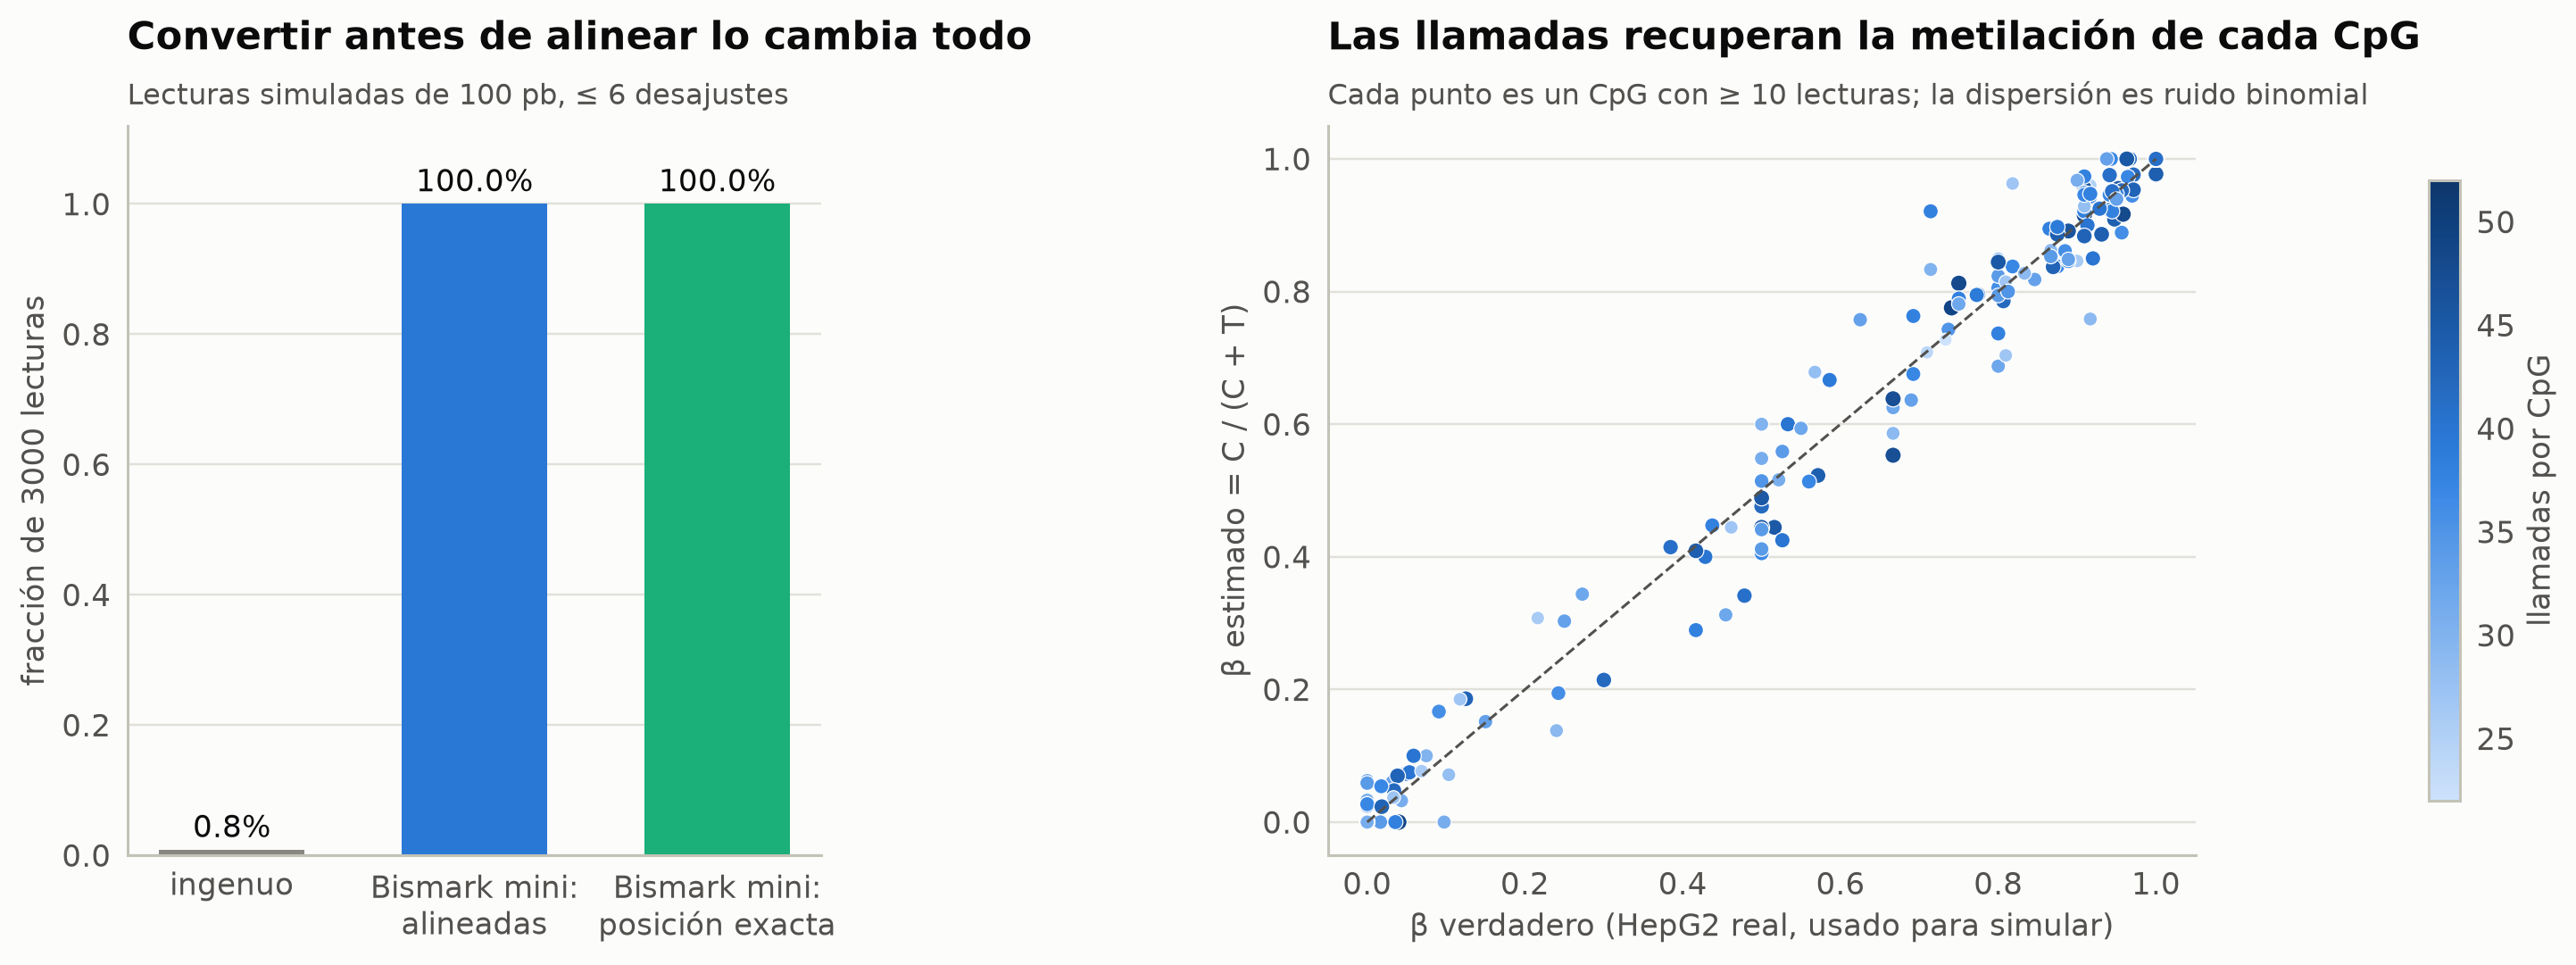

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1, 1.25], wspace=0.3))
ax = axes[0]
vals = [np.mean([h is not None for h in res_naive]), np.mean([h is not None for h in res_bis]), np.mean(ok_bis)]
labs = ["ingenuo", "Bismark mini:\nalineadas", "Bismark mini:\nposición exacta"]
bars = ax.bar(labs, vals, color=[ec.MUTED, ec.BLUE, ec.AQUA], width=0.6)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in vals], padding=2)
ax.set_ylim(0, 1.12); ax.set_ylabel("fracción de 3000 lecturas")
ec.title(ax, "Convertir antes de alinear lo cambia todo", "Lecturas simuladas de 100 pb, ≤ 6 desajustes")
ax = axes[1]
sc = ax.scatter(good.beta_true, good.beta_hat, s=12 + good["size"] / 2, c=good["size"], cmap=ec.CMAP_SEQ,
                edgecolor="white", lw=0.4)
ax.plot([0, 1], [0, 1], color=ec.INK_2, ls="--", lw=1)
ax.set_xlabel("β verdadero (HepG2 real, usado para simular)"); ax.set_ylabel("β estimado = C / (C + T)")
plt.colorbar(sc, ax=ax, label="llamadas por CpG", shrink=0.85)
ec.title(ax, "Las llamadas recuperan la metilación de cada CpG",
         "Cada punto es un CpG con ≥ 10 lecturas; la dispersión es ruido binomial")
plt.show()

> 🔎 **Qué observamos.** El alineador ingenuo prácticamente no encuentra nada (menos del 1 %: sólo lecturas casi sin C
> que convertir): sus semillas de 20 pb casi nunca sobreviven intactas a la conversión. El Bismark en miniatura alinea
> todas las lecturas en su sitio exacto; en un genoma completo, con sus repeticiones de tres letras, una parte se
> descartaría por ambigua. Las C en contexto CHH, que simulamos sin metilar, se leen como "metiladas" en ~0,6 % de los
> casos: el 0,5 % de no conversión más los errores de secuenciación que convierten una T en C (0,3 % × 1/3). Así se
> estima en la práctica la tasa de no conversión, con la advertencia de que incluye ese pequeño piso de errores. Y la metilación estimada sigue a la verdadera, con una dispersión
> que **disminuye al aumentar las lecturas** (puntos oscuros más cerca de la diagonal). Esa dispersión es el tema de la
> siguiente sección.

> ✅ **Compruebe su comprensión.** ¿Por qué el alineador de la hebra OB compara con el genoma **G→A** y no con el C→T?
> (Respuesta: una lectura OB es la hebra inferior convertida; su complemento inverso, escrito en coordenadas de la hebra
> superior, tiene A donde la hebra inferior tenía C no metiladas, es decir, frente a las G de la superior.)

<details><summary>⚙️ <b>Opcional (Colab): descargar otra región desde ENCODE</b></summary>

Los archivos *bedMethyl* de ENCODE también se publican como **bigBed**, un formato indexado que permite leer sólo una
región por HTTP. Cambie `FETCH_ENCODE = True` en la celda siguiente para descargar, por ejemplo, el promotor de *MGMT*
(chr10:129 465 000–129 469 500) de la réplica 1 de HepG2 con `pyBigWig`.
</details>

In [18]:
FETCH_ENCODE = False            # ← cambie a True en Colab para descargar una región nueva desde ENCODE
if FETCH_ENCODE:
    try:
        import pyBigWig
    except ImportError:
        %pip install -q pyBigWig
        import pyBigWig
    url = ("https://encode-public.s3.amazonaws.com/2021/07/17/5d534e41-6683-4fa6-90ae-8107f9e5555e/"
           "ENCFF067KKG.bigBed")                                   # HepG2, ENCSR881XOU, réplica 1
    bb = pyBigWig.open(url)
    ents = bb.entries("chr10", 129_465_000, 129_469_500)
    mgmt = pd.DataFrame([(s, *rest.split("\t")) for s, e, rest in ents]).iloc[:, [0, 3, 7, 8]]
    mgmt.columns = ["start", "strand", "cov", "pct"]
    print(mgmt.head(), f"\n{len(mgmt)} citosinas de CpG leídas")
else:
    print("Descarga desde ENCODE desactivada (FETCH_ENCODE = False); usamos la copia del curso.")

Descarga desde ENCODE desactivada (FETCH_ENCODE = False); usamos la copia del curso.


## 5. Cuantificar: valores β y M, cobertura e incertidumbre binomial

### Cada lectura es un voto

La medida del bisulfito es **digital en cada molécula**: cada lectura dice "C" o "T" en cada citosina de la referencia.
El nivel de metilación de un CpG es la **fracción de moléculas** que dicen "C". Si un CpG está cubierto por $n$
lecturas, de las cuales $c$ dicen "C", el modelo natural es el de lanzar $n$ monedas cargadas:

$$
c \sim \mathrm{Bin}(n, \beta), \qquad \hat\beta = \frac{c}{n}, \qquad \mathrm{EE}(\hat\beta) = \sqrt{\frac{\hat\beta(1-\hat\beta)}{n}}
$$

| Símbolo | Significado |
|---|---|
| $n$ | cobertura: lecturas que cubren el CpG |
| $c$ | lecturas que dicen "C" (metiladas) |
| $\beta$ | fracción de moléculas metiladas en la muestra (lo que queremos saber) |
| $\hat\beta = c/n$ | estimador de máxima verosimilitud |
| EE | error estándar binomial de $\hat\beta$ |

Ojo con la interpretación: $\beta = 0{,}5$ significa que **la mitad de las moléculas** está metilada en ese CpG (por
ejemplo, un alelo sí y otro no, como en la impronta), no que cada molécula esté "medio metilada".

### Ejemplo resuelto del libro (primera parte): 17 de 20 lecturas dicen "C"

* $\hat\beta = 17/20 = 0{,}850$, con $\mathrm{EE} = \sqrt{0{,}85 \times 0{,}15 / 20} = \sqrt{0{,}006375} = 0{,}080$.
* Intervalo de Wald al 95 %: $0{,}850 \pm 1{,}96 \times 0{,}080 = (0{,}694;\ 1{,}006)$. **¡Se sale de $[0, 1]$!** Una
  fracción de moléculas no puede superar 1.
* Con proporciones cercanas a los extremos conviene un intervalo **bayesiano de Jeffreys**: con la distribución a priori
  $\mathrm{Beta}(\tfrac12, \tfrac12)$, la posterior es $\mathrm{Beta}(c + \tfrac12,\ n - c + \tfrac12) =
  \mathrm{Beta}(17{,}5;\ 3{,}5)$ y sus cuantiles 2,5 % y 97,5 % dan $(0{,}651;\ 0{,}956)$: asimétrico, como debe ser
  cerca de 1.
* El valor $M$ (que definimos enseguida), con $\alpha' = 1$: $\log_2\frac{17 + 1}{3 + 1} = \log_2 4{,}5 = 2{,}17$.

In [19]:
c_ex, n_ex = 17, 20
beta_hat = c_ex / n_ex
se = math.sqrt(beta_hat * (1 - beta_hat) / n_ex)
wald_ci = (beta_hat - 1.96 * se, beta_hat + 1.96 * se)
jeff_ci = stats.beta.ppf([0.025, 0.975], c_ex + 0.5, n_ex - c_ex + 0.5)
M_ex = math.log2((c_ex + 1) / (n_ex - c_ex + 1))
print(f"β̂ = {beta_hat:.3f} · EE = {se:.4f}")
print(f"IC 95 % de Wald     = ({wald_ci[0]:.3f}; {wald_ci[1]:.3f})")
print(f"IC 95 % de Jeffreys = ({jeff_ci[0]:.3f}; {jeff_ci[1]:.3f})")
print(f"M (α' = 1) = log2(18/4) = {M_ex:.3f}   ·   sin constante: log2(17/3) = {math.log2(17 / 3):.3f}")
assert abs(se - 0.0798) < 1e-4 and abs(jeff_ci[0] - 0.651) < 1e-3 and abs(jeff_ci[1] - 0.956) < 1e-3 and abs(M_ex - 2.170) < 1e-3

β̂ = 0.850 · EE = 0.0798
IC 95 % de Wald     = (0.694; 1.006)
IC 95 % de Jeffreys = (0.651; 0.956)
M (α' = 1) = log2(18/4) = 2.170   ·   sin constante: log2(17/3) = 2.503


¿Es sólo una cuestión estética que el intervalo de Wald se salga de $[0,1]$? No: el problema de fondo es que **no cubre
lo que promete**. Podemos medir su **cobertura real**: para un $\beta$ verdadero y una cobertura $n$, sumamos la
probabilidad binomial de todos los $c$ cuyo intervalo contiene a $\beta$ (Brown, Cai y DasGupta, 2001, lo estudiaron a
fondo). Es un cálculo exacto, sin simulación.

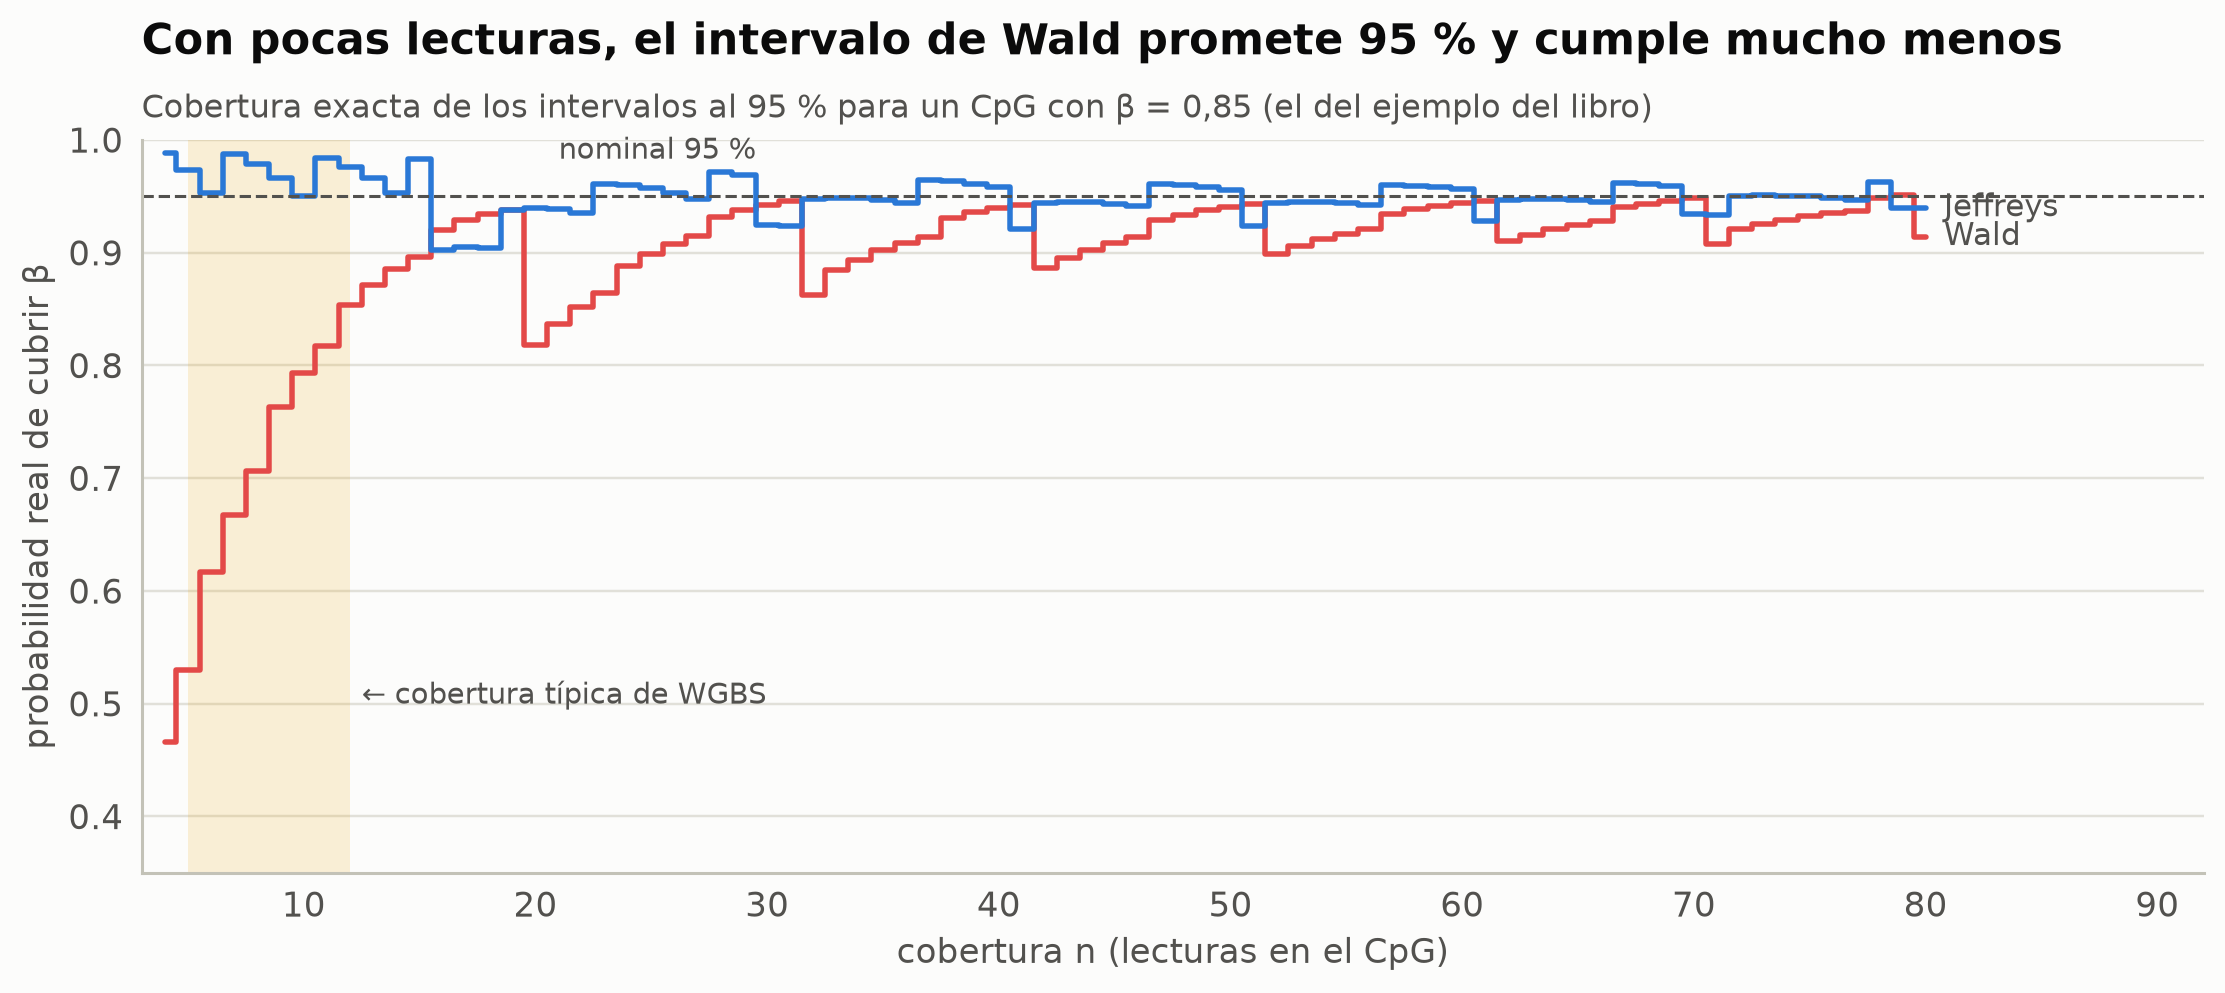

In [20]:
def coverage(beta, n, kind):
    c = np.arange(n + 1)
    b = c / n
    if kind == "Wald":
        half = 1.96 * np.sqrt(b * (1 - b) / n)
        lo, hi = b - half, b + half
    else:
        lo = np.where(c == 0, 0, stats.beta.ppf(0.025, c + 0.5, n - c + 0.5))
        hi = np.where(c == n, 1, stats.beta.ppf(0.975, c + 0.5, n - c + 0.5))
    return stats.binom.pmf(c, n, beta)[(lo <= beta) & (beta <= hi)].sum()

ns = np.arange(4, 81)
fig, ax = plt.subplots(figsize=(10, 4.4))
for kind, col in [("Wald", ec.RED), ("Jeffreys", ec.BLUE)]:
    cov_ = [coverage(0.85, n, kind) for n in ns]
    ax.plot(ns, cov_, color=col, lw=1.8, drawstyle="steps-mid")
    ec.label_end(ax, ns[-1], cov_[-1], kind)
ax.axhline(0.95, color=ec.INK_2, ls="--", lw=1); ax.text(21, 0.99, "nominal 95 %", color=ec.INK_2, fontsize=9.5, va="center")
ax.axvspan(5, 12, color=ec.YELLOW, alpha=0.15, lw=0); ax.text(12.5, 0.5, "← cobertura típica de WGBS", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(3, 92); ax.set_ylim(0.35, 1.0)
ax.set_xlabel("cobertura n (lecturas en el CpG)"); ax.set_ylabel("probabilidad real de cubrir β")
ec.title(ax, "Con pocas lecturas, el intervalo de Wald promete 95 % y cumple mucho menos",
         "Cobertura exacta de los intervalos al 95 % para un CpG con β = 0,85 (el del ejemplo del libro)")
plt.show()

> 🔎 **Qué observamos.** Con 5–12 lecturas, lo habitual en WGBS, el intervalo de Wald cubre el valor verdadero a
> veces menos del 60 % y como mucho el ~85 % de las veces, y oscila de forma errática con $n$. El de Jeffreys se mantiene cerca del 95 %. Lección
> práctica: para informar la metilación de un CpG poco cubierto, use Jeffreys (o Wilson), nunca el $\pm 1{,}96\,$EE.

### Micromatrices y la definición de β y M

Las micromatrices de Illumina (Infinium 450K y EPIC), todavía muy usadas en estudios poblacionales y en los relojes
epigenéticos, miden lo mismo de otra forma: para cada CpG hay dos intensidades de fluorescencia, $M_s$ para el alelo
metilado y $U_s$ para el no metilado (tras la conversión, la sonda distingue C de T). Du *et al.* (2010) compararon las
dos métricas en uso:

$$
\beta = \frac{\max(M_s,0)}{\max(M_s,0)+\max(U_s,0)+\alpha},\qquad
M = \log_2\frac{\max(M_s,0)+\alpha'}{\max(U_s,0)+\alpha'} \;\approx\; \log_2\frac{\beta}{1-\beta}
$$

| Símbolo | Significado |
|---|---|
| $M_s,\ U_s$ | intensidades de las sondas metilada y no metilada del CpG $s$ (en WGBS, los conteos $c$ y $n - c$) |
| $\alpha$ | constante que estabiliza $\beta$ cuando ambas intensidades son bajas (Illumina usa 100) |
| $\alpha'$ | pequeña constante que evita el logaritmo de cero (p. ej., 1) |
| $\beta \in [0,1]$ | fracción de metilación; interpretable como porcentaje de moléculas metiladas |
| $M \in \mathbb{R}$ | valor $M$; $M = 0$ corresponde a $\beta = 0{,}5$ |

Ignorando las constantes, **el valor $M$ es la transformación logit (en base 2) del valor $\beta$**. Reproducimos la
simulación del libro: 400 000 CpG con intensidades de tipo Infinium (semilla 106; un tercio de los sitios de islas casi
sin metilar, un 10 % intermedios y el resto del "mar" metilado).

In [21]:
# Código del libro (figuras/cap13/generar.py, bloque 13.2-a), mismo orden de sorteos
rng106 = np.random.default_rng(106)
ncg = 400_000
grupo = rng106.random(ncg)
beta_sim = np.where(grupo < 0.33, rng106.beta(0.9, 14, ncg),
                    np.where(grupo < 0.43, rng106.beta(3, 3, ncg), rng106.beta(14, 2.2, ncg)))
Mi = rng106.gamma(20, 250, ncg)                   # intensidad total
Meth, Unm = beta_sim * Mi, (1 - beta_sim) * Mi
b_obs = Meth / (Meth + Unm + 100)                 # α = 100
m_obs = np.log2((Meth + 1) / (Unm + 1))           # α' = 1
print(f"fracción β < 0,2: {(b_obs < 0.2).mean():.3f} · β > 0,8: {(b_obs > 0.8).mean():.3f}")
assert abs((b_obs < 0.2).mean() - 0.325) < 6e-4 and abs((b_obs > 0.8).mean() - 0.431) < 6e-4

# heterocedasticidad: repeticiones técnicas de un mismo CpG con β fijo (continúa el mismo generador)
hetero = []
for b in [0.05, 0.5, 0.95]:
    tot = rng106.gamma(20, 250, 2000)
    me = rng106.poisson(b * tot); un = rng106.poisson((1 - b) * tot)
    hetero.append((b, (me / (me + un + 100)).std(), np.log2((me + 1) / (un + 1)).std()))
hetero = pd.DataFrame(hetero, columns=["β verdadero", "de(β)", "de(M)"])
print(hetero.round(4).to_string(index=False))

fracción β < 0,2: 0.325 · β > 0,8: 0.431
 β verdadero  de(β)  de(M)
        0.05 0.0030 0.0927
        0.50 0.0075 0.0426
        0.95 0.0055 0.0948


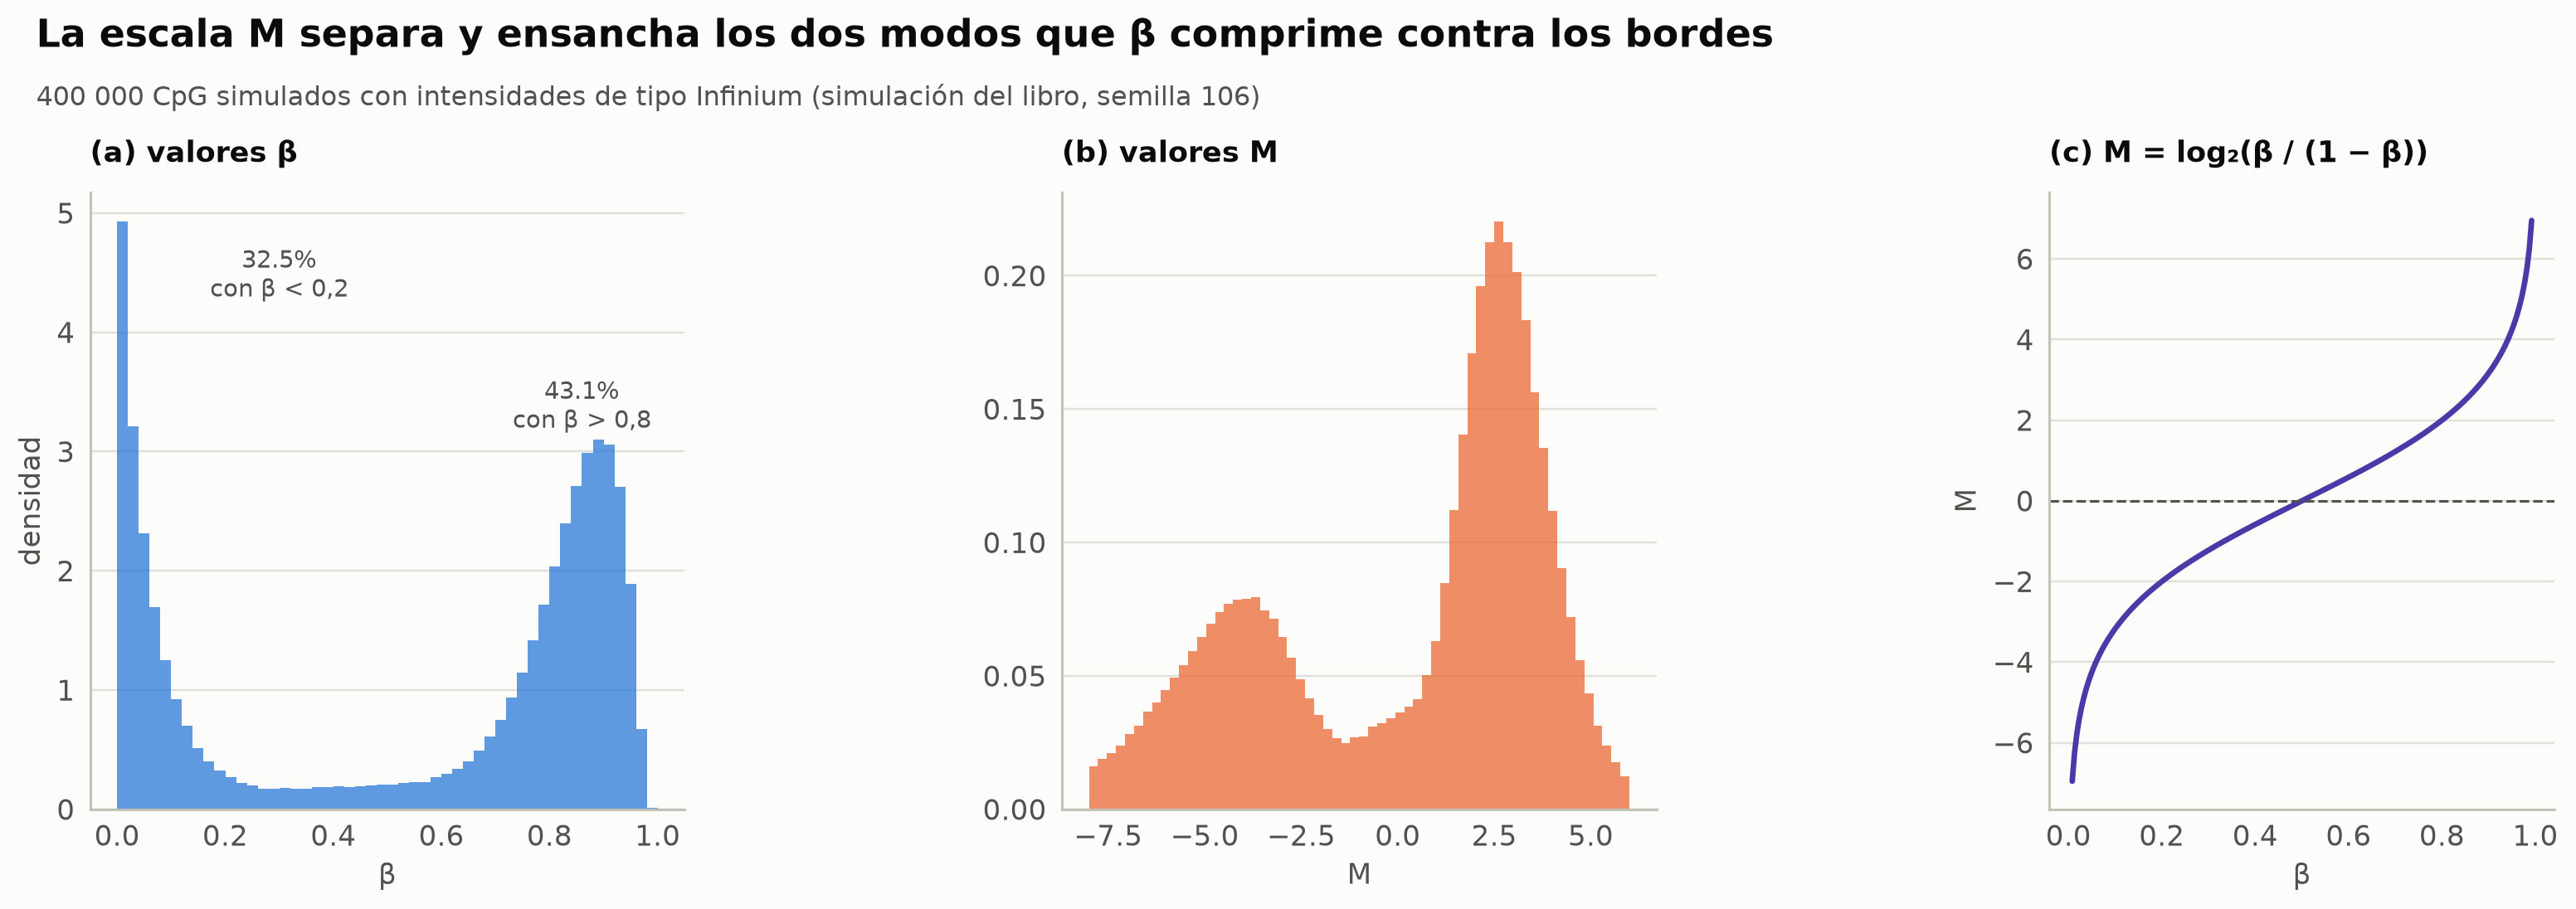

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw=dict(width_ratios=[1, 1, 0.85], wspace=0.35))
axes[0].hist(b_obs, bins=50, range=(0, 1), density=True, color=ec.BLUE, alpha=0.75)
axes[0].set_xlabel("β"); axes[0].set_ylabel("densidad"); axes[0].set_title("(a) valores β", loc="left", fontsize=11.5)
axes[0].text(0.3, 4.3, f"{(b_obs < 0.2).mean():.1%}\ncon β < 0,2", ha="center", fontsize=9.5, color=ec.INK_2)
axes[0].text(0.86, 3.2, f"{(b_obs > 0.8).mean():.1%}\ncon β > 0,8", ha="center", fontsize=9.5, color=ec.INK_2)
axes[1].hist(m_obs, bins=60, range=(-8, 6), density=True, color=ec.ORANGE, alpha=0.75)
axes[1].set_xlabel("M"); axes[1].set_title("(b) valores M", loc="left", fontsize=11.5)
bb = np.linspace(0.008, 0.992, 200)
axes[2].plot(bb, np.log2(bb / (1 - bb)), color=ec.VIOLET, lw=2.2); axes[2].axhline(0, color=ec.INK_2, ls="--", lw=1)
axes[2].set_xlabel("β"); axes[2].set_ylabel("M"); axes[2].set_title("(c) M = log₂(β / (1 − β))", loc="left", fontsize=11.5)
ec.fig_title(fig, "La escala M separa y ensancha los dos modos que β comprime contra los bordes",
             "400 000 CpG simulados con intensidades de tipo Infinium (simulación del libro, semilla 106)")
plt.show()

### ¿Por qué dos métricas? El método delta

$\beta$ tiene interpretación biológica directa, pero **su varianza depende de su media**: cerca de 0 y de 1 está
comprimida por los límites del intervalo. Si $\operatorname{Var}(\hat\beta)\approx\beta(1-\beta)/n$ (binomial), el
método delta (una aproximación de Taylor de primer orden) da:

$$
\operatorname{Var}(\hat M) \approx \left(\frac{dM}{d\beta}\right)^{2}\operatorname{Var}(\hat\beta)
= \frac{1}{\bigl(\beta(1-\beta)\ln2\bigr)^2}\cdot\frac{\beta(1-\beta)}{n}
= \frac{1}{n\,\beta(1-\beta)\,(\ln 2)^2}
$$

| Símbolo | Significado |
|---|---|
| $dM/d\beta$ | derivada de la transformación logit en base 2, $1/(\beta(1-\beta)\ln 2)$ |
| $n$ | número de moléculas (lecturas) que sustentan la medida |

La varianza de $\hat\beta$ es **máxima** en $\beta = 0{,}5$; la de $\hat M$ es **mínima** allí. En escala $M$ una misma
diferencia de 0,05 no vale lo mismo en torno a $\beta = 0{,}5$ que en torno a $\beta = 0{,}97$, donde es mucho más
significativa biológica y estadísticamente. Du *et al.* (2010) concluyeron que $\beta$ es preferible para **informar**
resultados y $M$ para el **análisis diferencial** en micromatrices. En WGBS, donde los datos son conteos, lo más limpio es
modelar directamente la binomial, como haremos en la sección 6.

> 🤔 **Antes de ejecutar, prediga:** en la tabla de repeticiones técnicas de arriba, ¿en qué $\beta$ es mayor la
> desviación estándar de $\hat\beta$? ¿Y la de $\hat M$?

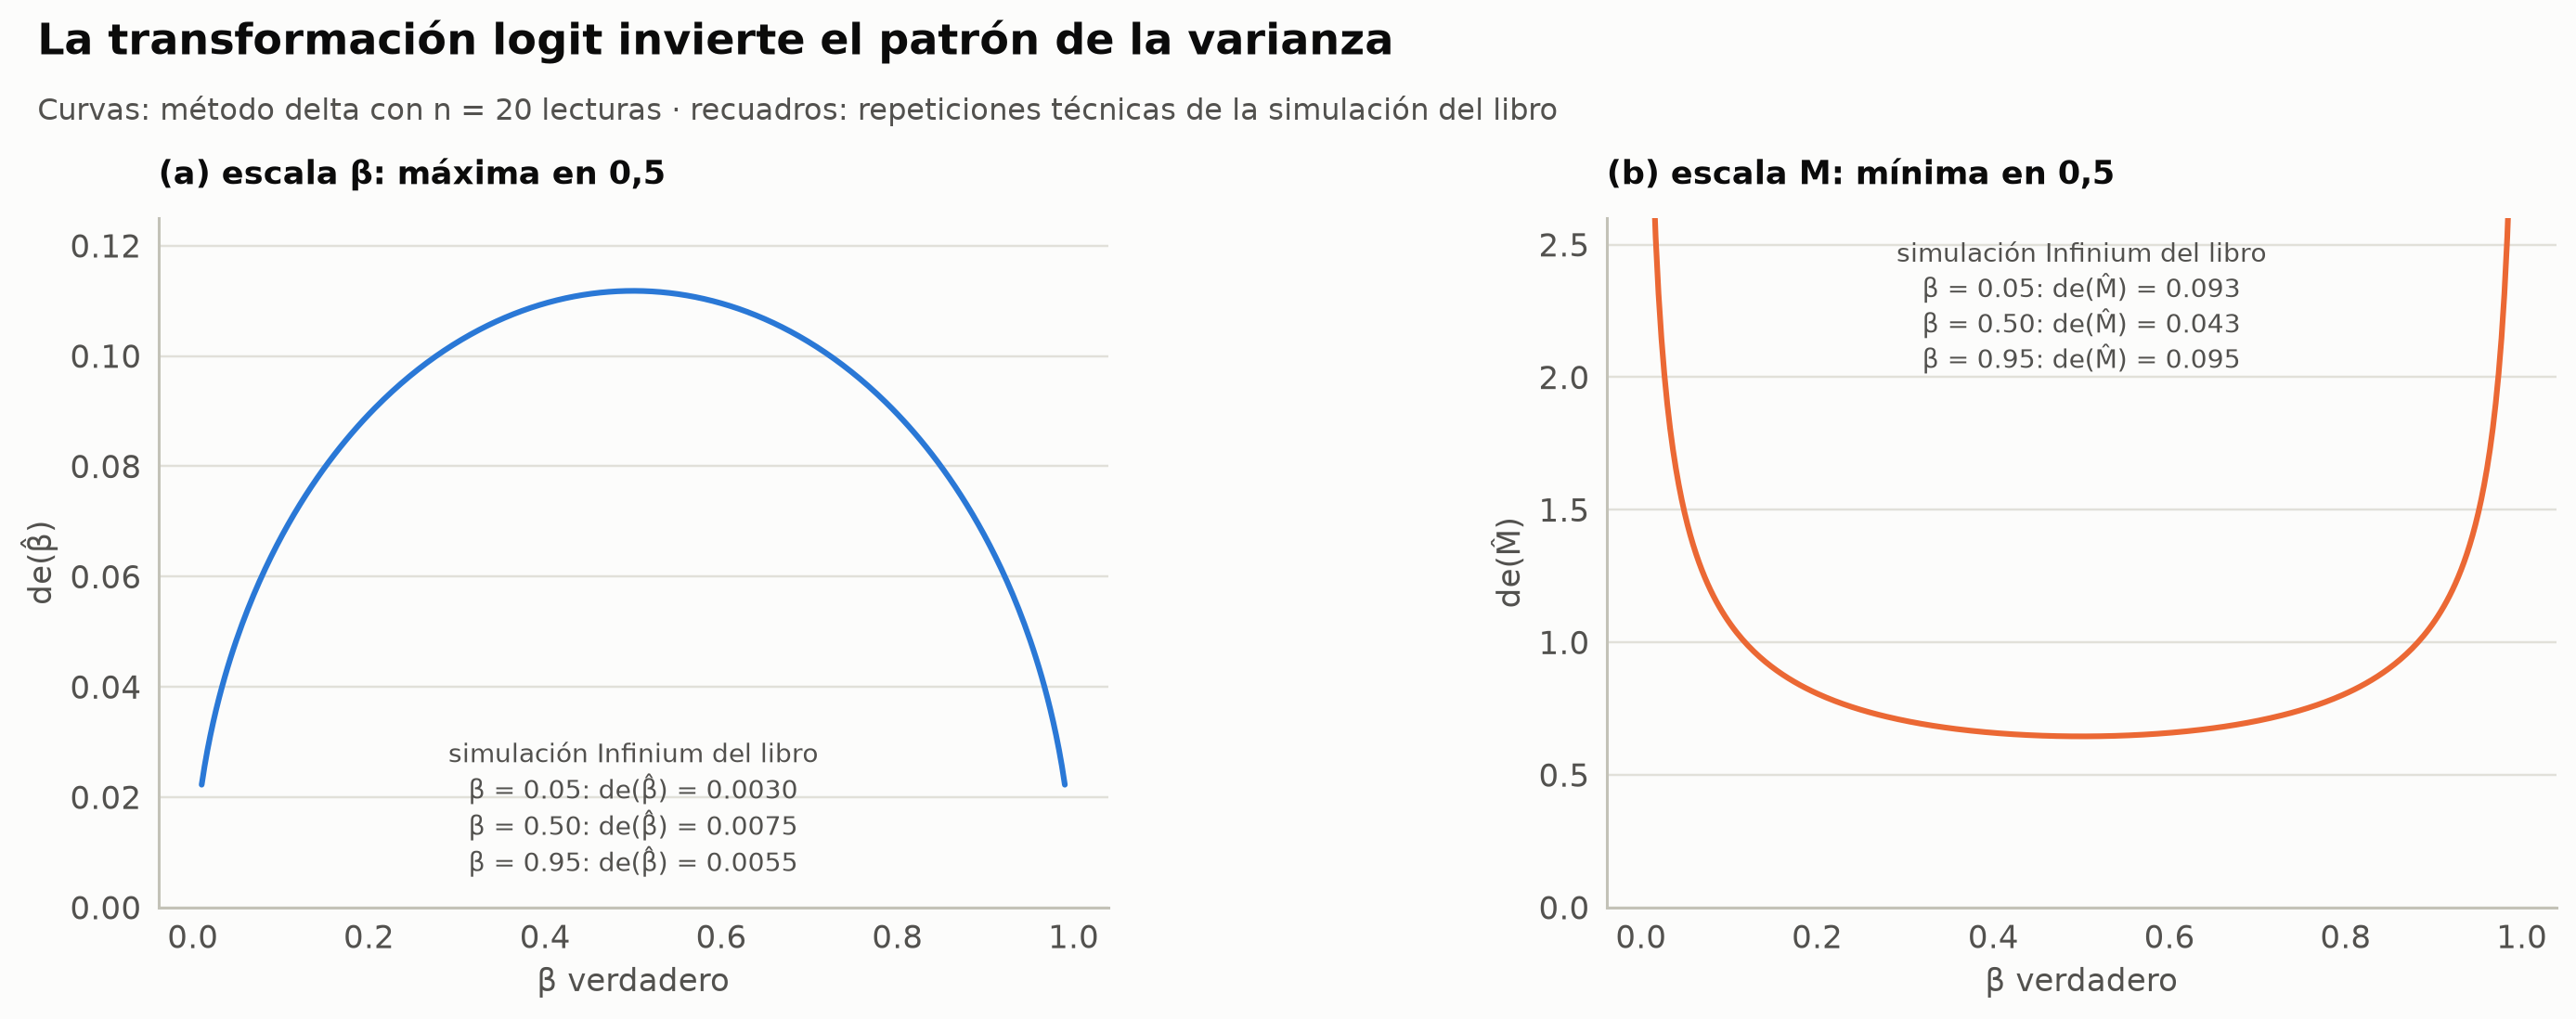

In [23]:
bgrid = np.linspace(0.01, 0.99, 300); n_eff = 20
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw=dict(wspace=0.3))
axes[0].plot(bgrid, np.sqrt(bgrid * (1 - bgrid) / n_eff), color=ec.BLUE, lw=2)
axes[0].set_ylabel("de(β̂)"); axes[0].set_title("(a) escala β: máxima en 0,5", loc="left", fontsize=11.5)
axes[1].plot(bgrid, 1 / np.sqrt(n_eff * bgrid * (1 - bgrid)) / np.log(2), color=ec.ORANGE, lw=2)
axes[1].set_ylabel("de(M̂)"); axes[1].set_ylim(0, 2.6); axes[1].set_title("(b) escala M: mínima en 0,5", loc="left", fontsize=11.5)
for ax in axes:
    ax.set_xlabel("β verdadero")
# repeticiones técnicas de la simulación del libro (intensidades de miles: otra escala de n)
txt_b = "simulación Infinium del libro\n" + "\n".join(f"β = {r['β verdadero']:.2f}: de(β̂) = {r['de(β)']:.4f}" for _, r in hetero.iterrows())
txt_m = "simulación Infinium del libro\n" + "\n".join(f"β = {r['β verdadero']:.2f}: de(M̂) = {r['de(M)']:.3f}" for _, r in hetero.iterrows())
axes[0].text(0.5, 0.04, txt_b, transform=axes[0].transAxes, ha="center", va="bottom", fontsize=9, color=ec.INK_2)
axes[1].text(0.5, 0.97, txt_m, transform=axes[1].transAxes, ha="center", va="top", fontsize=9, color=ec.INK_2)
axes[0].set_ylim(0, 0.125)
ec.fig_title(fig, "La transformación logit invierte el patrón de la varianza",
             "Curvas: método delta con n = 20 lecturas · recuadros: repeticiones técnicas de la simulación del libro")
plt.show()

> 🔎 **Qué observamos.** Las dos curvas son espejos: la desviación de $\hat\beta$ es máxima en el centro y se aplasta en
> los bordes; la de $\hat M$ hace lo contrario. Las repeticiones técnicas de la simulación del libro (con intensidades
> de miles de unidades, por eso sus valores son mucho menores) siguen el mismo patrón: de($\hat\beta$) = 0,0030; 0,0075;
> 0,0055 frente a de($\hat M$) = 0,093; 0,043; 0,095.

### 🧪 Datos reales: cada CpG de *GSTP1* con su incertidumbre

Volvamos a ENCODE. En la figura interactiva, cada punto es un CpG de una muestra; pase el ratón para ver los conteos
$c/n$ y el intervalo de Jeffreys. Compare el ancho de los intervalos de `liver_OMA` (~38 lecturas) con los de
`liver_LXB` o `HepG2_a2` (~5 lecturas).

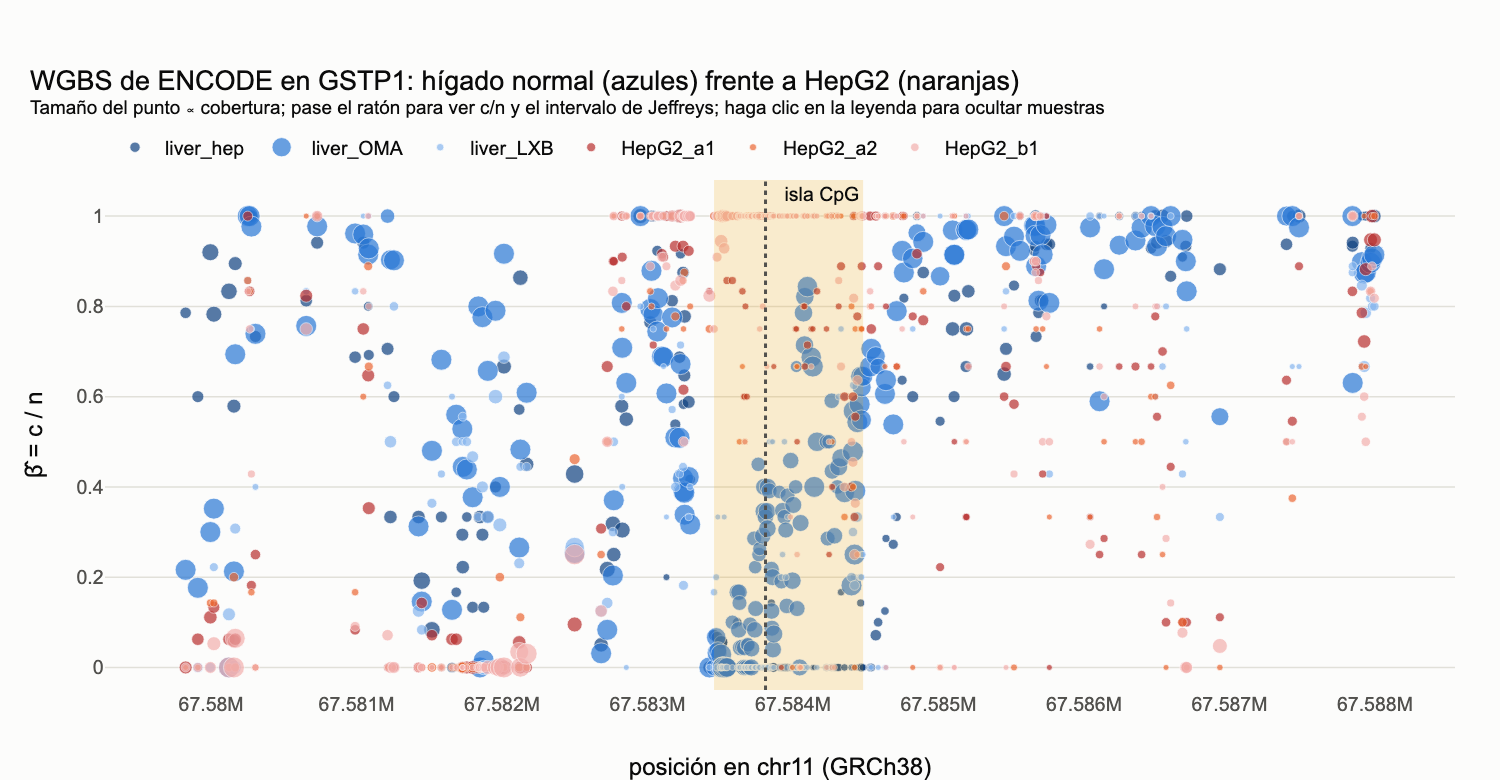

In [24]:
long = (C_raw.stack().rename("c").to_frame().join(N_raw.stack().rename("n")).reset_index()
        .rename(columns={"level_1": "sample"}))
long = long[long.n > 0].copy()
long["beta"] = long.c / long.n
long["lo"] = np.where(long.c == 0, 0, stats.beta.ppf(0.025, long.c + 0.5, long.n - long.c + 0.5))
long["hi"] = np.where(long.c == long.n, 1, stats.beta.ppf(0.975, long.c + 0.5, long.n - long.c + 0.5))

figl = go.Figure()
figl.add_vrect(x0=ISL_S, x1=ISL_E, fillcolor=ec.YELLOW, opacity=0.18, line_width=0,
               annotation_text="isla CpG", annotation_position="top right")
palette = {s: c for s, c in zip(A_S + B_S, ["#104281", ec.BLUE, "#86b6ef", "#b8302f", ec.ORANGE, "#f3b0ae"])}
for s in A_S + B_S:
    d = long[long["sample"] == s]
    grp_name = "hígado normal" if s in A_S else "HepG2"
    figl.add_trace(go.Scatter(
        x=d.cpg, y=d.beta, mode="markers", name=s, marker=dict(size=np.clip(3 + d.n / 3, 4, 14), color=palette[s],
                                                                 line=dict(width=0.5, color="white")),
        customdata=np.c_[d.c, d.n, d.lo, d.hi],
        hovertemplate=(f"<b>{s}</b> ({grp_name})<br>CpG en %{{x:,}}<br>c/n = %{{customdata[0]}}/%{{customdata[1]}} "
                       "→ β̂ = %{y:.2f}<br>IC 95 % Jeffreys: %{customdata[2]:.2f}–%{customdata[3]:.2f}<extra></extra>")))
figl.add_vline(x=TSS, line_dash="dot", line_color=ec.INK_2)
figl.update_layout(height=520, margin=dict(t=120, l=70, r=30, b=60), xaxis_title=f"posición en {REG_CHROM} (GRCh38)",
                   yaxis_title="β̂ = c / n", yaxis_range=[-0.05, 1.08],
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.0),
                   title="WGBS de ENCODE en GSTP1: hígado normal (azules) frente a HepG2 (naranjas)"
                         "<br><sup>Tamaño del punto ∝ cobertura; pase el ratón para ver c/n y el intervalo de Jeffreys; "
                         "haga clic en la leyenda para ocultar muestras</sup>")
figl.show()

> 🔎 **Qué observamos.** Dentro de la isla (banda amarilla) los puntos naranjas de HepG2 se agolpan cerca de 1 y, en el
> núcleo 5′ del promotor (cerca del TSS), los azules del hígado normal quedan cerca de 0: el promotor de *GSTP1* está **hipermetilado en la línea tumoral**. Fuera de la
> isla las dos nubes se mezclan (el "mar" está metilado en todas las células). Los puntos individuales son ruidosos: con
> 5 lecturas, $\hat\beta$ sólo puede valer 0; 0,2; 0,4…; su intervalo de Jeffreys abarca casi medio intervalo $[0,1]$.

> ✅ **Compruebe su comprensión.** Un CpG de `liver_LXB` tiene $c/n = 0/4$. ¿Cuál es su intervalo de Jeffreys? ¿Podemos
> afirmar que está "sin metilar"? (Respuesta: $\mathrm{Beta}(0{,}5;\ 4{,}5)$ da aproximadamente $(0;\ 0{,}44)$: es
> compatible con que hasta el 44 % de las moléculas estén metiladas. Una sola muestra y un solo CpG dicen poco; hacen
> falta réplicas y regiones.)

### β ≈ 0,5 real: la impronta de *SNRPN*

El caso clínico del principio decía que en *SNRPN* una copia del gen está metilada (la materna) y la otra no. Si es así,
en un tejido normal esperamos $\beta \approx 0{,}5$ en toda la isla del promotor: la mitad de las **moléculas** (las de
un alelo) dicen "C". En el síndrome de Prader-Willi (sólo hay copias maternas) esperaríamos $\beta \approx 1$; en el de
Angelman por deleción o disomía paterna, $\beta \approx 0$. Veamos las tres muestras de hígado normal.

In [25]:
snrpn = pd.read_csv(io.BytesIO(course_bytes("132_snrpn_wgbs_encode.tsv.gz")), sep="\t", compression="gzip")
snrpn_cgi = json.loads(course_bytes("api_cache/ucsc_cpgIslandExt_hg38_chr15_24953800_24956300.json",
                                    "https://api.genome.ucsc.edu/getData/track?genome=hg38;chrom=chr15;"
                                    "start=24953800;end=24956300;track=cpgIslandExt"))["cpgIslandExt"][0]
snrpn["cpg"] = np.where(snrpn.strand == "+", snrpn.start, snrpn.start - 1)
in_isl = snrpn[(snrpn.cpg >= snrpn_cgi["chromStart"]) & (snrpn.cpg < snrpn_cgi["chromEnd"])]
imp = in_isl.groupby("sample")[["meth", "cov"]].sum().loc[A_S + B_S]
imp["β isla"] = imp.meth / imp["cov"]
imp["IC95 Jeffreys"] = [f"{stats.beta.ppf(0.025, c + .5, n - c + .5):.3f}–{stats.beta.ppf(0.975, c + .5, n - c + .5):.3f}"
                        for c, n in zip(imp.meth, imp["cov"])]
print(f"Isla de SNRPN: chr15:{snrpn_cgi['chromStart']:,}-{snrpn_cgi['chromEnd']:,} "
      f"({in_isl.cpg.nunique()} CpG con datos)")
print(imp.round(3).to_string())

Isla de SNRPN: chr15:24,954,888-24,955,907 (77 CpG con datos)
           meth   cov  β isla IC95 Jeffreys
sample                                     
liver_hep   369   774   0.477   0.442–0.512
liver_OMA  1265  2501   0.506   0.486–0.525
liver_LXB   163   372   0.438   0.388–0.489
HepG2_a1    198   624   0.317   0.282–0.355
HepG2_a2     51   266   0.192   0.148–0.242
HepG2_b1    244   476   0.513   0.468–0.557


> 🔎 **Qué observamos.** Las tres muestras de hígado normal dan $\beta$ entre ~0,44 y ~0,51 al sumar todos los CpG de
> la isla, y como sumamos cientos de lecturas el intervalo es estrecho: distinguir 0,5 de 1 (Prader-Willi) o de 0
> (Angelman) es trivial a nivel de **región**, aunque cada CpG por separado tenga 5–10 lecturas. HepG2, una línea
> tumoral cultivada durante décadas, se aparta de 0,5 en dos de sus tres réplicas (0,19 y 0,32), pero la tercera, de otro experimento, da 0,51. La impronta
> podría estar alterada en esta línea tumoral, pero con estos datos no es concluyente: haría falta más de un cultivo y,
> sobre todo, tumores de pacientes.

## 6. Metilación diferencial: el modelo beta-binomial

### Dos fuentes de variación

Al comparar dos grupos (tumor y tejido normal, tratados y controles) buscamos CpG individuales (**DML**,
*differentially methylated loci*) o regiones (**DMR**) cuyo nivel de metilación difiera. El modelo binomial captura el
**muestreo de lecturas** (cuántas de las $n$ moléculas secuenciadas resultaron metiladas), pero no la variación
**biológica** entre réplicas: dos individuos sanos no tienen exactamente la misma $\beta$ en un CpG. Ignorar esa
variabilidad **subestima la varianza** y produce avalanchas de falsos positivos: es exactamente el mismo fenómeno de
sobredispersión que en RNA-seq obliga a pasar de la Poisson a la binomial negativa (Lección 11.2).

El modelo jerárquico tiene dos pisos: primero cada réplica $r$ "elige" su propia fracción de metilación $p_r$ de una
distribución beta; después sus $n_r$ lecturas se sortean con esa fracción.

$$
p_r\sim\mathrm{Beta}(a,b),\quad \mu=\frac{a}{a+b},\quad \phi=\frac{1}{a+b+1};\qquad c_r\mid p_r\sim\mathrm{Bin}(n_r,p_r)
$$

$$
\boxed{\;\mathbb{E}[c_r]=n_r\,\mu,\qquad \operatorname{Var}(c_r) = n_r\,\mu(1-\mu)\,\bigl[1+(n_r-1)\,\phi\bigr]\;}
$$

| Símbolo | Significado |
|---|---|
| $c_r,\ n_r$ | lecturas metiladas y cobertura total del CpG en la réplica $r$ |
| $p_r$ | fracción de metilación verdadera de la réplica (varía entre individuos) |
| $\mu$ | media de metilación del grupo en ese CpG |
| $\phi \in [0,1)$ | dispersión: correlación entre dos lecturas de la misma réplica; $\phi = 0$ recupera la binomial |

**Demostración** (ley de la varianza total): $\operatorname{Var}(c)=\mathbb{E}[\operatorname{Var}(c\mid p)]+
\operatorname{Var}(\mathbb{E}[c\mid p]) = n\,\mathbb{E}[p(1-p)] + n^2\operatorname{Var}(p)$. Con
$\mathbb{E}[p(1-p)] = \mu(1-\mu)-\operatorname{Var}(p)$ y $\operatorname{Var}(p)=\mu(1-\mu)\phi$ para la beta, queda
$n\mu(1-\mu)(1-\phi)+n^2\mu(1-\mu)\phi = n\mu(1-\mu)[1+(n-1)\phi]$. ∎

El factor $1+(n-1)\phi$ tiene una lectura importante: **aumentar la cobertura no elimina la variación biológica**. Con
$n=20$ y $\mu=0{,}85$, la desviación estándar de $c$ es $\sqrt{20\times0{,}85\times0{,}15}=1{,}60$ si $\phi=0$, pero
$\sqrt{2{,}55\times1{,}95}=2{,}23$ con $\phi=0{,}05$ y $\sqrt{2{,}55\times2{,}9}=2{,}72$ con $\phi=0{,}1$.

In [26]:
def betabin_var(n, mu, phi):
    return n * mu * (1 - mu) * (1 + (n - 1) * phi)

for phi in [0.0, 0.05, 0.1]:
    v = betabin_var(20, 0.85, phi)
    print(f"n = 20, μ = 0,85, φ = {phi:<4}: Var(c) = {v:.3f} · de(c) = {math.sqrt(v):.3f}")
assert [round(math.sqrt(betabin_var(20, 0.85, p)), 3) for p in (0, 0.05, 0.1)] == [1.597, 2.230, 2.719]

# Comprobación por simulación del modelo jerárquico (φ = 0,05)
mu_, phi_ = 0.85, 0.05
a_, b_ = mu_ * (1 - phi_) / phi_, (1 - mu_) * (1 - phi_) / phi_
c_sim = rng.binomial(20, rng.beta(a_, b_, 200_000))
print(f"Simulación: de(c) = {c_sim.std():.3f}  (teoría 2,230)")

n = 20, μ = 0,85, φ = 0.0 : Var(c) = 2.550 · de(c) = 1.597
n = 20, μ = 0,85, φ = 0.05: Var(c) = 4.973 · de(c) = 2.230
n = 20, μ = 0,85, φ = 0.1 : Var(c) = 7.395 · de(c) = 2.719
Simulación: de(c) = 2.227  (teoría 2,230)


### 🎬 Animación: más lecturas no borran la variación entre individuos

Si la varianza de $\hat\beta = c/n$ es $\mu(1-\mu)[1+(n-1)\phi]/n$, cuando $n \to \infty$ tiende a $\mu(1-\mu)\phi$, un
**piso** que no depende de la profundidad de secuenciación. La animación aumenta la cobertura de 5 a 500 lecturas y
compara 20 000 réplicas simuladas con $\phi = 0$ (binomial pura) y $\phi = 0{,}05$.

![Al aumentar la cobertura, la dispersión binomial se encoge sin límite; la beta-binomial se detiene en un piso](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-13-epigenomica/13.2_cobertura_dispersion.gif)

*Al aumentar la cobertura, la dispersión binomial se encoge sin límite; la beta-binomial se detiene en un piso*

In [27]:
n_frames = np.unique(np.round(np.geomspace(5, 500, 44)).astype(int))
mu_, phi_ = 0.85, 0.05
p_rep = rng.beta(mu_ * (1 - phi_) / phi_, (1 - mu_) * (1 - phi_) / phi_, 20_000)     # β de cada individuo
sd_bin = lambda n: np.sqrt(mu_ * (1 - mu_) / n)
sd_bb = lambda n: np.sqrt(mu_ * (1 - mu_) * (1 + (n - 1) * phi_) / n)
floor = np.sqrt(mu_ * (1 - mu_) * phi_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1.1, 1]), layout="none")
bins = np.linspace(0.3, 1.0, 57)
ngrid = np.geomspace(5, 500, 200)
ax2.plot(ngrid, sd_bin(ngrid), color=ec.BLUE, lw=2); ax2.plot(ngrid, sd_bb(ngrid), color=ec.ORANGE, lw=2)
ax2.axhline(floor, color=ec.ORANGE, ls="--", lw=1)
ax2.text(6, floor * 1.08, f"piso √(μ(1−μ)φ) = {floor:.3f}", color=ec.ORANGE, fontsize=9.5)
ax2.text(60, sd_bin(60) * 0.75, "φ = 0 (binomial)", color=ec.BLUE, fontsize=10, ha="right")
ax2.text(300, sd_bb(300) * 1.12, "φ = 0,05", color=ec.ORANGE, fontsize=10, ha="center")
ax2.set_xscale("log"); ax2.set_yscale("log"); ax2.set_xlabel("cobertura n"); ax2.set_ylabel("de(β̂)")
ax2.set_yticks([0.02, 0.05, 0.1, 0.15], ["0,02", "0,05", "0,10", "0,15"]); ax2.minorticks_off()
ax2.set_xticks([5, 10, 50, 100, 500], ["5", "10", "50", "100", "500"])
ax2.set_title("de(β̂): la beta-binomial se detiene en un piso", loc="left", fontsize=11.5)
dot_b, = ax2.plot([], [], "o", color=ec.BLUE, ms=8); dot_o, = ax2.plot([], [], "o", color=ec.ORANGE, ms=8)
ax1.set_xlabel("β̂ = c / n"); ax1.set_ylabel("densidad")
fig.subplots_adjust(top=0.9, bottom=0.12, left=0.06, right=0.98, wspace=0.28)

def update(f):
    n = n_frames[min(f, len(n_frames) - 1)]
    ax1.cla()
    r = np.random.default_rng(f)
    b_bin = r.binomial(n, mu_, 20_000) / n
    b_bb = r.binomial(n, p_rep) / n
    ax1.hist(b_bb, bins=bins, density=True, color=ec.ORANGE, alpha=0.55, label=f"φ = 0,05 · de = {b_bb.std():.3f}")
    ax1.hist(b_bin, bins=bins, density=True, color=ec.BLUE, alpha=0.55, label=f"φ = 0 · de = {b_bin.std():.3f}")
    ax1.axvline(mu_, color=ec.INK_2, ls=":", lw=1)
    ax1.set_xlim(0.3, 1.0); ax1.set_ylim(0, 22); ax1.legend(frameon=False, loc="upper left", fontsize=9.5)
    ax1.set_xlabel("β̂ = c / n"); ax1.set_ylabel("densidad")
    ax1.set_title(f"β̂ de 20 000 réplicas (μ = 0,85) con n = {n} lecturas", loc="left", fontsize=11.5)
    dot_b.set_data([n], [sd_bin(n)]); dot_o.set_data([n], [sd_bb(n)])
    return [dot_b, dot_o]

ec.animate(fig, update, frames=len(n_frames) + 4, interval=220, name="13.2_cobertura_dispersion")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con 5 lecturas las dos distribuciones son parecidas: domina el ruido de muestreo. Al subir la
> cobertura, la azul (binomial) se afila sin límite, mientras que la naranja se estanca con una desviación de ~0,08: por
> mucho que secuenciemos, dos individuos siguen difiriendo. **Las réplicas biológicas no se sustituyen con
> profundidad.**

### La prueba de Wald del libro (tipo DSS)

El paquete DSS (Feng, Conneely y Wu, 2014) usa este modelo con una idea adicional: como con pocas réplicas la dispersión
de cada CpG se estima muy mal, le asigna una distribución a priori **lognormal común** a todos los CpG, de modo que cada
estimación se "encoge" hacia el valor típico del genoma (compartir información entre sitios). Con la dispersión
estimada, contrasta la diferencia de medias con una **prueba de Wald**:

$$
z = \frac{\hat\mu_A-\hat\mu_B}{\sqrt{\widehat{\operatorname{Var}}(\hat\mu_A)+\widehat{\operatorname{Var}}(\hat\mu_B)}},\qquad
\widehat{\operatorname{Var}}(\hat\mu_g)\approx \frac{1}{R_g^2}\sum_{r=1}^{R_g}\frac{\hat\mu_g(1-\hat\mu_g)\bigl[1+(n_r-1)\hat\phi\bigr]}{n_r}
$$

| Símbolo | Significado |
|---|---|
| $\hat\mu_g$ | metilación estimada del grupo $g$: $\sum_r c_r / \sum_r n_r$ |
| $R_g$ | número de réplicas del grupo $g$ |
| $\hat\phi$ | dispersión estimada (encogida) del CpG |
| $z$ | estadístico de Wald; bajo $H_0$ sigue aproximadamente una normal estándar |

### Ejemplo resuelto del libro (segunda parte): «Un CpG, tres réplicas por grupo»

El grupo A tiene conteos $17/20$, $22/25$ y $14/18$; el grupo B, $6/21$, $9/24$ y $5/19$.

1. Medias: $\hat\mu_A = (17+22+14)/(20+25+18) = 53/63 = 0{,}841$ y $\hat\mu_B = 20/64 = 0{,}312$.
2. Varianza de A con $\hat\phi = 0{,}05$: $\hat\mu_A(1-\hat\mu_A) = 0{,}1334$ y
   $\frac{1}{9}\left[\frac{0{,}1334(1+19\times0{,}05)}{20}+\frac{0{,}1334(1+24\times0{,}05)}{25}+\frac{0{,}1334(1+17\times0{,}05)}{18}\right]
   = \frac{1}{9}(0{,}01301+0{,}01174+0{,}01371) = 0{,}00428$.
3. Del mismo modo, $\widehat{\operatorname{Var}}(\hat\mu_B) = 0{,}00680$.
4. $z = \dfrac{0{,}841-0{,}312}{\sqrt{0{,}00428+0{,}00680}} = \dfrac{0{,}529}{0{,}1053} = 5{,}02$, con $p = 5{,}1\times10^{-7}$.

Si ignoráramos la dispersión ($\phi=0$) obtendríamos $z=7{,}10$ y $p=1{,}3\times10^{-12}$: **cinco órdenes de
magnitud de "evidencia" que no existen**. Con $\phi=0{,}1$, $z=4{,}10$; con $\phi=0{,}2$, $z=3{,}18$ y $p=0{,}0015$.

In [28]:
A_ex = [(17, 20), (22, 25), (14, 18)]
B_ex = [(6, 21), (9, 24), (5, 19)]

def grupo_est(g, phi):
    """Media y varianza de la media de un grupo (ecuación de Wald del libro)."""
    mu = sum(c for c, _ in g) / sum(n for _, n in g)
    var = sum(n * mu * (1 - mu) * (1 + (n - 1) * phi) / n ** 2 for _, n in g)
    var /= len(g) ** 2
    return mu, var

def wald_z(A, B, phi):
    (ma, va), (mb, vb) = grupo_est(A, phi), grupo_est(B, phi)
    z = (ma - mb) / math.sqrt(va + vb)
    return z, 2 * stats.norm.sf(abs(z))

ma, va = grupo_est(A_ex, 0.05); mb, vb = grupo_est(B_ex, 0.05)
print(f"μ̂A = {ma:.3f} · μ̂B = {mb:.3f} · Var(μ̂A) = {va:.5f} · Var(μ̂B) = {vb:.5f}")
for phi in [0.0, 0.02, 0.05, 0.1, 0.2]:
    z, p = wald_z(A_ex, B_ex, phi)
    print(f"φ = {phi:<4}: z = {z:5.2f} · p = {p:.2e}")
assert abs(wald_z(A_ex, B_ex, 0.05)[0] - 5.02) < 0.005 and abs(wald_z(A_ex, B_ex, 0.0)[0] - 7.10) < 0.005
assert abs(wald_z(A_ex, B_ex, 0.2)[0] - 3.18) < 0.005

μ̂A = 0.841 · μ̂B = 0.312 · Var(μ̂A) = 0.00428 · Var(μ̂B) = 0.00680
φ = 0.0 : z =  7.10 · p = 1.25e-12
φ = 0.02: z =  6.00 · p = 1.94e-09
φ = 0.05: z =  5.02 · p = 5.05e-07
φ = 0.1 : z =  4.10 · p = 4.07e-05
φ = 0.2 : z =  3.18 · p = 1.48e-03


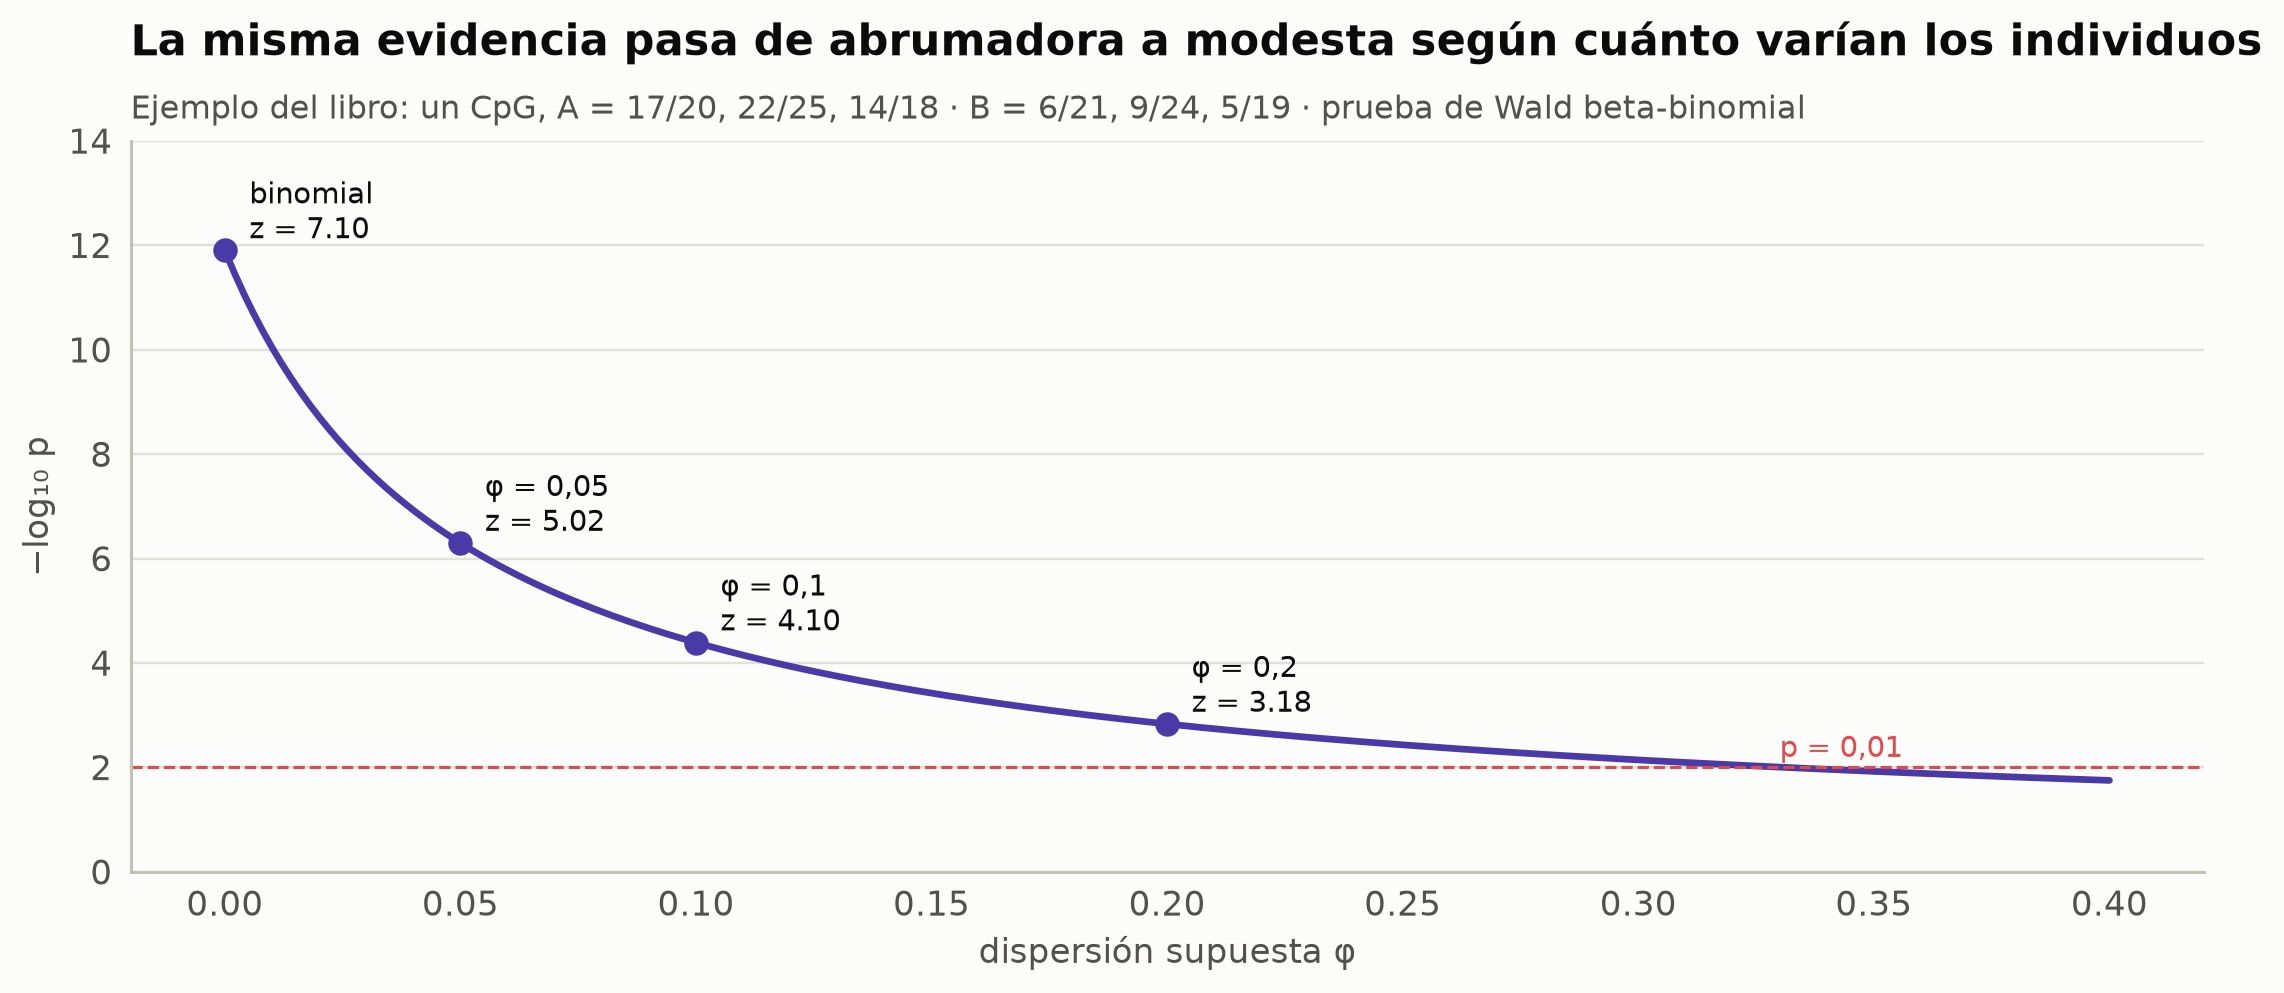

In [29]:
phis = np.linspace(0, 0.4, 200)
zs = np.array([wald_z(A_ex, B_ex, p)[0] for p in phis])
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(phis, -np.log10(2 * stats.norm.sf(zs)), color=ec.VIOLET, lw=2.2)
for p_, lab in [(0.0, "binomial"), (0.05, "φ = 0,05"), (0.1, "φ = 0,1"), (0.2, "φ = 0,2")]:
    z, p = wald_z(A_ex, B_ex, p_)
    ax.plot(p_, -np.log10(p), "o", color=ec.VIOLET, ms=7)
    ax.annotate(f"{lab}\nz = {z:.2f}", (p_, -np.log10(p)), xytext=(8, 4), textcoords="offset points", fontsize=9.5)
ax.axhline(2, color=ec.RED, ls="--", lw=1); ax.text(0.33, 2.2, "p = 0,01", color=ec.RED, fontsize=9.5)
ax.set_xlabel("dispersión supuesta φ"); ax.set_ylabel("−log₁₀ p"); ax.set_ylim(0, 14)
ec.title(ax, "La misma evidencia pasa de abrumadora a modesta según cuánto varían los individuos",
         "Ejemplo del libro: un CpG, A = 17/20, 22/25, 14/18 · B = 6/21, 9/24, 5/19 · prueba de Wald beta-binomial")
plt.show()

> 🔎 **Qué observamos.** La conclusión depende críticamente de $\phi$: entre la binomial y $\phi = 0{,}2$, el valor $p$
> cambia nueve órdenes de magnitud. Por eso las **réplicas biológicas son irrenunciables**: sin ellas no hay forma de
> estimar $\phi$.

### 🧪 Estimar y encoger la dispersión con datos reales

Con tres réplicas por grupo, estimar $\phi$ en cada CpG por separado es muy inestable. Seguimos la idea de DSS en una
versión simplificada y transparente:

1. **Filtro de variantes** (lo justificamos en la sección 8): si el genotipo inferido en una muestra muestra una T en la
   posición de la C (`TG`, `YG`) o una A en la de la G (`CA`, `CR`) con cobertura ≥ 5, excluimos **esa muestra** en ese
   CpG, no el CpG entero.
2. **Estimador de momentos** por CpG y grupo: si $\operatorname{Var}(\hat p_r)\approx\mu(1-\mu)[\phi+(1-\phi)/n_r]$,
   despejamos $\phi$ de la varianza observada entre réplicas y promediamos los dos grupos.
3. **A priori lognormal**: ajustamos la media y la desviación de $\log\hat\phi_{\text{mom}}$ sobre todos los CpG.
4. **Moda a posteriori**: para cada CpG maximizamos (en una rejilla) la verosimilitud beta-binomial de sus seis
   réplicas más el logaritmo de la a priori. Los CpG con poca información quedan cerca del valor típico; los que tienen
   mucha evidencia conservan su propio valor.

In [30]:
# 1) filtro de variantes: se excluye la muestra en ese CpG
is_var = wgbs.geno.isin(["TG", "YG", "CA", "CR"]) & (wgbs["cov"] >= 5)
var_pairs = set(zip(wgbs.loc[is_var, "sample"], wgbs.loc[is_var, "cpg"]))
clean = wgbs[[(s, p) not in var_pairs for s, p in zip(wgbs["sample"], wgbs.cpg)]]
tab_c = clean.groupby(["cpg", "sample"])[["cov", "meth"]].sum().unstack(fill_value=0)
Nc, Cc = tab_c["cov"][A_S + B_S], tab_c["meth"][A_S + B_S]
keep = (Nc[A_S] > 0).sum(axis=1).ge(2) & (Nc[B_S] > 0).sum(axis=1).ge(2)   # ≥ 2 réplicas con datos por grupo
Nc, Cc = Nc[keep], Cc[keep]
pos_real = Nc.index.values
nA, cA, nB, cB = Nc[A_S].values, Cc[A_S].values, Nc[B_S].values, Cc[B_S].values
print(f"Pares muestra-CpG excluidos por variante: {len(var_pairs)} · CpG analizables: {len(pos_real)}")

# 2) estimador de momentos
def mom_phi(c, n):
    ok = n > 0
    mu = c.sum(1) / n.sum(1)
    p = np.where(ok, c / np.where(ok, n, 1), np.nan)
    s2 = np.nansum((p - mu[:, None]) ** 2, 1) / np.maximum(ok.sum(1) - 1, 1)
    inv_n = np.nanmean(np.where(ok, 1 / np.where(ok, n, 1), np.nan), 1)
    with np.errstate(divide="ignore", invalid="ignore"):          # n_r = 1 en todas las réplicas: sin información
        return (s2 / np.maximum(mu * (1 - mu), 1e-9) - inv_n) / (1 - inv_n)

phi_mom = np.clip(np.nanmean(np.vstack([mom_phi(cA, nA), mom_phi(cB, nB)]), 0), 1e-3, 0.5)
# 3) a priori lognormal
m_log, s_log = np.log(phi_mom).mean(), np.log(phi_mom).std()
# 4) moda a posteriori en una rejilla
grid_phi = np.exp(np.linspace(np.log(1e-3), np.log(0.5), 150))
def bb_loglik(c, n, mu, phi):
    a, b = mu * (1 - phi) / phi, (1 - mu) * (1 - phi) / phi
    return special.betaln(c + a, n - c + b) - special.betaln(a, b)
LL = np.zeros((len(pos_real), len(grid_phi)))
for c_, n_ in [(cA, nA), (cB, nB)]:
    mu_g = np.clip(c_.sum(1) / n_.sum(1), 0.01, 0.99)
    for j in range(c_.shape[1]):
        LL += bb_loglik(c_[:, [j]], n_[:, [j]], mu_g[:, None], grid_phi[None, :])
phi_mle = grid_phi[LL.argmax(1)]
phi_post = grid_phi[(LL + stats.norm.logpdf(np.log(grid_phi), m_log, s_log)[None, :]).argmax(1)]
print(f"A priori lognormal: mediana exp(m) = {np.exp(m_log):.4f}, de(log φ) = {s_log:.2f}")
print(f"Máxima verosimilitud pegada al límite inferior en {np.mean(phi_mle == grid_phi[0]):.0%} de los CpG")
print(f"φ encogida: mediana {np.median(phi_post):.4f} · percentiles 10–90: "
      f"{np.percentile(phi_post, 10):.4f}–{np.percentile(phi_post, 90):.4f}")

Pares muestra-CpG excluidos por variante: 13 · CpG analizables: 220


A priori lognormal: mediana exp(m) = 0.0129, de(log φ) = 2.63
Máxima verosimilitud pegada al límite inferior en 59% de los CpG
φ encogida: mediana 0.0095 · percentiles 10–90: 0.0051–0.0707


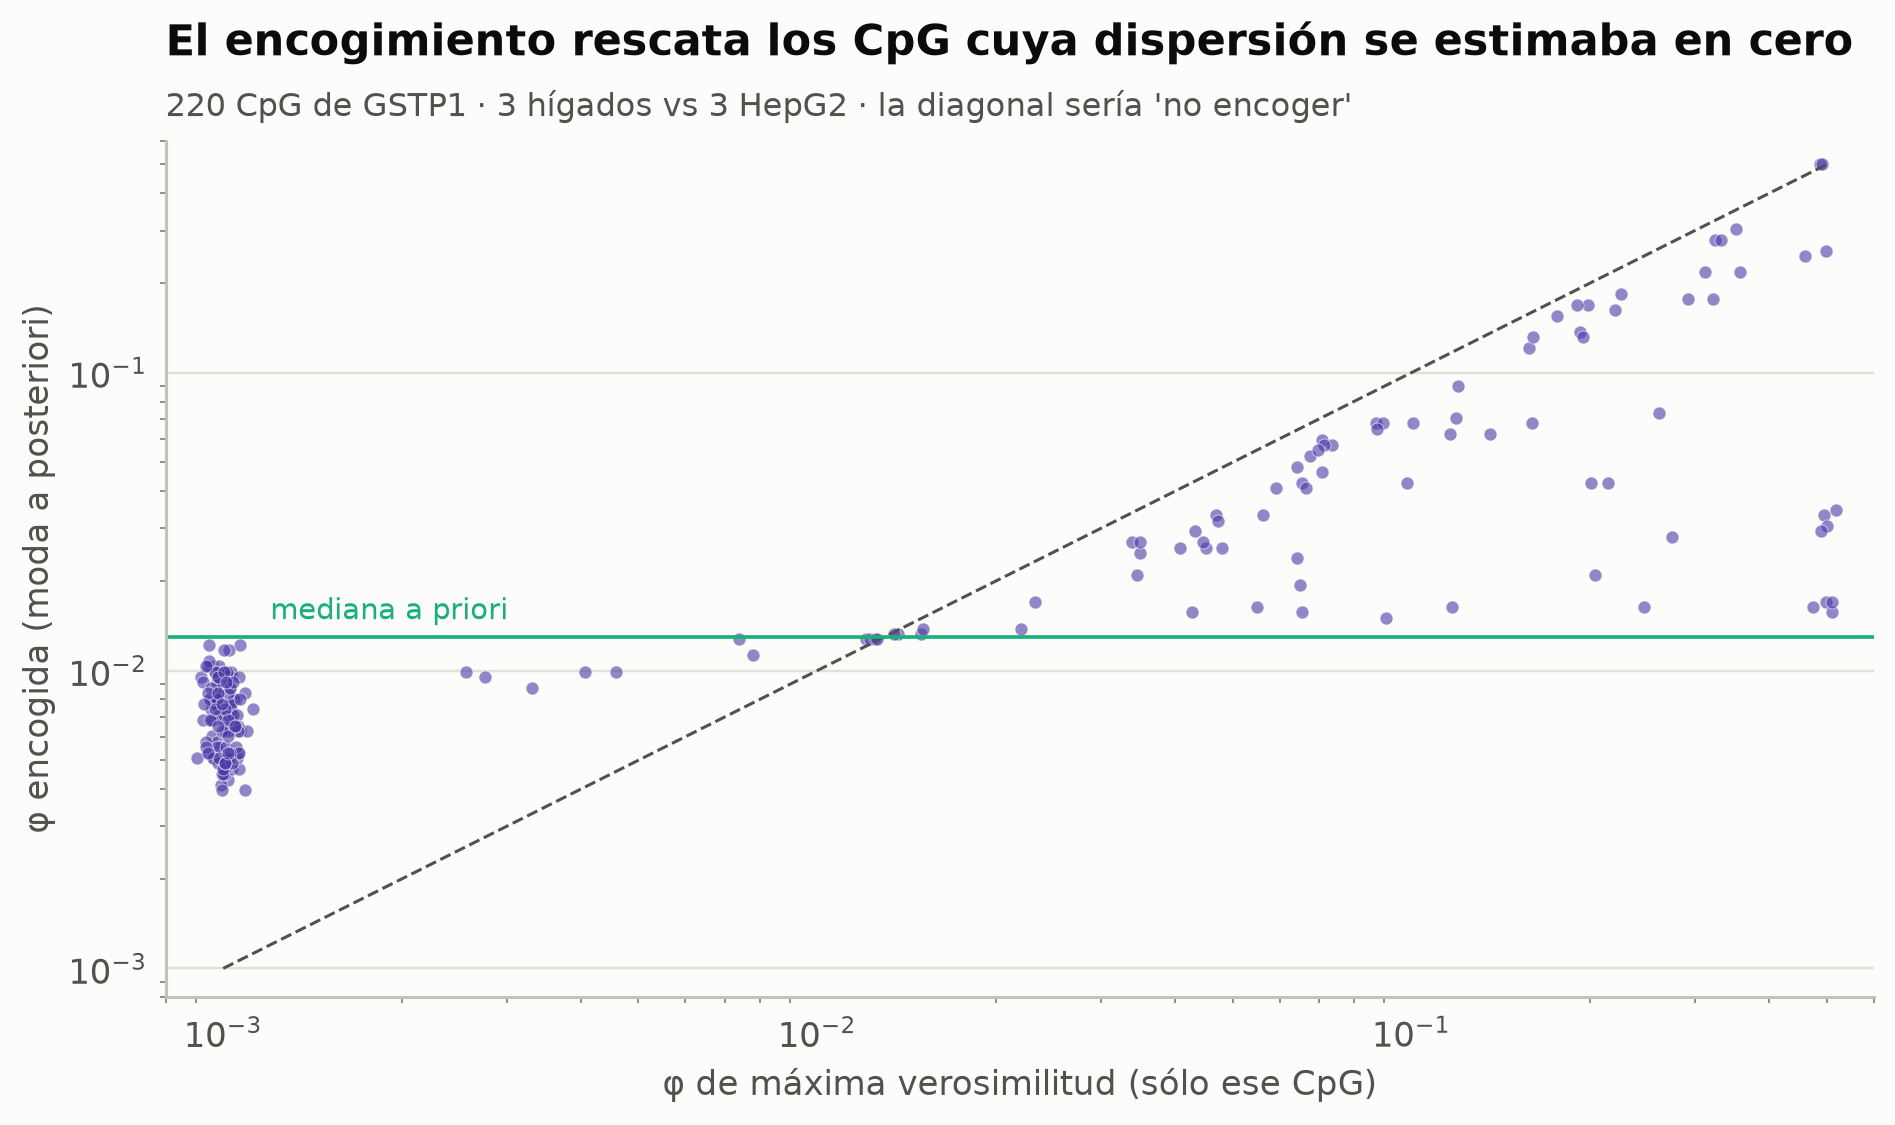

In [31]:
fig, ax = plt.subplots(figsize=(8.5, 5))
jit = np.exp(rng.normal(0, 0.04, len(phi_mle)))
ax.scatter(phi_mle * jit, phi_post, s=18, color=ec.VIOLET, alpha=0.6, edgecolor="white", lw=0.3)
ax.plot([1e-3, 0.5], [1e-3, 0.5], color=ec.INK_2, ls="--", lw=1)
ax.axhline(np.exp(m_log), color=ec.AQUA, lw=1.2); ax.text(0.0012, np.exp(m_log) * 1.15, "mediana a priori", color=ec.AQUA, fontsize=9.5)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(8e-4, 0.6); ax.set_ylim(8e-4, 0.6)
ax.set_xlabel("φ de máxima verosimilitud (sólo ese CpG)"); ax.set_ylabel("φ encogida (moda a posteriori)")
ec.title(ax, "El encogimiento rescata los CpG cuya dispersión se estimaba en cero",
         "220 CpG de GSTP1 · 3 hígados vs 3 HepG2 · la diagonal sería 'no encoger'")
plt.show()

> 🔎 **Qué observamos.** En más de la mitad de los CpG la máxima verosimilitud dice "$\phi$ = 0" (el límite de la
> rejilla): con tres réplicas y pocas lecturas, la variación observada entre réplicas cabe en el ruido binomial. Tomar
> ese cero al pie de la letra sería volver a la binomial y a sus falsos positivos. El encogimiento sube esos valores
> hacia el típico y deja casi intactos los CpG con dispersión clara (arriba a la derecha, cerca de la diagonal).

## 7. De sitios a regiones

### Por qué pensar en regiones

Los CpG vecinos están fuertemente **correlacionados**: la metilación cambia por bloques de cientos de pares de bases, no
sitio a sitio. Los métodos de DMR (BSmooth, de Hansen *et al.*, 2012; DSS; y otros) aprovechan esa estructura de dos
maneras:

1. **Suavizan** los niveles de metilación a lo largo del genoma: cada punto de la curva es un promedio ponderado de los
   CpG vecinos, lo que además "presta" cobertura de los vecinos a los CpG poco cubiertos. Usamos el núcleo gaussiano del
   libro con ancho $h = 150$ pb: $\tilde\beta(x) = \sum_j w_j\hat\beta_j / \sum_j w_j$ con
   $w_j = \exp\!\big(-\tfrac12 ((x_j - x)/h)^2\big)$.
2. **Agrupan** CpG significativos contiguos en regiones, con requisitos mínimos de longitud, número de CpG y diferencia
   media. El libro usa el criterio más simple: la DMR es el **tramo contiguo más largo** de CpG con $p < 0{,}01$.

### La DMR simulada del libro

55 CpG en 3 kb, tres réplicas por grupo, cobertura media de 14 lecturas y datos beta-binomiales con $\phi = 0{,}05$. El
grupo B pierde la metilación en un bloque central (1100–1900 pb), como en la hipometilación de un potenciador activado.
Reproducimos la simulación con la misma semilla (107) y el mismo código.

In [32]:
# Código del libro (figuras/cap13/generar.py, bloque 13.2-b)
rng107 = np.random.default_rng(107)
pos_cg = np.sort(rng107.choice(np.arange(0, 3000), 55, replace=False))
mu_a = 0.82 - 0.05 * np.sin(pos_cg / 500)
mu_b = mu_a.copy()
dmr_true = (pos_cg > 1100) & (pos_cg < 1900)
mu_b[dmr_true] = 0.25 + 0.05 * np.cos(pos_cg[dmr_true] / 200)
phi_s = 0.05
rows = []
for j, p in enumerate(pos_cg):
    ra, rb = [], []
    for g, mu in [("a", mu_a[j]), ("b", mu_b[j])]:
        for r in range(3):
            nn = max(rng107.poisson(14), 3)
            pp = rng107.beta(mu * (1 - phi_s) / phi_s, (1 - mu) * (1 - phi_s) / phi_s)
            cc = rng107.binomial(nn, pp)
            (ra if g == "a" else rb).append((cc, nn))
    rows.append((p, ra, rb))
pts_a = [(p, c / n) for p, ra, _ in rows for c, n in ra]
pts_b = [(p, c / n) for p, _, rb in rows for c, n in rb]
z_sim = np.array([wald_z(ra, rb, phi_s)[0] if True else 0 for _, ra, rb in rows])
p_sim = 2 * stats.norm.sf(np.abs(z_sim))

def longest_run(sig):
    """Tramo contiguo más largo de True: (longitud, inicio, fin) en índices."""
    best, cur, st = (0, 0, 0), 0, 0
    for j, s in enumerate(sig):
        if s:
            st = j if cur == 0 else st
            cur += 1
            if cur > best[0]:
                best = (cur, st, j)
        else:
            cur = 0
    return best

def smooth(pts, grid, h=150):
    P = np.array(pts)
    w = np.exp(-0.5 * ((P[:, 0][None, :] - grid[:, None]) / h) ** 2)
    return (w * P[:, 1]).sum(1) / w.sum(1)

sig_sim = p_sim < 0.01
run = longest_run(sig_sim)
print(f"CpG totales = {len(pos_cg)} · dentro de la DMR real = {dmr_true.sum()} · "
      f"significativos (p < 0,01) = {sig_sim.sum()} (dentro = {(sig_sim & dmr_true).sum()})")
print(f"DMR llamada: CpG {run[1]}..{run[2]}, posiciones {pos_cg[run[1]]}–{pos_cg[run[2]]} ({run[0]} CpG)")
assert (len(pos_cg), dmr_true.sum(), sig_sim.sum(), (sig_sim & dmr_true).sum()) == (55, 14, 15, 14)
assert (pos_cg[run[1]], pos_cg[run[2]]) == (1159, 1835)

CpG totales = 55 · dentro de la DMR real = 14 · significativos (p < 0,01) = 15 (dentro = 14)
DMR llamada: CpG 21..34, posiciones 1159–1835 (14 CpG)


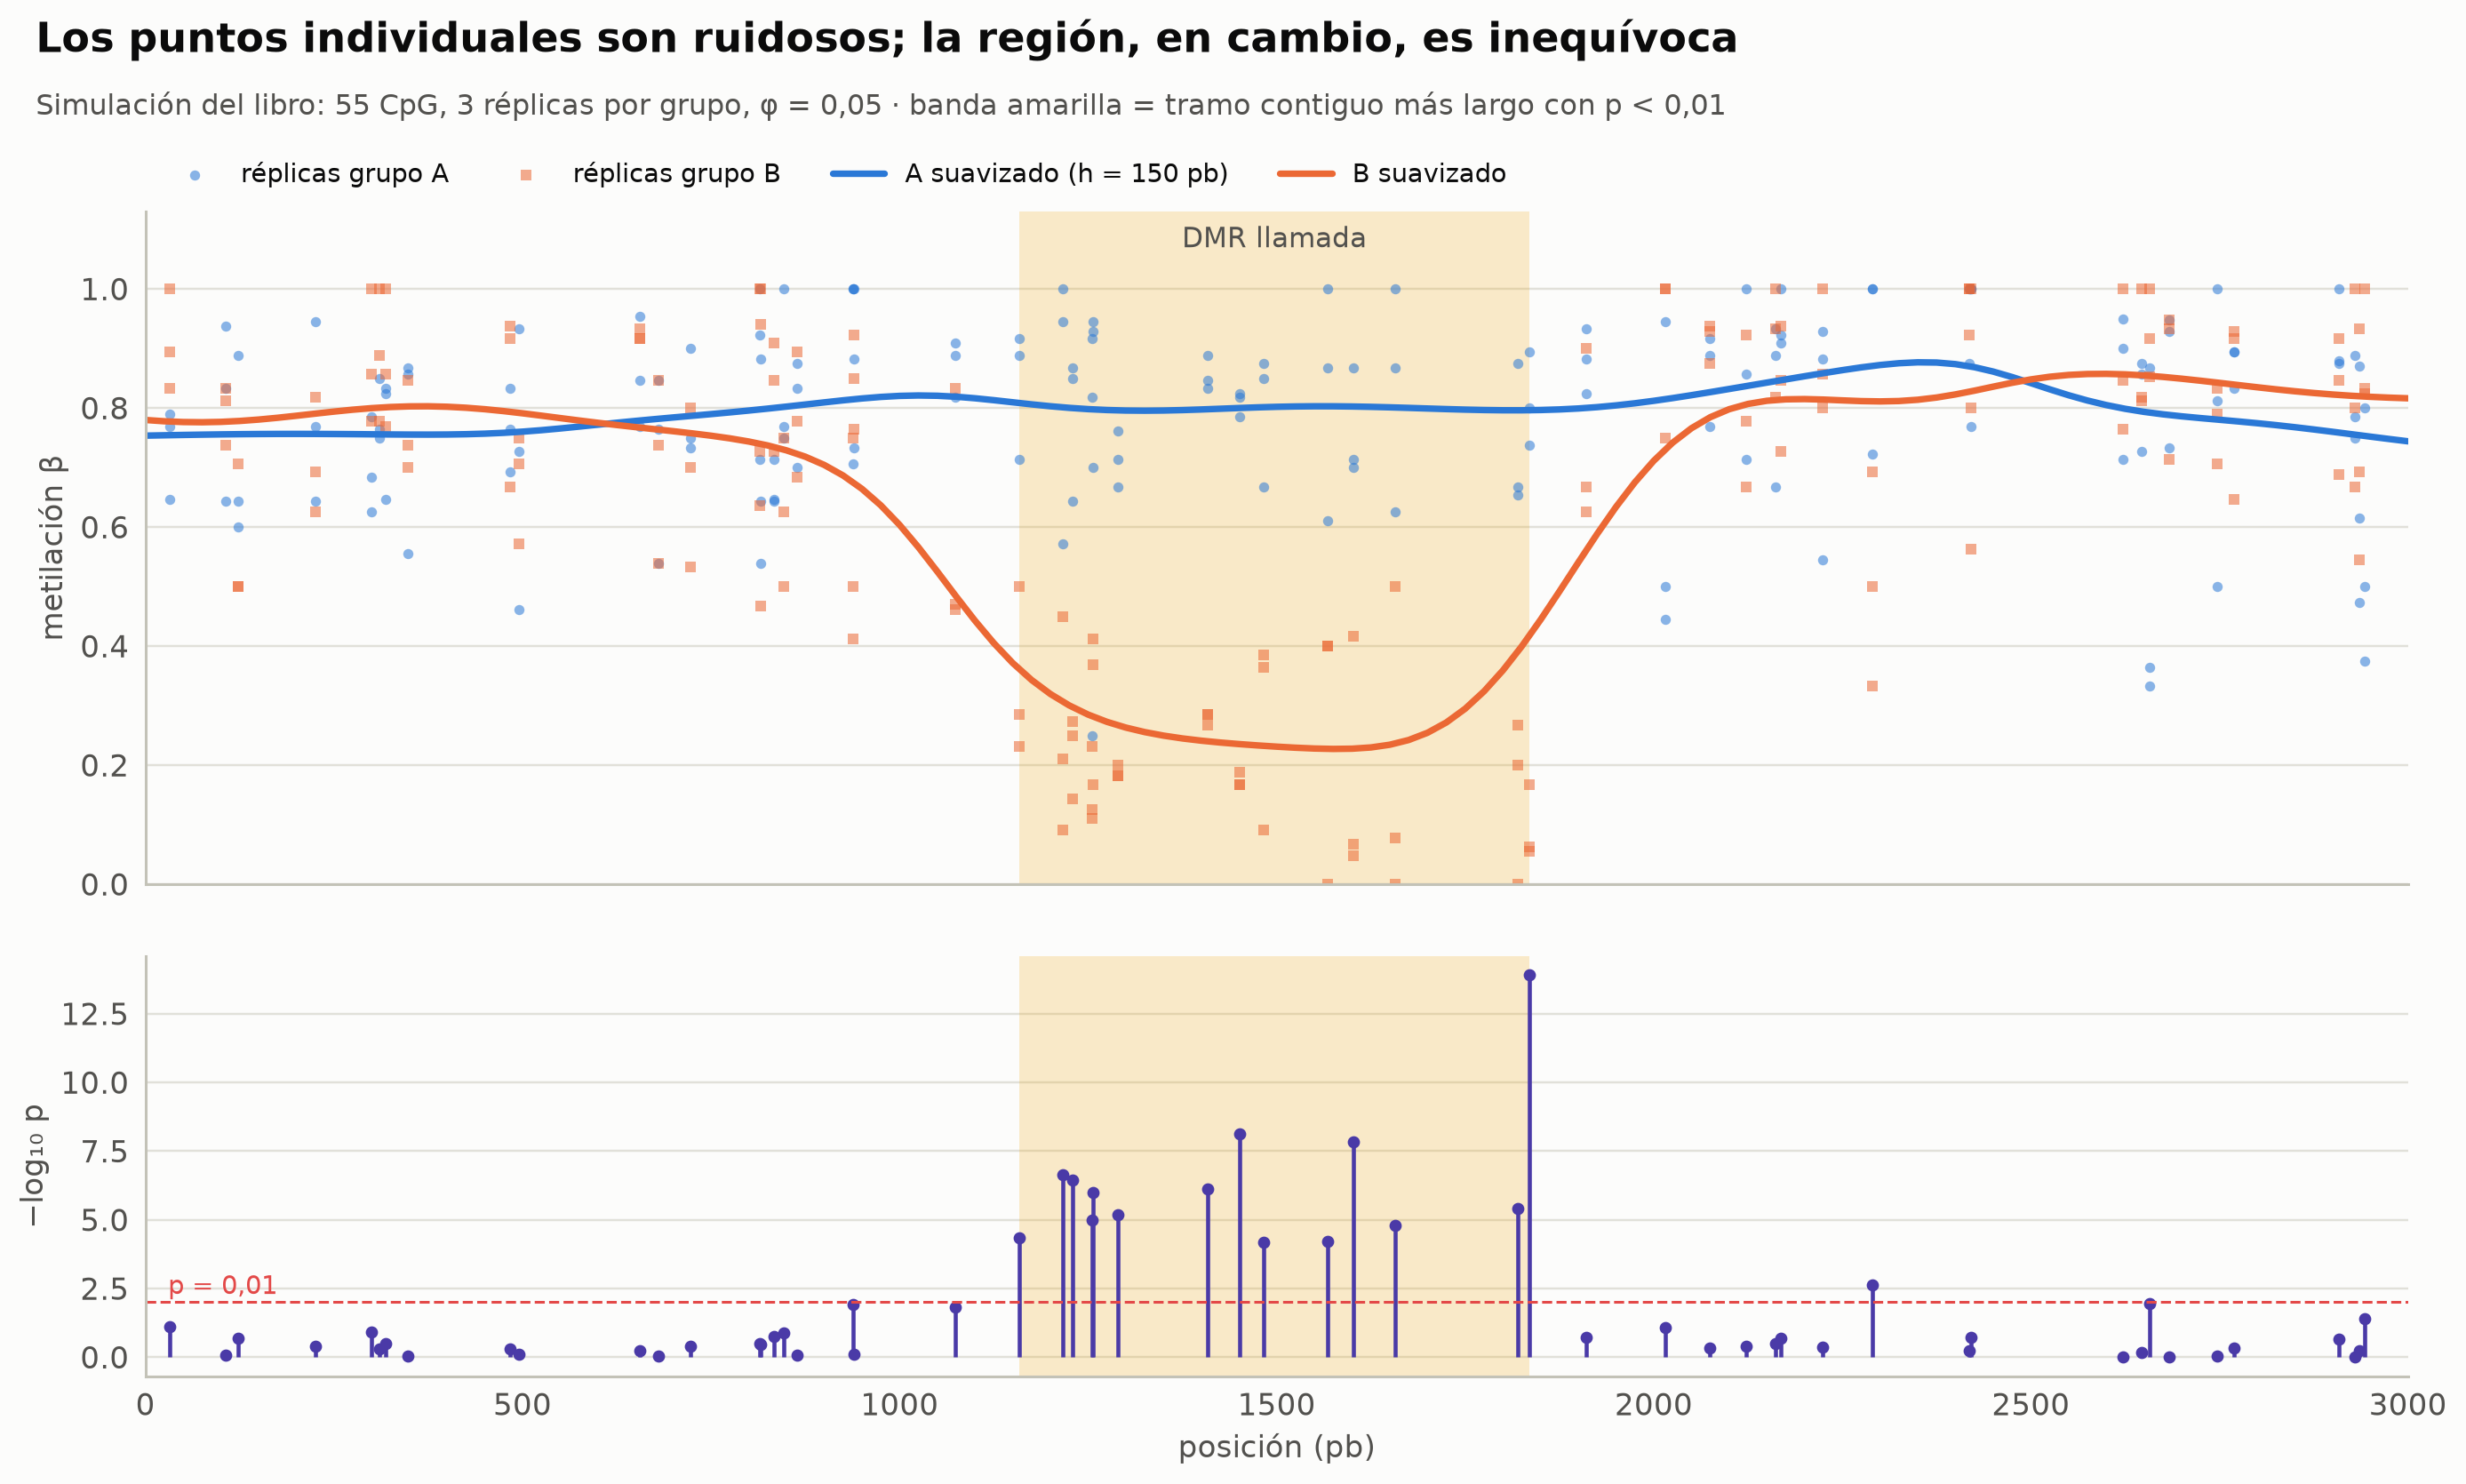

In [33]:
grid_sim = np.arange(0, 3001, 25)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 6.8), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1], hspace=0.08))
for ax in (ax1, ax2):
    ax.axvspan(pos_cg[run[1]], pos_cg[run[2]], color=ec.YELLOW, alpha=0.2, lw=0)
PA, PB = np.array(pts_a), np.array(pts_b)
ax1.scatter(PA[:, 0], PA[:, 1], s=14, color=ec.BLUE, alpha=0.55, label="réplicas grupo A")
ax1.scatter(PB[:, 0], PB[:, 1], s=14, marker="s", color=ec.ORANGE, alpha=0.55, label="réplicas grupo B")
ax1.plot(grid_sim, smooth(pts_a, grid_sim), color=ec.BLUE, lw=2.4, label="A suavizado (h = 150 pb)")
ax1.plot(grid_sim, smooth(pts_b, grid_sim), color=ec.ORANGE, lw=2.4, label="B suavizado")
ax1.set_ylim(0, 1.13); ax1.set_ylabel("metilación β")
ax1.legend(ncol=4, frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), fontsize=9.5)
ax1.text((pos_cg[run[1]] + pos_cg[run[2]]) / 2, 1.07, "DMR llamada", ha="center", fontsize=10, color=ec.INK_2)
ax2.vlines(pos_cg, 0, -np.log10(p_sim), color=ec.VIOLET, lw=1.5)
ax2.plot(pos_cg, -np.log10(p_sim), "o", color=ec.VIOLET, ms=3.5)
ax2.axhline(2, color=ec.RED, ls="--", lw=1); ax2.text(30, 2.3, "p = 0,01", color=ec.RED, fontsize=9.5)
ax2.set_ylabel("−log₁₀ p"); ax2.set_xlabel("posición (pb)"); ax2.set_xlim(0, 3000)
ec.fig_title(fig, "Los puntos individuales son ruidosos; la región, en cambio, es inequívoca",
             "Simulación del libro: 55 CpG, 3 réplicas por grupo, φ = 0,05 · banda amarilla = tramo contiguo más largo con p < 0,01")
plt.show()

> 🔎 **Qué observamos.** 15 CpG superan $p < 0{,}01$; 14 están dentro de la DMR verdadera y uno es un falso positivo
> aislado. El tramo contiguo más largo (1159–1835 pb) recupera la región casi exactamente: exigir **contigüidad** es un
> filtro poderoso contra los falsos positivos sueltos, porque es improbable que el azar produzca muchos seguidos.

### 🧪 La DMR real de *GSTP1*: hígado normal frente a HepG2

Aplicamos exactamente lo mismo a los datos de ENCODE, con la dispersión encogida de la sección anterior. Para ver
cuánto importa $\phi$ en datos reales, repetimos la prueba con varios valores fijos.

In [34]:
def wald_vec(cA, nA, cB, nB, phi):
    """Prueba de Wald del libro, vectorizada sobre CpG; ignora réplicas sin cobertura (n = 0)."""
    phi = np.asarray(phi, float).reshape(-1, 1) if np.ndim(phi) else phi
    out = []
    for c_, n_ in [(cA, nA), (cB, nB)]:
        ok = n_ > 0
        mu = c_.sum(1) / n_.sum(1)
        v = np.where(ok, mu[:, None] * (1 - mu[:, None]) * (1 + (n_ - 1) * phi) / np.where(ok, n_, 1), 0).sum(1)
        out.append((mu, v / ok.sum(1) ** 2))
    (muA, vA), (muB, vB) = out
    z = (muA - muB) / np.sqrt(np.maximum(vA + vB, 1e-6))
    return muA, muB, z, np.maximum(2 * stats.norm.sf(np.abs(z)), 1e-300)

def longest_signed_run(sig, z):
    """Tramo contiguo más largo de CpG significativos con el mismo signo de z."""
    best, cur, st = (0, 0, 0), 0, 0
    for j in range(len(sig)):
        if sig[j] and cur > 0 and np.sign(z[j]) == np.sign(z[j - 1]):
            cur += 1
        elif sig[j]:
            cur, st = 1, j
        else:
            cur = 0
        if cur > best[0]:
            best = (cur, st, j)
    return best

tabla = []
for lab, ph in [("binomial (φ = 0)", 0.0), ("φ encogida (DSS simplificado)", phi_post),
                ("φ = 0,05", 0.05), ("φ = 0,1", 0.1), ("φ = 0,2", 0.2)]:
    muA_r, muB_r, z_r, p_r = wald_vec(cA, nA, cB, nB, ph)
    rn = longest_signed_run(p_r < 0.01, z_r)
    tabla.append((lab, (p_r < 0.01).sum(), rn[0], f"{pos_real[rn[1]]:,}–{pos_real[rn[2]]:,}",
                  (muB_r - muA_r)[rn[1]:rn[2] + 1].mean()))
tabla = pd.DataFrame(tabla, columns=["dispersión", "CpG con p < 0,01", "CpG en el tramo", "tramo", "Δβ medio (B − A)"])
print(f"{len(pos_real)} CpG analizados")
print(tabla.round(3).to_string(index=False))

muA_r, muB_r, z_r, p_r = wald_vec(cA, nA, cB, nB, phi_post)          # análisis principal
sig_r = p_r < 0.01
rn = longest_signed_run(sig_r, z_r)
DMR_S, DMR_E = pos_real[rn[1]], pos_real[rn[2]]
print(f"\nDMR llamada: {REG_CHROM}:{DMR_S:,}-{DMR_E + 2:,} ({rn[0]} CpG, {DMR_E + 2 - DMR_S} pb) · "
      f"isla de UCSC: {ISL_S:,}-{ISL_E:,} · TSS: {TSS:,}")

220 CpG analizados
                   dispersión  CpG con p < 0,01  CpG en el tramo                 tramo  Δβ medio (B − A)
             binomial (φ = 0)               137               58 67,583,253–67,583,906             0.828
φ encogida (DSS simplificado)               127               58 67,583,253–67,583,906             0.828
                     φ = 0,05               129               58 67,583,253–67,583,906             0.828
                      φ = 0,1               122               58 67,583,253–67,583,906             0.828
                      φ = 0,2               105               28 67,583,673–67,583,862             0.819

DMR llamada: chr11:67,583,253-67,583,908 (58 CpG, 655 pb) · isla de UCSC: 67,583,457-67,584,482 · TSS: 67,583,811


> 🤔 **Antes de ejecutar la figura, prediga:** ¿la DMR llamada cubrirá toda la isla CpG o sólo una parte? ¿Qué
> esperaría ver, en el hígado normal, en la parte de la isla más alejada del TSS?

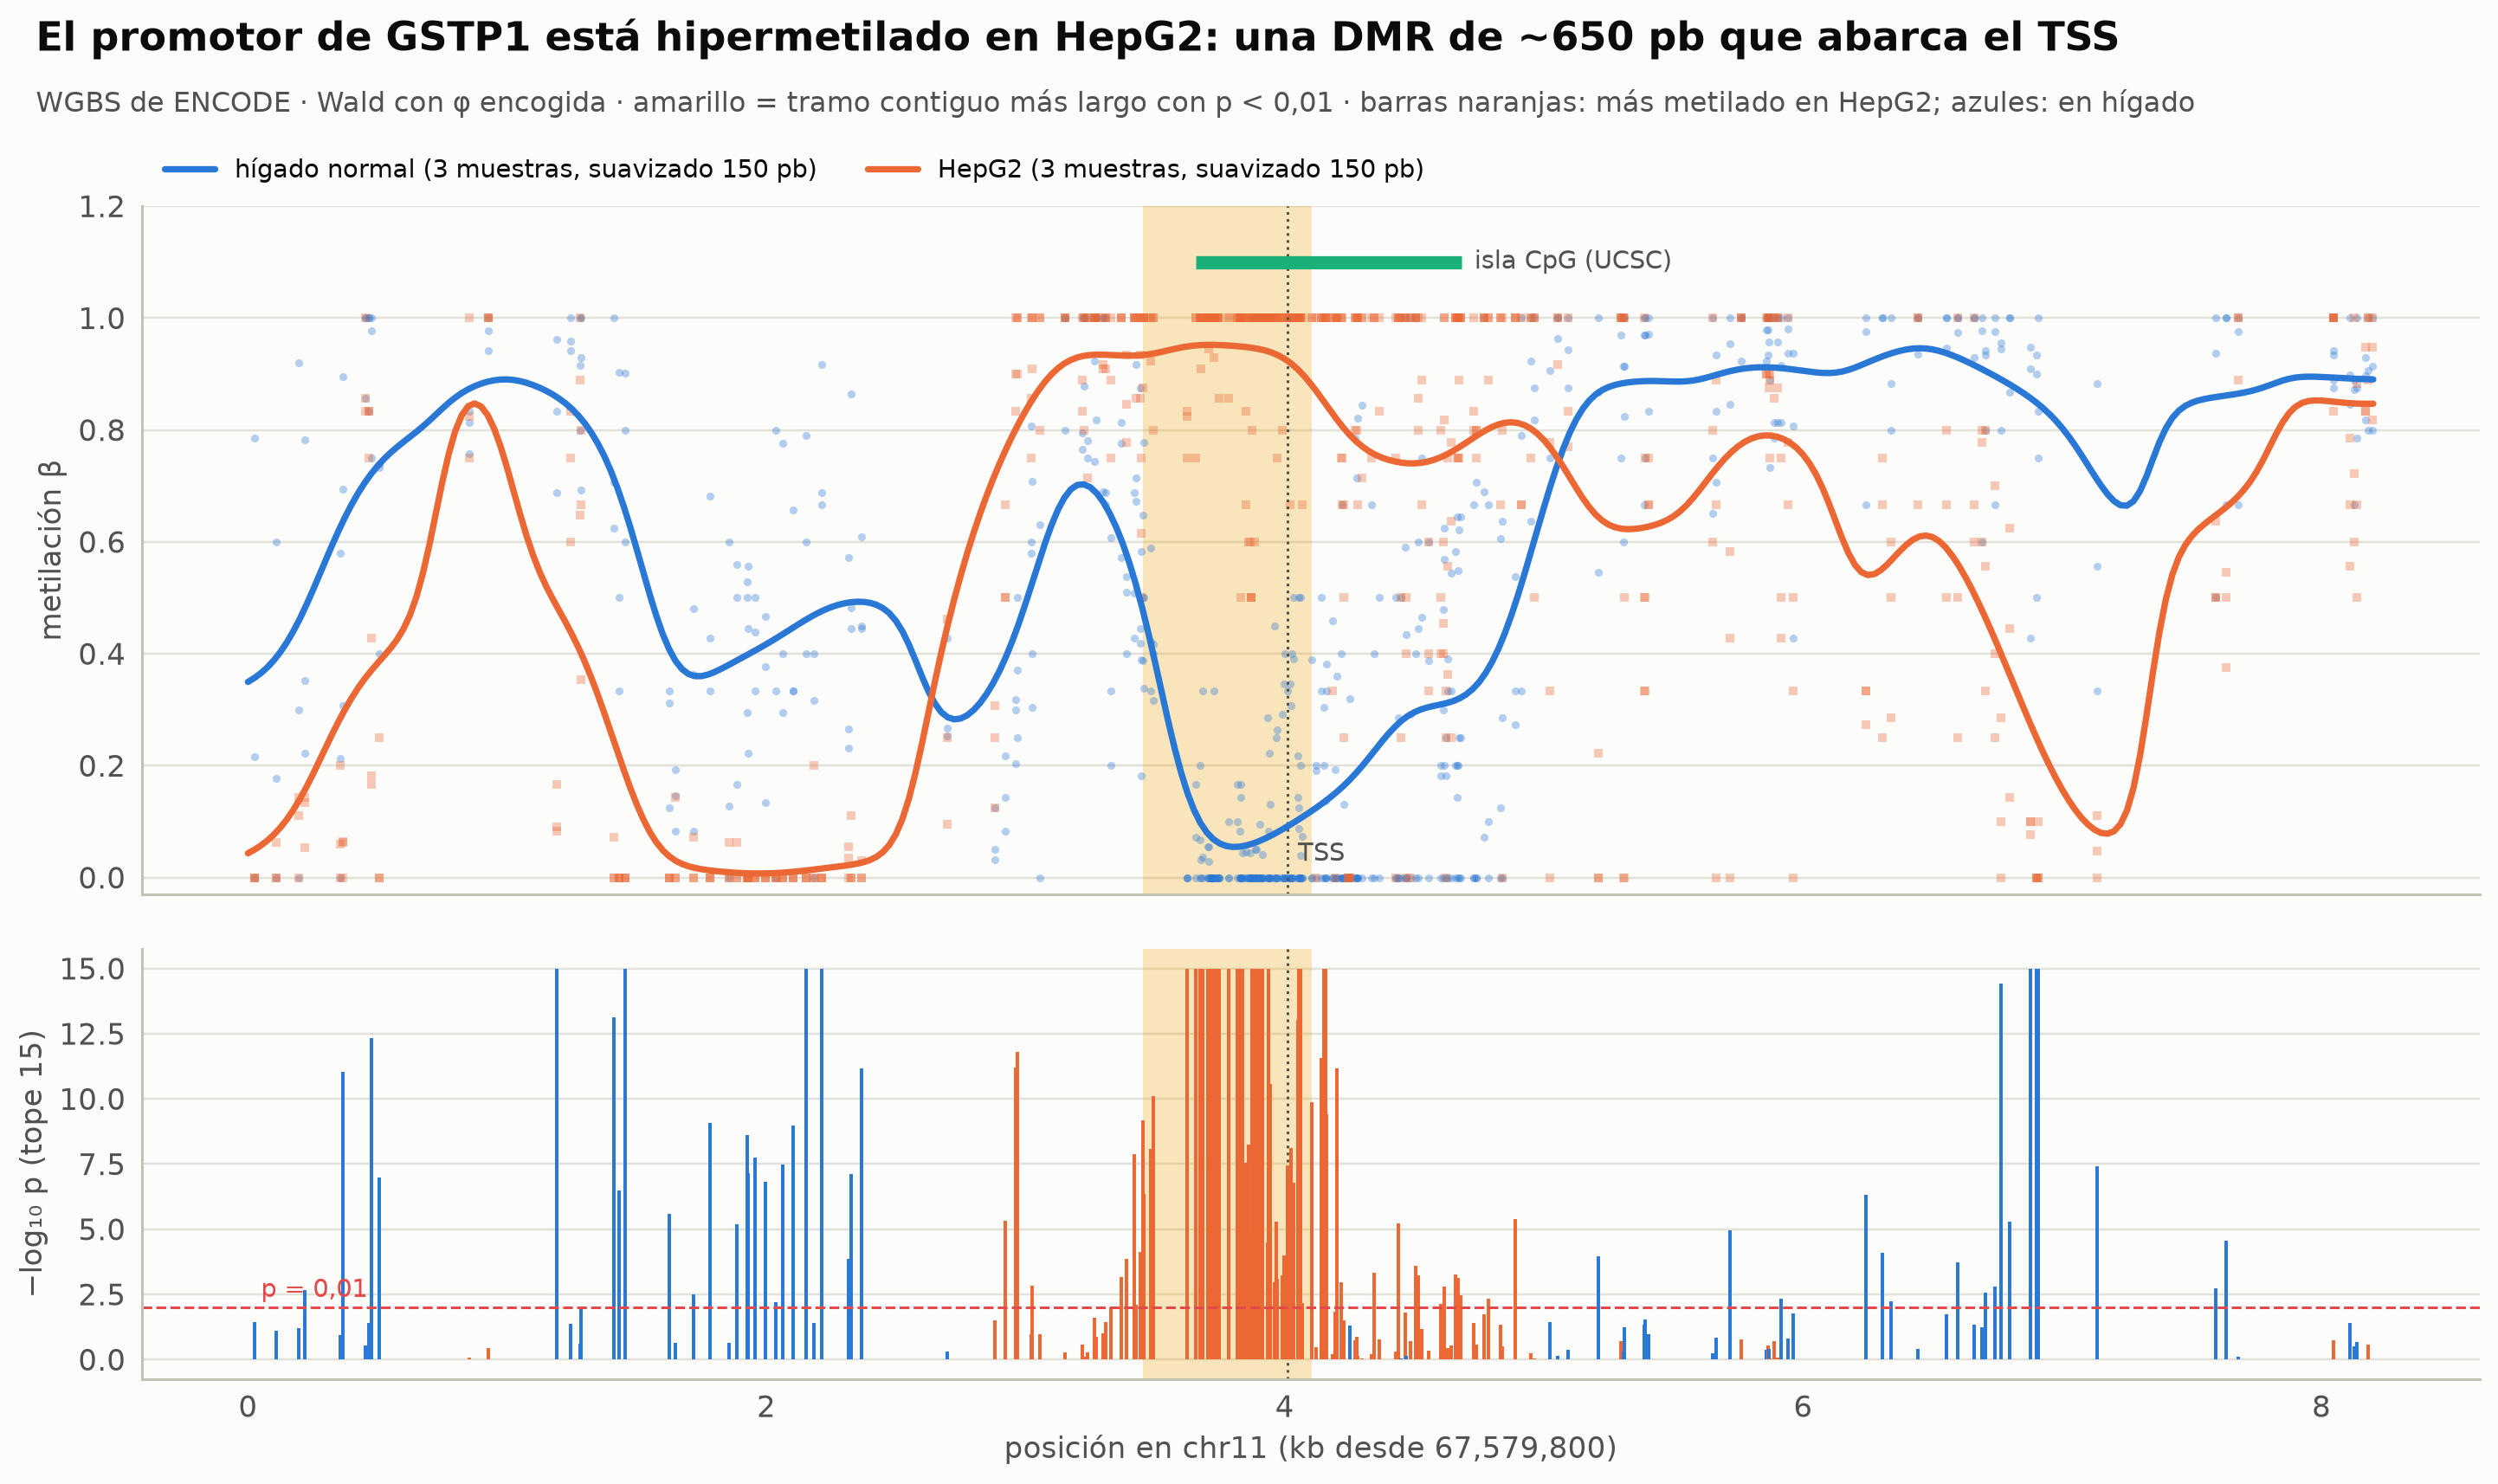

In [35]:
grid_real = np.arange(REG_START, REG_END + 1, 25)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1], hspace=0.08))
for ax in (ax1, ax2):
    ax.axvspan(kb(DMR_S), kb(DMR_E), color=ec.YELLOW, alpha=0.25, lw=0)
    ax.axvline(kb(TSS), color=ec.INK_2, ls=":", lw=1)
ax1.hlines(1.1, kb(ISL_S), kb(ISL_E), color=ec.AQUA, lw=5)
ax1.text(kb(ISL_E) + 0.05, 1.1, "isla CpG (UCSC)", va="center", fontsize=9.5, color=ec.INK_2)
ax1.text(kb(TSS) + 0.04, 0.03, "TSS", fontsize=9.5, color=ec.INK_2)
for S, col, mk, lab in [(A_S, NORMAL, "o", "hígado normal"), (B_S, TUMOR, "s", "HepG2")]:
    pts = [(p, c / n) for s in S for p, c, n in zip(pos_real, Cc[s].values, Nc[s].values) if n > 0]
    P = np.array(pts)
    ax1.scatter(kb(P[:, 0]), P[:, 1], s=9, marker=mk, color=col, alpha=0.35)
    ax1.plot(kb(grid_real), smooth(pts, grid_real), color=col, lw=2.4, label=f"{lab} (3 muestras, suavizado 150 pb)")
ax1.set_ylim(-0.03, 1.2); ax1.set_ylabel("metilación β")
ax1.legend(ncol=2, frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), fontsize=9.5)
ax2.vlines(kb(pos_real), 0, np.minimum(-np.log10(p_r), 15), color=np.where(z_r < 0, TUMOR, NORMAL), lw=1.3)
ax2.axhline(2, color=ec.RED, ls="--", lw=1); ax2.text(0.05, 2.4, "p = 0,01", color=ec.RED, fontsize=9.5)
ax2.set_ylabel("−log₁₀ p (tope 15)"); ax2.set_xlabel(f"posición en {REG_CHROM} (kb desde {REG_START:,})")
ec.fig_title(fig, "El promotor de GSTP1 está hipermetilado en HepG2: una DMR de ~650 pb que abarca el TSS",
             "WGBS de ENCODE · Wald con φ encogida · amarillo = tramo contiguo más largo con p < 0,01 · "
             "barras naranjas: más metilado en HepG2; azules: en hígado")
plt.show()

> 🔎 **Qué observamos.** La DMR llamada (≈ 58 CpG) empieza unos 200 pb antes de la isla de UCSC y termina justo después
> del TSS: es el **núcleo del promotor**, donde el hígado normal está poco metilado (≈ 10–16 %) y HepG2 casi al 100 %.
> En la mitad 3' de la isla la diferencia persiste pero se atenúa (el hígado normal ya tiene cierta metilación allí).
> Aparecen además muchos CpG significativos en sentido contrario (azules, entre 0,3 y 2,4 kb y hacia 6,5–7 kb),
> aunque en tramos contiguos más cortos: HepG2 ha **perdido** metilación en zonas del "mar" que el hígado mantiene
> metiladas. Hipermetilación focal de islas e hipometilación del resto son las
> dos caras clásicas del metiloma del cáncer. La tabla muestra otra cosa: aquí la diferencia es tan grande que el
> núcleo de la DMR sobrevive a cualquier $\phi$ razonable; sólo con $\phi = 0{,}2$ se encoge. En comparaciones más
> sutiles (tumor frente a tejido de la misma persona, exposiciones ambientales), la elección de $\phi$ decide el
> resultado, como vimos en el ejemplo del libro.

La versión interactiva permite inspeccionar cada CpG: medias por grupo, dispersión encogida, $z$ y $p$.

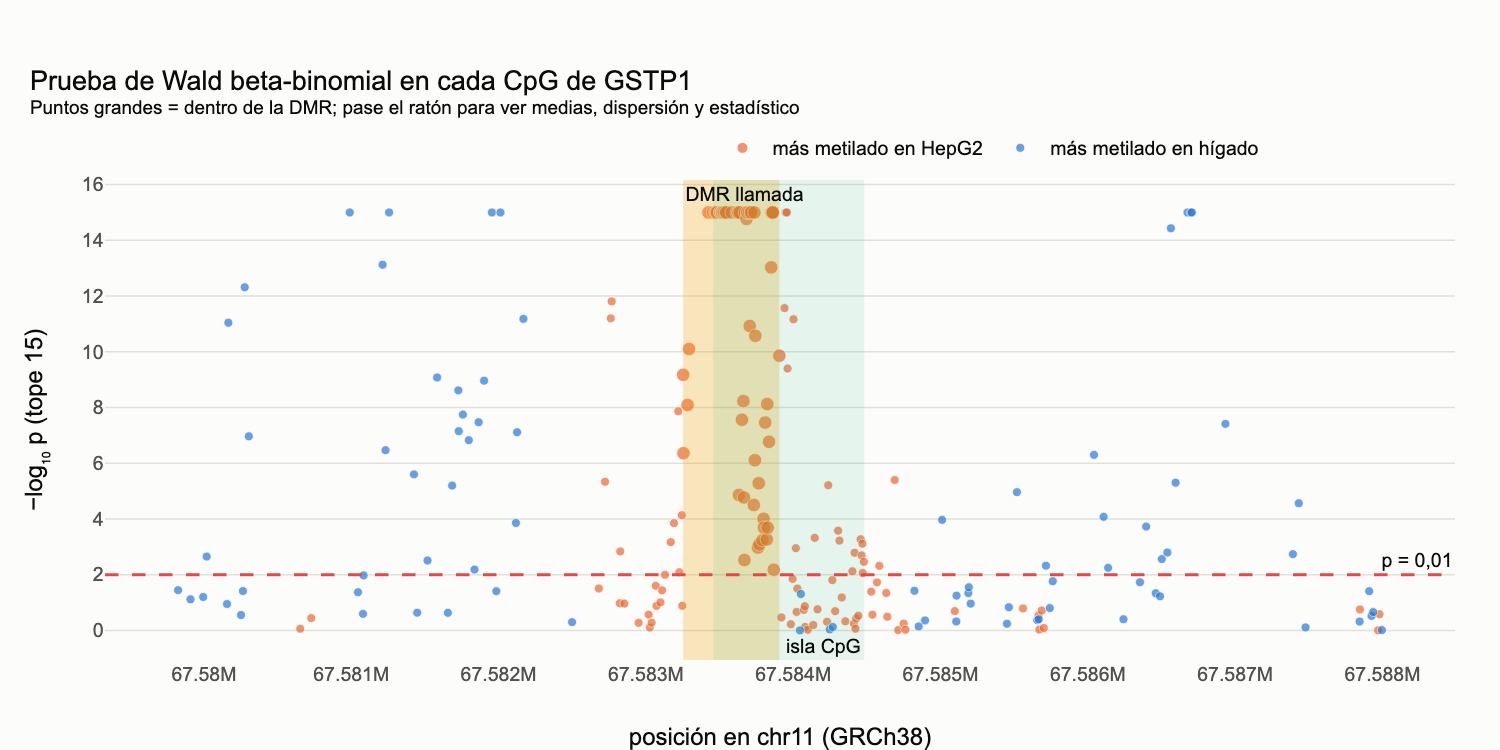

In [36]:
in_dmr = (pos_real >= DMR_S) & (pos_real <= DMR_E)
figd = go.Figure()
figd.add_vrect(x0=DMR_S, x1=DMR_E, fillcolor=ec.YELLOW, opacity=0.25, line_width=0,
               annotation_text="DMR llamada", annotation_position="top left")
figd.add_vrect(x0=ISL_S, x1=ISL_E, fillcolor=ec.AQUA, opacity=0.10, line_width=0,
               annotation_text="isla CpG", annotation_position="bottom right")
nA_tot, nB_tot = nA.sum(1), nB.sum(1)
for mask, name, col in [(z_r < 0, "más metilado en HepG2", TUMOR), (z_r >= 0, "más metilado en hígado", NORMAL)]:
    figd.add_trace(go.Scatter(
        x=pos_real[mask], y=np.minimum(-np.log10(p_r[mask]), 15), mode="markers", name=name,
        marker=dict(size=np.where(in_dmr[mask], 9, 6), color=col, line=dict(width=0.5, color="white")),
        customdata=np.c_[muA_r[mask], muB_r[mask], phi_post[mask], z_r[mask], p_r[mask], nA_tot[mask], nB_tot[mask]],
        hovertemplate=("CpG en %{x:,}<br>μ̂ hígado = %{customdata[0]:.2f} (%{customdata[5]} lecturas)"
                       "<br>μ̂ HepG2 = %{customdata[1]:.2f} (%{customdata[6]} lecturas)"
                       "<br>φ̂ encogida = %{customdata[2]:.3f}<br>z = %{customdata[3]:.2f} · p = %{customdata[4]:.1e}"
                       "<extra></extra>")))
figd.add_hline(y=2, line_dash="dash", line_color=ec.RED, annotation_text="p = 0,01")
figd.update_layout(height=500, margin=dict(t=120, l=70, r=30, b=60), xaxis_title=f"posición en {REG_CHROM} (GRCh38)",
                   yaxis_title="−log₁₀ p (tope 15)", legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.45),
                   title="Prueba de Wald beta-binomial en cada CpG de GSTP1<br><sup>Puntos grandes = dentro de la DMR; "
                         "pase el ratón para ver medias, dispersión y estadístico</sup>")
figd.show()

In [37]:
# Resumen clínico: β de la DMR por muestra, con intervalo de Jeffreys
Nd, Cd = Nc[in_dmr].sum(), Cc[in_dmr].sum()
clin = pd.DataFrame({"grupo": ["hígado normal"] * 3 + ["HepG2"] * 3, "lecturas": Nd, "metiladas": Cd,
                     "β DMR": Cd / Nd,
                     "IC95 Jeffreys": [f"{stats.beta.ppf(.025, c + .5, n - c + .5):.3f}–{stats.beta.ppf(.975, c + .5, n - c + .5):.3f}"
                                       for c, n in zip(Cd, Nd)]})
print(clin.round(3).to_string())

                   grupo  lecturas  metiladas  β DMR IC95 Jeffreys
sample                                                            
liver_hep  hígado normal       462         45  0.097   0.073–0.127
liver_OMA  hígado normal      1564        249  0.159   0.142–0.178
liver_LXB  hígado normal       149         19  0.128   0.081–0.188
HepG2_a1           HepG2       358        343  0.958   0.934–0.975
HepG2_a2           HepG2       234        225  0.962   0.931–0.981
HepG2_b1           HepG2       363        351  0.967   0.945–0.982


> 🔎 **Qué observamos.** Resumida en la DMR, la diferencia es la de un informe de laboratorio: el hígado normal ronda
> el 10–16 % de metilación y HepG2 el 96 %. Nuestros datos son de hígado y de HepG2, no de
> pacientes con cáncer de próstata; pero cifras de este orden, medidas en tejido prostático (con pirosecuenciación, PCR
> específica de metilación o secuenciación dirigida), apoyarían un diagnóstico de carcinoma cuando la histología es
> dudosa.

> ✅ **Compruebe su comprensión.** Cada muestra de HepG2 es una réplica de **la misma línea celular**. ¿Qué tipo de
> variación capturan entonces sus "réplicas" y qué consecuencia tiene para la $\phi$ estimada y para generalizar a
> "tumores hepáticos"? (Respuesta: sólo variación técnica y de cultivo, no entre pacientes; la $\phi$ del grupo B está
> subestimada respecto a una cohorte de tumores, y la conclusión vale para HepG2, no para los tumores en general.)

## 8. Trampas: SNP C/T y composición celular

### Trampa 1: una C→T que no es bisulfito

Un **SNP C/T** en la muestra es indistinguible de una C no metilada en la hebra correspondiente: la lectura dice "T"
tanto si el bisulfito convirtió una C como si el individuo tenía una T en su genoma. Hay que filtrar posiciones
polimórficas o mirar la **hebra opuesta**, donde el SNP aparece como G/A y el bisulfito no actúa (una G nunca se
convierte). Así es como el flujo de ENCODE infiere la columna `geno`. Veamos dos CpG donde el donante `liver_OMA` es
**homocigoto** para una variante.

In [38]:
snp_sites = [67_580_123, 67_581_848]
show = wgbs[wgbs.cpg.isin(snp_sites) & wgbs["sample"].isin(A_S)].sort_values(["cpg", "sample", "strand"])
show = show.assign(beta=(show.meth / show["cov"]).round(2))
print(show[["cpg", "sample", "strand", "cov", "meth", "beta", "geno"]].to_string(index=False))

     cpg    sample strand  cov  meth  beta geno
67580123 liver_LXB      +   15     2  0.13   YG
67580123 liver_LXB      -    2     0  0.00   CR
67580123 liver_OMA      +   33     0  0.00   TG
67580123 liver_OMA      -   14     0  0.00   CA
67580123 liver_hep      +   10     8  0.80   CG
67580123 liver_hep      -   14    12  0.86   CG
67581848 liver_LXB      +    4     0  0.00   YG
67581848 liver_LXB      -   11     0  0.00   CR
67581848 liver_OMA      +   25     0  0.00   TG
67581848 liver_OMA      -   31     0  0.00   CA
67581848 liver_hep      +    7     2  0.29   CG
67581848 liver_hep      -   11     4  0.36   CG


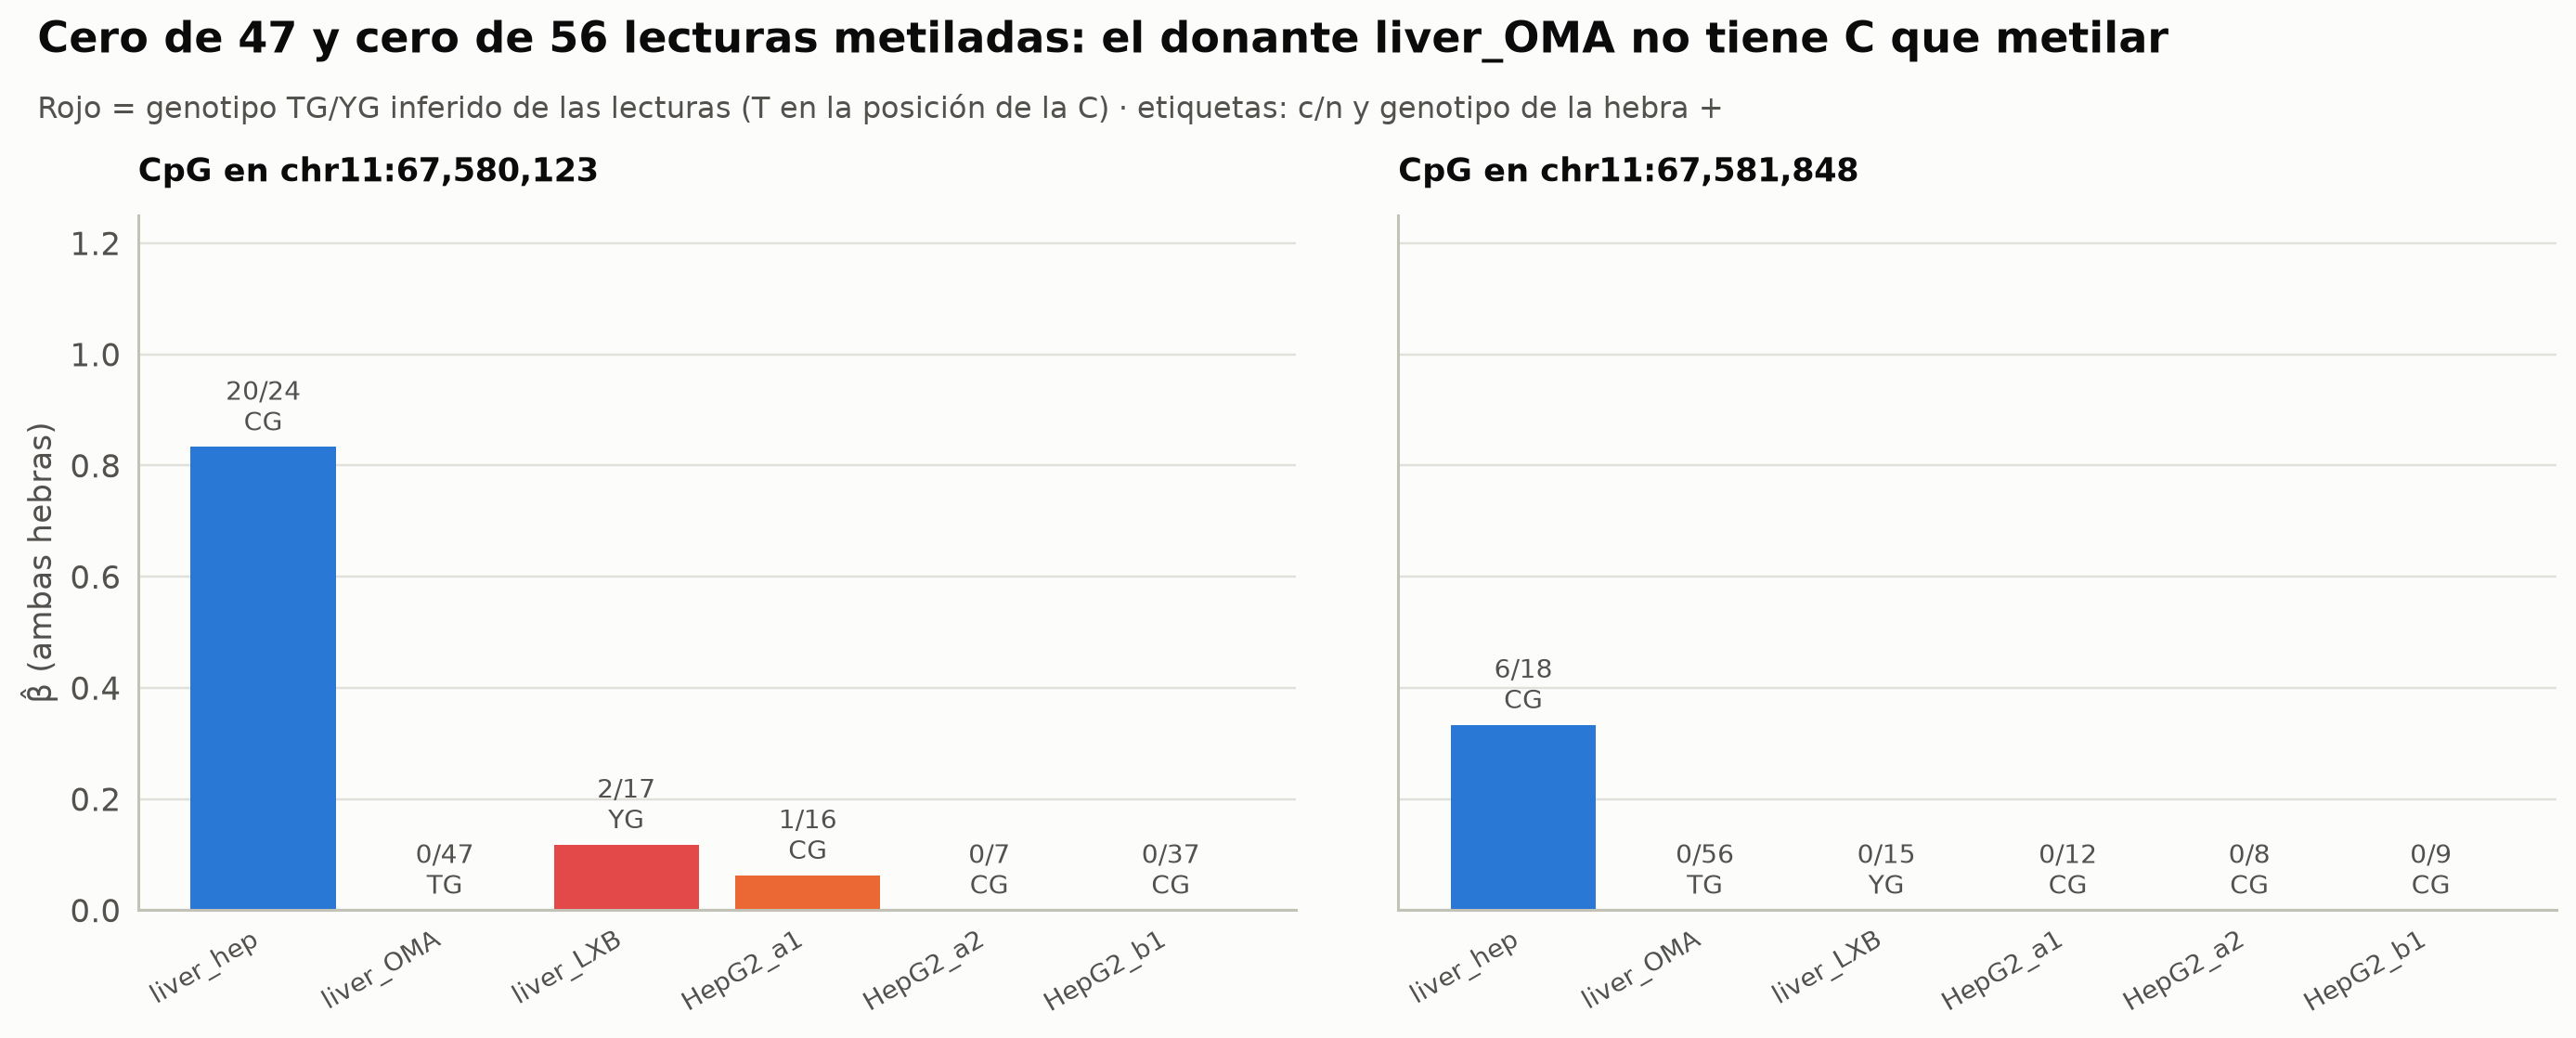

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True, gridspec_kw=dict(wspace=0.08))
for ax, site in zip(axes, snp_sites):
    d = wgbs[(wgbs.cpg == site)].groupby("sample")[["meth", "cov"]].sum().reindex(A_S + B_S).fillna(0)
    geno = wgbs[(wgbs.cpg == site) & (wgbs.strand == "+")].set_index("sample").geno.reindex(A_S + B_S).fillna("—")
    b = d.meth / d["cov"].replace(0, np.nan)
    cols = [ec.RED if g in ("TG", "YG") else (NORMAL if s in A_S else TUMOR) for s, g in zip(A_S + B_S, geno)]
    bars = ax.bar(range(6), b.fillna(0), color=cols)
    for i, (s, g) in enumerate(zip(A_S + B_S, geno)):
        ax.text(i, (0 if np.isnan(b.iloc[i]) else b.iloc[i]) + 0.03, f"{int(d.meth.iloc[i])}/{int(d['cov'].iloc[i])}\n{g}",
                ha="center", fontsize=9, color=ec.INK_2)
    ax.set_xticks(range(6), A_S + B_S, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"CpG en {REG_CHROM}:{site:,}", loc="left", fontsize=11.5); ax.set_ylim(0, 1.25)
axes[0].set_ylabel("β̂ (ambas hebras)")
ec.fig_title(fig, "Cero de 47 y cero de 56 lecturas metiladas: el donante liver_OMA no tiene C que metilar",
             "Rojo = genotipo TG/YG inferido de las lecturas (T en la posición de la C) · etiquetas: c/n y genotipo de la hebra +")
plt.show()

> 🔎 **Qué observamos.** En el CpG de 67 580 123 los hepatocitos están metilados (20/24), pero `liver_OMA` da 0/47 y
> `liver_LXB` 2/17. Sin mirar el genotipo, llamaríamos una "pérdida de metilación" muy significativa en esos dos
> donantes (¡con esa cobertura!). La hebra inferior lo delata: allí el flujo ve **A** frente a la G de la referencia
> (genotipo `CA` en `liver_OMA`, `CR` = A/G en `liver_LXB`), algo que el bisulfito no puede producir, porque nunca actúa
> sobre una G. `liver_OMA` es homocigoto T (**no hay citosina que metilar**) y `liver_LXB` heterocigoto (la mitad de
> sus moléculas no tiene C). En el segundo CpG ocurre lo mismo (0/56 y 0/15). HepG2 no tiene la variante: su 0 sí es
> falta de metilación. Por eso en la sección 6 excluimos esa muestra en esos CpG. En estudios de cohortes se cruzan además las
> posiciones con dbSNP.

### Trampa 2: composición celular

Una diferencia de metilación entre tejidos enfermos y sanos puede reflejar sólo una **proporción distinta de tipos
celulares**. Nuestro propio grupo "normal" lo ilustra: una muestra son **hepatocitos** purificados y las otras dos son
**tejido hepático** completo, que además contiene células endoteliales, de Kupffer, estrelladas, linfocitos…

In [40]:
isl_mask = (pos_real >= ISL_S) & (pos_real < ISL_E)
Ni, Ci = Nc[isl_mask].sum(), Cc[isl_mask].sum()
comp = pd.DataFrame({"tipo de muestra": samples.set_index("sample").loc[A_S + B_S, "description"],
                     "β isla GSTP1": (Ci / Ni).round(3), "lecturas": Ni})
print(comp.to_string())

                          tipo de muestra  β isla GSTP1  lecturas
sample                                                           
liver_hep           hepatocitos primarios         0.012       569
liver_OMA                 hígado (tejido)         0.281      2448
liver_LXB       lóbulo derecho del hígado         0.181       287
HepG2_a1   HepG2, experimento 1 réplica 1         0.866       515
HepG2_a2   HepG2, experimento 1 réplica 2         0.886       299
HepG2_b1   HepG2, experimento 2 réplica 1         0.849       483


> 🔎 **Qué observamos.** En la isla completa, los hepatocitos purificados están casi sin metilar (~1 %), mientras que
> los dos tejidos hepáticos muestran ~18–28 %: la señal viene de **otros tipos celulares** del tejido (o de subpoblaciones
> de hepatocitos) con la isla metilada en su parte 3'. Si comparáramos "hepatocitos sanos" con "tejido tumoral", parte de
> la diferencia sería composición, no cáncer. Deconvolucionar (estimar las proporciones de tipos celulares a partir de
> perfiles de referencia) o ajustar por composición es obligatorio en muestras de sangre y tumores.

## 9. Relojes epigenéticos y metilación sin bisulfito

**Relojes.** La metilación cambia con la edad de manera tan regular que puede usarse como reloj. Horvath (2013) entrenó
un predictor multitejido con unas 8000 muestras de micromatrices de 82 conjuntos de datos y 51 tejidos y tipos
celulares sanos: una regresión penalizada (red elástica) seleccionó **353 CpG** cuya combinación lineal, tras una
transformación de la edad logarítmica en la infancia y lineal en la adultez, estima la "edad epigenética". Esta edad es
cercana a cero en células madre embrionarias e inducidas, aumenta con el número de pases en cultivo y aparece acelerada
en muchos tipos de cáncer. La diferencia entre la edad epigenética y la cronológica, la **aceleración**, se ha convertido
en un biomarcador muy estudiado.

**Nanoporos.** La secuenciación por nanoporos (Lección 6.1) lee la molécula **nativa**, sin amplificar, y la corriente
iónica depende de las bases que ocupan el poro, incluidas las modificadas. Simpson *et al.* (2017) entrenaron un modelo
oculto de Márkov (Lección 4.3) con ADN metilado sintéticamente para distinguir 5mC de citosina en la señal eléctrica y
obtuvieron el metiloma humano sin ningún paso especial de preparación. Sin bisulfito no hay degradación del ADN ni
pérdida de complejidad (adiós al alfabeto de tres letras), las lecturas largas permiten **fasear** la metilación con los
alelos (¡justo lo que haría falta para ver la impronta de *SNRPN* molécula a molécula!), y la misma corrida entrega
secuencia y epigenoma.

> 💡 **Idea clave.** El bisulfito convierte una marca química invisible en una diferencia de secuencia (C frente a T).
> La metilación de un sitio es una proporción de lecturas, y su comparación entre grupos exige un modelo que separe el
> ruido de muestreo (binomial) de la variación biológica (dispersión beta).

## ✍️ Ejercicios

**Ejercicio 1 — Un criterio más estricto.** Aplique a la región de *GSTP1* el criterio de Takai y Jones (2002): ventanas
de **500 pb**, GC ≥ 55 % y obs./esp. ≥ 0,65. ¿Qué tramos sobreviven? ¿Y la isla de UCSC?

**Ejercicio 2 — Intervalos en los extremos.** Calcule los intervalos al 95 % de Wald y de Jeffreys para $c/n = 0/8$ y
$8/8$. ¿Qué le pasa al de Wald? ¿Cuántas lecturas, todas "C", harían falta para que el límite inferior de Jeffreys
supere 0,9?

**Ejercicio 3 — ¿Cuánta dispersión aguanta el ejemplo del libro?** Con los conteos del ejemplo «Un CpG, tres réplicas
por grupo», compruebe que $\phi = 0{,}02$ da $z = 6{,}00$ y encuentre el valor de $\phi$ a partir del cual el CpG deja
de ser significativo con $p < 0{,}01$. ¿Y con $p < 10^{-6}$ (un umbral tipo "genoma completo")?

**Ejercicio 4 — Cobertura mínima.** Repita el análisis de la DMR real exigiendo al menos 5 lecturas por réplica
(ponga $n_r = 0$, es decir, "sin dato", cuando $n_r < 5$). ¿Cuántos CpG quedan? ¿Cambian los límites de la DMR?

**Ejercicio 5 — No conversión.** Simule de nuevo 3000 lecturas con una tasa de no conversión del 3 % (una reacción
de bisulfito defectuosa), alinéelas y estime la metilación CHH y la de los CpG de la DMR. ¿En cuánto se sesga $\hat\beta$
en un CpG verdaderamente no metilado? ¿Cómo corregiría $\hat\beta$ conociendo la tasa?

In [41]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
W2, rows_tj = 500, []
for i in range(0, len(ref) - W2 + 1, 25):
    s = cpg_stats(ref[i:i + W2]); s["start"] = REG_START + i; rows_tj.append(s)
tj = pd.DataFrame(rows_tj)
tj["pasa"] = (tj.GC >= 0.55) & (tj.OE >= 0.65)
runs_tj, cur = [], None
for st_, ok in zip(tj.start, tj.pasa):
    if ok and cur and st_ <= cur[1]:
        cur[1] = st_ + W2
    elif ok:
        cur = [st_, st_ + W2]; runs_tj.append(cur)
print(f"Ventanas de 500 pb que cumplen Takai-Jones: {tj.pasa.sum()} de {len(tj)}")
for a, b in runs_tj:
    print(f"  tramo {a:,}-{b:,} ({b - a} pb) · solapa la isla de UCSC: {a < ISL_E and b > ISL_S}")
print("Sólo sobrevive el tramo del promotor: los tramos cortos que pasaban con 200 pb desaparecen.")

Ventanas de 500 pb que cumplen Takai-Jones: 24 de 309
  tramo 67,583,225-67,584,300 (1075 pb) · solapa la isla de UCSC: True
Sólo sobrevive el tramo del promotor: los tramos cortos que pasaban con 200 pb desaparecen.


In [42]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for c, n in [(0, 8), (8, 8)]:
    b = c / n; half = 1.96 * math.sqrt(b * (1 - b) / n)
    lo = 0 if c == 0 else stats.beta.ppf(0.025, c + .5, n - c + .5)
    hi = 1 if c == n else stats.beta.ppf(0.975, c + .5, n - c + .5)
    print(f"{c}/{n}: Wald ({b - half:.3f}; {b + half:.3f}) · Jeffreys ({lo:.3f}; {hi:.3f})")
print("El intervalo de Wald tiene ancho CERO: afirma certeza absoluta con 8 lecturas.")
n_need = next(n for n in range(1, 500) if stats.beta.ppf(0.025, n + .5, .5) > 0.9)
print(f"Con n lecturas todas 'C', el límite inferior de Jeffreys supera 0,9 a partir de n = {n_need}.")

0/8: Wald (0.000; 0.000) · Jeffreys (0.000; 0.262)
8/8: Wald (1.000; 1.000) · Jeffreys (0.738; 1.000)
El intervalo de Wald tiene ancho CERO: afirma certeza absoluta con 8 lecturas.
Con n lecturas todas 'C', el límite inferior de Jeffreys supera 0,9 a partir de n = 24.


In [43]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
z02, p02 = wald_z(A_ex, B_ex, 0.02)
print(f"φ = 0,02: z = {z02:.2f} · p = {p02:.2e}")
fine = np.linspace(0, 1.0, 20001)
p_f = np.array([wald_z(A_ex, B_ex, f)[1] for f in fine])
for thr in [0.01, 1e-6]:
    idx = np.argmax(p_f > thr)
    print(f"deja de ser significativo con p < {thr:g} a partir de φ ≈ {fine[idx]:.3f}")
print("Con un umbral estricto basta una dispersión modesta para perder el hallazgo.")

φ = 0,02: z = 6.00 · p = 1.94e-09


deja de ser significativo con p < 0.01 a partir de φ ≈ 0.331
deja de ser significativo con p < 1e-06 a partir de φ ≈ 0.056
Con un umbral estricto basta una dispersión modesta para perder el hallazgo.


In [44]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
nA5, nB5 = np.where(nA >= 5, nA, 0), np.where(nB >= 5, nB, 0)
cA5, cB5 = np.where(nA >= 5, cA, 0), np.where(nB >= 5, cB, 0)
ok5 = ((nA5 > 0).sum(1) >= 2) & ((nB5 > 0).sum(1) >= 2)
_, _, z5, p5 = wald_vec(cA5[ok5], nA5[ok5], cB5[ok5], nB5[ok5], phi_post[ok5])
rn5 = longest_signed_run(p5 < 0.01, z5)
pos5 = pos_real[ok5]
print(f"CpG con ≥ 2 réplicas de ≥ 5 lecturas por grupo: {ok5.sum()} de {len(pos_real)}")
print(f"DMR: {pos5[rn5[1]]:,}–{pos5[rn5[2]]:,} ({rn5[0]} CpG)  vs  original {DMR_S:,}–{DMR_E:,} ({rn[0]} CpG)")
print("Con menos CpG desaparecen también los 'huecos' no significativos: el tramo empieza en el mismo sitio pero se")
print("extiende por casi toda la isla. Los límites de una DMR dependen de los filtros; su núcleo, no.")

CpG con ≥ 2 réplicas de ≥ 5 lecturas por grupo: 136 de 220
DMR: 67,583,253–67,584,314 (21 CpG)  vs  original 67,583,253–67,583,906 (58 CpG)
Con menos CpG desaparecen también los 'huecos' no significativos: el tramo empieza en el mismo sitio pero se
extiende por casi toda la isla. Los límites de una DMR dependen de los filtros; su núcleo, no.


In [45]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
reads3 = simulate_reads(3000, nonconv=0.03, rng=np.random.default_rng(5))
calls3 = pd.DataFrame([c for r, _, _ in reads3 for h in [bismark_align(r)] if h for c in call_methylation(r, h)],
                      columns=["pos", "ctx", "meth"])
chh3 = calls3.loc[calls3.ctx == "CHH", "meth"].mean()
cpg3 = calls3[calls3.ctx == "CpG"].groupby("pos").meth.mean()
unm = true_beta[true_beta == 0].index.intersection(cpg3.index)
print(f"Metilación CHH aparente: {chh3:.2%} (≈ no conversión 3 % + errores)")
print(f"CpG con β verdadero = 0: β̂ medio = {cpg3.loc[unm].mean():.3f}")
print("Corrección: si ε es la tasa de no conversión, β̂ ≈ β + ε(1 − β)  ⇒  β ≈ (β̂ − ε) / (1 − ε).")

Metilación CHH aparente: 3.04% (≈ no conversión 3 % + errores)
CpG con β verdadero = 0: β̂ medio = 0.026
Corrección: si ε es la tasa de no conversión, β̂ ≈ β + ε(1 − β)  ⇒  β ≈ (β̂ − ε) / (1 − ε).


## 📌 Resumen

* La **5mC** en contexto **CpG** es simétrica y heredable; su desaminación a T agotó los CpG del genoma (obs./esp. ≈
  0,25), salvo en las **islas CpG** de los promotores: GC > 50 %, $n_{CG}L/(n_Cn_G) > 0{,}6$, $L \ge 200$ pb. En el
  ejemplo del libro, isla = 1,01 y mar = 0,27; en *GSTP1*, la isla de 1025 pb rodea el TSS.
* El **bisulfito** convierte C → U → T y deja intactas las 5mC: la marca se vuelve una diferencia de secuencia. La tasa
  de **no conversión** se estima con las C fuera de CpG (CHH).
* Las lecturas convertidas casi tienen **tres letras**: el genoma se vuelve más repetitivo y un alineador ingenuo
  fracasa. **Bismark** convierte lecturas (C→T) y genoma (C→T y G→A), alinea en el espacio reducido y llama la
  metilación comparando las secuencias **originales**.
* $c \sim \mathrm{Bin}(n,\beta)$, $\hat\beta = c/n$. Con pocas lecturas use intervalos de **Jeffreys**, no de Wald.
  $M = \log_2\frac{\beta}{1-\beta}$ estabiliza la varianza (método delta): $\beta$ para informar, $M$ para contrastar en
  micromatrices.
* La variación entre individuos exige el modelo **beta-binomial**: $\operatorname{Var}(c)=n\mu(1-\mu)[1+(n-1)\phi]$;
  la cobertura no elimina el piso $\mu(1-\mu)\phi$. En el ejemplo del libro, $z = 5{,}02$ con $\phi = 0{,}05$ frente a
  $z = 7{,}10$ si se ignora la dispersión. **Encoger** $\phi$ hacia un valor común (DSS) estabiliza la prueba.
* Las **DMR** se llaman suavizando y agrupando CpG significativos contiguos. En datos reales de ENCODE, el promotor de
  *GSTP1* está hipermetilado en HepG2 (β ≈ 0,96 en la DMR) frente al hígado normal (β ≈ 0,10–0,16), y HepG2 pierde metilación en el
  "mar": las dos caras del metiloma tumoral.
* Cuidado con los **SNP C/T** (miran la hebra opuesta) y con la **composición celular** (hepatocitos frente a tejido).

## 📚 Para profundizar

* Bird, A. P. (1986). CpG-rich islands and the function of DNA methylation. *Nature* 321(6067): 209–213.
  https://doi.org/10.1038/321209a0
* Gardiner-Garden, M. & Frommer, M. (1987). CpG islands in vertebrate genomes. *Journal of Molecular Biology* 196(2):
  261–282. https://doi.org/10.1016/0022-2836(87)90689-9
* Takai, D. & Jones, P. A. (2002). Comprehensive analysis of CpG islands in human chromosomes 21 and 22. *PNAS* 99(6):
  3740–3745. https://doi.org/10.1073/pnas.052410099
* Frommer, M. *et al.* (1992). A genomic sequencing protocol that yields a positive display of 5-methylcytosine residues
  in individual DNA strands. *PNAS* 89(5): 1827–1831. https://doi.org/10.1073/pnas.89.5.1827
* Lister, R. *et al.* (2009). Human DNA methylomes at base resolution show widespread epigenomic differences. *Nature*
  462(7271): 315–322. https://doi.org/10.1038/nature08514
* Krueger, F. & Andrews, S. R. (2011). Bismark: a flexible aligner and methylation caller for Bisulfite-Seq
  applications. *Bioinformatics* 27(11): 1571–1572. https://doi.org/10.1093/bioinformatics/btr167
* Du, P. *et al.* (2010). Comparison of Beta-value and M-value methods for quantifying methylation levels by microarray
  analysis. *BMC Bioinformatics* 11: 587. https://doi.org/10.1186/1471-2105-11-587
* Brown, L. D., Cai, T. T. & DasGupta, A. (2001). Interval estimation for a binomial proportion. *Statistical Science*
  16(2): 101–133. https://doi.org/10.1214/ss/1009213286
* Feng, H., Conneely, K. N. & Wu, H. (2014). A Bayesian hierarchical model to detect differentially methylated loci
  from single nucleotide resolution sequencing data. *Nucleic Acids Research* 42(8): e69. https://doi.org/10.1093/nar/gku154
* Hansen, K. D., Langmead, B. & Irizarry, R. A. (2012). BSmooth: from whole genome bisulfite sequencing reads to
  differentially methylated regions. *Genome Biology* 13: R83. https://doi.org/10.1186/gb-2012-13-10-r83
* Lee, W.-H. *et al.* (1994). Cytidine methylation of regulatory sequences near the π-class glutathione S-transferase
  gene accompanies human prostatic carcinogenesis. *PNAS* 91(24): 11733–11737. https://doi.org/10.1073/pnas.91.24.11733
* López-Terrada, D., Cheung, S. W., Finegold, M. J. & Knowles, B. B. (2009). Hep G2 is a hepatoblastoma-derived cell
  line. *Human Pathology* 40(10): 1512–1515. https://doi.org/10.1016/j.humpath.2009.07.003
* Hegi, M. E. *et al.* (2005). *MGMT* gene silencing and benefit from temozolomide in glioblastoma. *New England
  Journal of Medicine* 352(10): 997–1003. https://doi.org/10.1056/NEJMoa043331
* Horvath, S. (2013). DNA methylation age of human tissues and cell types. *Genome Biology* 14(10): R115.
  https://doi.org/10.1186/gb-2013-14-10-r115
* Simpson, J. T. *et al.* (2017). Detecting DNA cytosine methylation using nanopore sequencing. *Nature Methods* 14(4):
  407–410. https://doi.org/10.1038/nmeth.4184
* The ENCODE Project Consortium *et al.* (2020). Expanded encyclopaedias of DNA elements in the human and mouse genomes.
  *Nature* 583: 699–710. https://doi.org/10.1038/s41586-020-2493-4 (datos WGBS: experimentos ENCSR351IPU, ENCSR713WYJ,
  ENCSR108ESU, ENCSR881XOU y ENCSR786DCL en https://www.encodeproject.org)

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)